<a id="top"></a>

# CO₂–H₂ short-range angular fitting

## From the July 9 assignment to an independent-validation request

**Technical group presentation — 20–30 minutes**  
**Research/audit source:** `co2_h2_short_range_methodology_v2_meeting.ipynb`

This notebook is the presentation companion to the complete v2 research
artifact. It preserves chronological execution and the same scientific
conventions, while exposing only the quantities needed to support the meeting
decisions.

Four evidence labels are used throughout:

- **Reconstruction:** fit and evaluation on the completed 500-angle grid.
- **Held-out known-grid testing:** test labels are excluded from a fit, but the
  geometries still belong to the existing candidate grid.
- **Off-grid model diagnostic:** comparison of two fitted models where no new
  ab initio truth exists.
- **Independent validation:** new electronic-structure energies frozen before
  their values are inspected.


<a id="contents"></a>

## Linked contents

1. [July 9 assignment and current answers](#assignment)
2. [Dataset structure](#dataset)
3. [Locked safety criterion](#criterion)
4. [Switching question: resolved](#switch)
5. [All-500 raw-potential baseline](#baseline)
6. [Why sparse random sampling fails](#random)
7. [Geometry-only D-optimal selection](#doptimal)
8. [How to interpret 175–182 points](#interpretation)
9. [Off-grid and radial diagnostics](#diagnostics)
10. [Independent-ab-initio request](#request)
11. [Meeting summary](#summary)
12. [Technical appendices](#appendices)

### 20-minute presentation route

Follow the headings above through the meeting summary. Expand the implementation
cells only if a question concerns code or experimental design. The appendices
are not part of the default route.


### Reproducibility block — run once, normally keep collapsed

This cell loads the fixed dataset, reconstructs the published 158-term basis,
and defines the scoring and fitting helpers. It also resolves the output
directory from the located data file, rather than from the kernel's incidental
working directory.


In [1]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — setup, data, basis, and scoring
import math
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from IPython.display import display
from scipy.special import lpmv
from sympy.physics.wigner import wigner_3j

# Reproducible defaults shared by later experiments.
RANDOM_SEED = 42
SHORT_RANGE_MIN_R = 4.4
SHORT_RANGE_MAX_R = 6.6
EXPECTED_POINTS_PER_R = 500
EXPECTED_BASIS_TERMS = 158

ANGLE_COLUMNS = ["Theta_1", "Theta_2", "Phi"]
DATA_COLUMNS = ["R", *ANGLE_COLUMNS, "V"]

# Resolve the project from the data file rather than the kernel's
# ambient working directory. This keeps exports deterministic in VS Code.
SEARCH_ROOTS = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
DATA_CANDIDATES = []
for root in SEARCH_ROOTS:
    DATA_CANDIDATES.extend([
        root / "project_sources/02-all_avcbs_uniform.dat",
        root / "all_avcbs_uniform.dat",
        root / "02-all_avcbs_uniform.dat",
    ])
DATA_FILE = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_FILE is None:
    searched = "\n".join(f"  - {path}" for path in DATA_CANDIDATES)
    raise FileNotFoundError(
        "Could not locate all_avcbs_uniform.dat. Searched:\n" + searched
    )

PROJECT_ROOT = (
    DATA_FILE.parent.parent
    if DATA_FILE.parent.name == "project_sources"
    else DATA_FILE.parent
).resolve()
MEETING_OUTPUT_DIR = PROJECT_ROOT / "meeting_outputs_v3"

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

print(f"Using data file: {DATA_FILE.resolve()}")

# --- v2 source cell 7 ---
df_all = pd.read_csv(
    DATA_FILE,
    sep=r"\s+",
    names=DATA_COLUMNS,
)

# Assign the same identifier to an angular geometry wherever it appears in R.
# Rounding protects the identifier from inconsequential text-to-float differences.
angle_index = pd.MultiIndex.from_frame(df_all[ANGLE_COLUMNS].round(8))
df_all["orientation_id"] = pd.factorize(angle_index, sort=True)[0]

points_per_R = df_all.groupby("R").size().sort_index()
orientation_counts = df_all.groupby("orientation_id").size()
short_range_R = points_per_R.loc[
    (points_per_R.index >= SHORT_RANGE_MIN_R)
    & (points_per_R.index <= SHORT_RANGE_MAX_R)
].index.to_numpy()

duplicate_count = int(df_all.duplicated(subset=["R", *ANGLE_COLUMNS]).sum())
missing_count = int(df_all[DATA_COLUMNS].isna().sum().sum())
same_grid_at_every_R = (
    df_all.groupby("R")["orientation_id"].nunique()
    .eq(df_all["orientation_id"].nunique())
    .all()
)

print("=== Dataset integrity audit ===")
print(f"Rows: {len(df_all):,}")
print(f"Radial slices: {df_all['R'].nunique()}")
print(f"R range: {df_all['R'].min():g} to {df_all['R'].max():g} Bohr")
print(f"Points per R: {points_per_R.min()} to {points_per_R.max()}")
print(f"Unique angular orientations: {df_all['orientation_id'].nunique()}")
print(f"Same angular grid at every R: {same_grid_at_every_R}")
print(f"Duplicate (R, angle) rows: {duplicate_count}")
print(f"Missing values: {missing_count}")
print(f"Short-range R values: {short_range_R}")

print("\n=== Coordinate ranges ===")
print(df_all[DATA_COLUMNS].agg(["min", "max"]).T.to_string())

# These assertions fail early if a different or malformed dataset is loaded.
assert missing_count == 0, "The source data contain missing values."
assert duplicate_count == 0, "Duplicate radial/angular geometries were found."
assert points_per_R.eq(EXPECTED_POINTS_PER_R).all(), (
    f"Expected {EXPECTED_POINTS_PER_R} points at every R."
)
assert same_grid_at_every_R, "The angular orientations are not shared across all R values."

# --- v2 source cell 9 ---
@lru_cache(maxsize=None)
def cached_wigner_3j(l1, l2, l, m1, m2, m3):
    """Return a cached floating-point Wigner 3-j value."""
    return float(wigner_3j(l1, l2, l, m1, m2, m3))


def normalized_associated_legendre(l, m, x):
    """Associated Legendre function with the Appendix C7 normalization."""
    normalization = np.sqrt(
        ((2 * l + 1) / 2.0)
        * math.factorial(l - m)
        / math.factorial(l + m)
    )
    return normalization * lpmv(m, l, x)


def generate_basis_indices():
    """Generate the 158 allowed (l1, l2, l) angular basis triplets."""
    basis = []
    for l1 in range(0, 25, 2):
        for l2 in range(0, 7, 2):
            if l1 >= 22 and l2 > 0:
                continue
            for l in range(abs(l1 - l2), l1 + l2 + 1):
                if (l1 + l2 + l) % 2 == 0:
                    basis.append((l1, l2, l))
    return basis


def evaluate_A_basis(l1, l2, l, theta1_rad, theta2_rad, phi_rad):
    """Evaluate one normalized angular basis function on vectorized angles."""
    cos_t1 = np.cos(theta1_rad)
    cos_t2 = np.cos(theta2_rad)

    wj_zero = cached_wigner_3j(l1, l2, l, 0, 0, 0)
    p_l1_0 = normalized_associated_legendre(l1, 0, cos_t1)
    p_l2_0 = normalized_associated_legendre(l2, 0, cos_t2)
    total = ((-1) ** (l1 - l2)) * wj_zero * p_l1_0 * p_l2_0

    for m in range(1, min(l1, l2) + 1):
        wj_m = cached_wigner_3j(l1, l2, l, m, -m, 0)
        p_l1 = normalized_associated_legendre(l1, m, cos_t1)
        p_l2 = normalized_associated_legendre(l2, m, cos_t2)
        total += (
            2.0
            * ((-1) ** (m + l1 - l2))
            * wj_m
            * p_l1
            * p_l2
            * np.cos(m * phi_rad)
        )

    return np.sqrt((2 * l + 1) / (4.0 * np.pi)) * total


basis_indices = generate_basis_indices()

normal_integral, _ = quad(
    lambda x: normalized_associated_legendre(4, 2, x) ** 2,
    -1.0,
    1.0,
)
orthogonal_integral, _ = quad(
    lambda x: (
        normalized_associated_legendre(2, 2, x)
        * normalized_associated_legendre(4, 2, x)
    ),
    -1.0,
    1.0,
)

test_values = evaluate_A_basis(4, 2, 4, *[
    np.radians(np.array(values, dtype=float))
    for values in ([15, 60, 120], [30, 90, 150], [0, 45, 90])
])

print("=== Angular basis checks ===")
print(f"Basis terms: {len(basis_indices)} (expected {EXPECTED_BASIS_TERMS})")
print(f"Normalization integral (l=4, m=2): {normal_integral:.10f}")
print(f"Orthogonality integral (l=2 vs. 4, m=2): {orthogonal_integral:.3e}")
print(f"Finite representative basis values: {np.isfinite(test_values).all()}")

assert len(basis_indices) == EXPECTED_BASIS_TERMS
assert np.isclose(normal_integral, 1.0, atol=1e-10)
assert np.isclose(orthogonal_integral, 0.0, atol=1e-10)
assert np.isfinite(test_values).all()

# --- v2 source cell 12 ---
# Energy regions are defined using the raw ab initio potential.
ENERGY_BINS = [-np.inf, 0.0, 1000.0, 3000.0, 5000.0, np.inf]

ENERGY_LABELS = [
    "Attractive (V < 0)",
    "Low repulsive (0 to 1000)",
    "Lower wall (1000 to 3000)",
    "Upper wall (3000 to 5000)",
    "Guardrail (V >= 5000)",
]

df_short = df_all[
    df_all["R"].between(SHORT_RANGE_MIN_R, SHORT_RANGE_MAX_R)
].copy()

df_short["energy_band"] = pd.cut(
    df_short["V"],
    bins=ENERGY_BINS,
    labels=ENERGY_LABELS,
    right=False,
    include_lowest=True,
)

band_counts = (
    pd.crosstab(df_short["R"], df_short["energy_band"])
    .reindex(columns=ENERGY_LABELS, fill_value=0)
    .sort_index()
)

band_percentages = band_counts.div(
    band_counts.sum(axis=1),
    axis=0,
) * 100.0

# A compact summary of how many points lie in the region we ultimately
# want to reproduce accurately.
audit_summary = pd.DataFrame(index=band_counts.index)
audit_summary["Points below 5000"] = band_counts[ENERGY_LABELS[:-1]].sum(axis=1)
audit_summary["Percent below 5000"] = (
    audit_summary["Points below 5000"] / EXPECTED_POINTS_PER_R * 100.0
)
audit_summary["Points at or above 5000"] = band_counts[ENERGY_LABELS[-1]]
audit_summary["Percent at or above 5000"] = (
    audit_summary["Points at or above 5000"] / EXPECTED_POINTS_PER_R * 100.0
)

print("=== Number of points in each energy region ===")
print(band_counts.to_string())

print("\n=== Physically relevant region vs. guardrail region ===")
print(audit_summary.round(1).to_string())

print("\n=== Percentage of each radial slice in each energy region ===")
print(band_percentages.round(1).to_string())

# --- v2 source cell 16 ---
ABSOLUTE_TOLERANCE_FLOOR = 1.0
RELATIVE_TOLERANCE = 0.01
PHYSICAL_ENERGY_CEILING = 5000.0
GUARDRAIL_WARNING_THRESHOLD = 3000.0
GUARDRAIL_DANGEROUS_THRESHOLD = 1000.0

RELEVANT_ENERGY_LABELS = ENERGY_LABELS[:-1]
GUARDRAIL_LABEL = ENERGY_LABELS[-1]


def hybrid_tolerance(
    V_true,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
):
    """Return the working pointwise physical tolerance."""
    V_true = np.asarray(V_true, dtype=float)
    return np.maximum(
        absolute_floor,
        relative_fraction * np.abs(V_true),
    )


def hybrid_normalized_error(
    V_true,
    V_pred,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
):
    """Return absolute error divided by the selected hybrid tolerance."""
    V_true = np.asarray(V_true, dtype=float)
    V_pred = np.asarray(V_pred, dtype=float)
    return np.abs(V_pred - V_true) / hybrid_tolerance(
        V_true,
        absolute_floor=absolute_floor,
        relative_fraction=relative_fraction,
    )


def score_relevant_predictions(
    V_true,
    V_pred,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
):
    """Summarize prediction error in each populated band below 5000."""
    V_true = np.asarray(V_true, dtype=float)
    V_pred = np.asarray(V_pred, dtype=float)

    assigned_bands = pd.cut(
        V_true,
        bins=ENERGY_BINS,
        labels=ENERGY_LABELS,
        right=False,
        include_lowest=True,
    )

    rows = []
    for label in RELEVANT_ENERGY_LABELS:
        mask = np.asarray(assigned_bands == label)
        if not np.any(mask):
            continue

        truth = V_true[mask]
        prediction = V_pred[mask]
        absolute_error = np.abs(prediction - truth)
        normalized_error = hybrid_normalized_error(
            truth,
            prediction,
            absolute_floor=absolute_floor,
            relative_fraction=relative_fraction,
        )

        rows.append({
            "Energy band": label,
            "N": int(mask.sum()),
            "MAE (cm^-1)": np.mean(absolute_error),
            "RMSE (cm^-1)": np.sqrt(np.mean(absolute_error**2)),
            "P95 normalized error": np.percentile(normalized_error, 95),
            "Max normalized error": np.max(normalized_error),
            "Within tolerance (%)": 100.0 * np.mean(normalized_error <= 1.0),
        })

    return pd.DataFrame(rows)

# --- v2 source cell 18 ---
def repeated_fivefold_splits(
    df_r,
    n_repeats=3,
    n_folds=5,
    random_seed=RANDOM_SEED,
):
    """
    Generate paired repeated five-fold splits.

    With 500 points and five folds, every split contains
    400 training points and 100 test points.
    """
    all_indices = df_r.index.to_numpy()
    rng = np.random.default_rng(random_seed)

    for repeat in range(n_repeats):
        shuffled_indices = rng.permutation(all_indices)
        folds = np.array_split(shuffled_indices, n_folds)

        for fold_number in range(n_folds):
            test_indices = folds[fold_number]
            train_indices = np.concatenate([
                fold
                for i, fold in enumerate(folds)
                if i != fold_number
            ])

            yield {
                "repeat": repeat,
                "fold": fold_number,
                "train_indices": train_indices,
                "test_indices": test_indices,
            }

# --- v2 source cell 21 ---
LSTSQ_RCOND = 1e-4

CURRENT_SWITCH_T1 = 1000.0
CURRENT_SWITCH_T2 = 5000.0


def raw_target(V):
    """Return the unmodified ab initio potential."""
    return np.asarray(V, dtype=float)


def apply_current_switch(
    V,
    V_T1=CURRENT_SWITCH_T1,
    V_T2=CURRENT_SWITCH_T2,
):
    """Apply the switching function used in the existing fitting workflow."""
    V = np.asarray(V, dtype=float)
    V_switched = np.empty_like(V)

    below = V <= V_T1
    above = V > V_T2
    middle = ~(below | above)

    V_switched[below] = V[below]

    cap = V_T1 + (2.0 / np.pi) * (V_T2 - V_T1)
    V_switched[above] = cap

    u = (V[middle] - V_T1) / (V_T2 - V_T1)

    S_u = (
        (2.0 / np.pi)
        * np.sin(
            (np.pi / 2.0)
            * np.sin((np.pi / 2.0) * u)
        )
    )

    V_switched[middle] = (
        V_T1
        + (V_T2 - V_T1) * S_u
    )

    return V_switched


CURRENT_SWITCH_CAP = (
    CURRENT_SWITCH_T1
    + (2.0 / np.pi)
    * (CURRENT_SWITCH_T2 - CURRENT_SWITCH_T1)
)

print(f"Current high-energy cap: {CURRENT_SWITCH_CAP:.3f} cm^-1")

# --- v2 source cell 24 ---
def angles_from_df(df):
    """Return the three angular coordinates in radians."""
    return (
        np.radians(df["Theta_1"].to_numpy()),
        np.radians(df["Theta_2"].to_numpy()),
        np.radians(df["Phi"].to_numpy()),
    )


def build_design_matrix(df_angles, basis):
    """Construct the angular design matrix for a set of orientations."""
    theta1, theta2, phi = angles_from_df(df_angles)

    M = np.empty((len(df_angles), len(basis)))

    for column, (l1, l2, l) in enumerate(basis):
        M[:, column] = evaluate_A_basis(
            l1,
            l2,
            l,
            theta1,
            theta2,
            phi,
        )

    return M


# Keep exactly one copy of each shared angular orientation.
reference_angles = (
    df_all
    .drop_duplicates(subset="orientation_id")
    .sort_values("orientation_id")
)

assert np.array_equal(
    reference_angles["orientation_id"].to_numpy(),
    np.arange(EXPECTED_POINTS_PER_R),
)

M_orientation = build_design_matrix(
    reference_angles,
    basis_indices,
)

singular_values = np.linalg.svd(
    M_orientation,
    compute_uv=False,
)

matrix_rank = np.linalg.matrix_rank(M_orientation)
matrix_condition = singular_values[0] / singular_values[-1]

print("=== Shared design-matrix audit ===")
print(f"Shape: {M_orientation.shape}")
print(f"Numerical rank: {matrix_rank}")
print(f"Condition number: {matrix_condition:.3e}")
print(f"All entries finite: {np.isfinite(M_orientation).all()}")

assert M_orientation.shape == (
    EXPECTED_POINTS_PER_R,
    EXPECTED_BASIS_TERMS,
)
assert matrix_rank == EXPECTED_BASIS_TERMS
assert np.isfinite(M_orientation).all()

# --- v2 source cell 26 ---
def score_guardrail_predictions(
    V_true,
    V_pred,
    true_guardrail_threshold=PHYSICAL_ENERGY_CEILING,
    warning_prediction_threshold=GUARDRAIL_WARNING_THRESHOLD,
    dangerous_prediction_threshold=GUARDRAIL_DANGEROUS_THRESHOLD,
):
    """Describe predictions where the raw truth lies in the high wall."""
    V_true = np.asarray(V_true, dtype=float)
    V_pred = np.asarray(V_pred, dtype=float)

    mask = V_true >= true_guardrail_threshold
    guardrail_predictions = V_pred[mask]

    if len(guardrail_predictions) == 0:
        return pd.DataFrame([{
            "N": 0,
            "Minimum predicted V": np.nan,
            "5th percentile predicted V": np.nan,
            "Predicted below 3000 (%)": np.nan,
            "Predicted below 1000 (%)": np.nan,
        }])

    return pd.DataFrame([{
        "N": len(guardrail_predictions),
        "Minimum predicted V": np.min(guardrail_predictions),
        "5th percentile predicted V": np.percentile(
            guardrail_predictions, 5
        ),
        "Predicted below 3000 (%)": 100.0 * np.mean(
            guardrail_predictions < warning_prediction_threshold
        ),
        "Predicted below 1000 (%)": 100.0 * np.mean(
            guardrail_predictions < dangerous_prediction_threshold
        ),
    }])

# --- v2 source cell 27 ---
TARGET_METHODS = {
    "Raw potential": raw_target,
    "Current switch": apply_current_switch,
}


def cross_validate_target_methods_at_R(
    df,
    target_R,
    design_matrix,
    target_methods=TARGET_METHODS,
    n_repeats=3,
    n_folds=5,
    rcond=LSTSQ_RCOND,
):
    """
    Compare target treatments using paired repeated five-fold fits.

    Each repetition returns one out-of-sample prediction for every
    angular orientation.
    """
    df_r = df[np.isclose(df["R"], target_R)].copy()

    if len(df_r) != EXPECTED_POINTS_PER_R:
        raise ValueError(
            f"Expected {EXPECTED_POINTS_PER_R} points at R={target_R}, "
            f"but found {len(df_r)}."
        )

    truth_by_orientation = (
        df_r
        .set_index("orientation_id")["V"]
        .reindex(range(EXPECTED_POINTS_PER_R))
        .to_numpy()
    )

    splits = list(
        repeated_fivefold_splits(
            df_r,
            n_repeats=n_repeats,
            n_folds=n_folds,
        )
    )

    predictions = {
        (method_name, repeat): np.full(
            EXPECTED_POINTS_PER_R,
            np.nan,
        )
        for method_name in target_methods
        for repeat in range(n_repeats)
    }

    for split in splits:
        repeat = split["repeat"]

        train_df = df_r.loc[split["train_indices"]]
        test_df = df_r.loc[split["test_indices"]]

        train_ids = train_df["orientation_id"].to_numpy()
        test_ids = test_df["orientation_id"].to_numpy()

        M_train = design_matrix[train_ids]
        M_test = design_matrix[test_ids]

        raw_training_values = train_df["V"].to_numpy()

        for method_name, target_function in target_methods.items():
            y_train = target_function(raw_training_values)

            coefficients, *_ = np.linalg.lstsq(
                M_train,
                y_train,
                rcond=rcond,
            )

            predictions[(method_name, repeat)][test_ids] = (
                M_test @ coefficients
            )

    relevant_results = []
    guardrail_results = []

    for method_name in target_methods:
        for repeat in range(n_repeats):
            prediction = predictions[(method_name, repeat)]

            if not np.isfinite(prediction).all():
                raise RuntimeError(
                    f"Incomplete predictions for "
                    f"{method_name}, repeat {repeat}."
                )

            relevant = score_relevant_predictions(
                truth_by_orientation,
                prediction,
            )
            relevant.insert(0, "Repeat", repeat)
            relevant.insert(0, "Method", method_name)
            relevant.insert(0, "R", target_R)
            relevant_results.append(relevant)

            guardrail = score_guardrail_predictions(
                truth_by_orientation,
                prediction,
            )
            guardrail.insert(0, "Repeat", repeat)
            guardrail.insert(0, "Method", method_name)
            guardrail.insert(0, "R", target_R)
            guardrail_results.append(guardrail)

    return (
        pd.concat(relevant_results, ignore_index=True),
        pd.concat(guardrail_results, ignore_index=True),
        predictions,
        truth_by_orientation,
    )

# --- v2 source cell 30 ---
PHYSICAL_ENERGY_BANDS = [
    ("Attractive (V < 0)", lambda V: V < 0.0),
    ("Low repulsive (0 to 1000)", lambda V: (V >= 0.0) & (V < 1000.0)),
    ("Lower wall (1000 to 3000)", lambda V: (V >= 1000.0) & (V < 3000.0)),
    ("Upper wall (3000 to 5000)", lambda V: (V >= 3000.0) & (V < 5000.0)),
]


def summarize_error_decomposition(raw_truth, predictions, target_methods):
    """
    Decompose cross-validated physical error into:

        target distortion = transformed target - raw target
        regression error  = prediction - transformed target
        physical error    = prediction - raw target

    Parameters
    ----------
    raw_truth : array-like, shape (n_points,)
        Original ab initio energies, ordered consistently with predictions.

    predictions : dict
        predictions[method] must have shape (n_repeats, n_points), or
        shape (n_points,) for a single repeat.

    target_methods : dict
        Mapping from method name to its target-transformation function.
    """
    raw_truth = np.asarray(raw_truth, dtype=float)
    rows = []

    for method_name, target_function in target_methods.items():
        target_truth = np.asarray(
            target_function(raw_truth),
            dtype=float
        )

        matching_keys = sorted(
            [
                key
                for key in predictions
                if key[0] == method_name
            ],
            key=lambda key: key[1],
        )

        if not matching_keys:
            raise KeyError(
                f"No predictions found for method {method_name!r}. "
                f"Available keys are: {list(predictions.keys())}"
            )

        method_predictions = np.stack(
            [
                np.asarray(predictions[key], dtype=float)
                for key in matching_keys
            ],
            axis=0,
        )

        if method_predictions.shape[1] != raw_truth.size:
            raise ValueError(
                f"{method_name}: predictions contain "
                f"{method_predictions.shape[1]} points, but raw_truth "
                f"contains {raw_truth.size}."
            )

        target_shift = target_truth - raw_truth

        for band_name, mask_function in PHYSICAL_ENERGY_BANDS:
            mask = mask_function(raw_truth)
            n_points = int(mask.sum())

            if n_points == 0:
                continue

            regression_error = (
                method_predictions[:, mask]
                - target_truth[None, mask]
            )

            physical_error = (
                method_predictions[:, mask]
                - raw_truth[None, mask]
            )

            regression_mae_by_repeat = np.mean(
                np.abs(regression_error),
                axis=1
            )

            physical_mae_by_repeat = np.mean(
                np.abs(physical_error),
                axis=1
            )

            physical_bias_by_repeat = np.mean(
                physical_error,
                axis=1
            )

            rows.append({
                "Method": method_name,
                "Energy band": band_name,
                "N": n_points,

                # Transformation alone; identical across CV repeats.
                "Mean target shift": np.mean(target_shift[mask]),
                "Target-distortion MAE": np.mean(
                    np.abs(target_shift[mask])
                ),

                # Mean performance across repeated five-fold CV runs.
                "CV MAE to own target": np.mean(
                    regression_mae_by_repeat
                ),
                "CV MAE to raw potential": np.mean(
                    physical_mae_by_repeat
                ),
                "Mean signed physical error": np.mean(
                    physical_bias_by_repeat
                ),
            })

    result = pd.DataFrame(rows)

    band_order = {
        name: index
        for index, (name, _) in enumerate(PHYSICAL_ENERGY_BANDS)
    }
    method_order = {
        name: index
        for index, name in enumerate(target_methods)
    }

    result["_method_order"] = result["Method"].map(method_order)
    result["_band_order"] = result["Energy band"].map(band_order)

    result = (
        result
        .sort_values(["_method_order", "_band_order"])
        .drop(columns=["_method_order", "_band_order"])
        .reset_index(drop=True)
    )

    return result


<a id="assignment"></a>

## 1. July 9 assignment and current answers

The meeting asked us to understand the short-range wall, compare raw and
switched fitting, determine whether the angular sample was unnecessarily large,
and return with a concrete request for any calculations that remained necessary.

The answers developed below are:

| Question | Current answer |
|---|---|
| What fit should be used for the completed dataset? | All 500 **raw** energies at each radius. |
| Does the current switch help this objective? | No. It introduces target distortion below the 5000 cm⁻¹ ceiling. |
| Can fewer geometries reconstruct the known grid? | Yes, when selected geometrically; random sparse subsets are unstable. |
| Is 180 a validated total ab initio budget? | No. It is a prospective geometry-only pilot derived retrospectively. |
| What is still missing? | Independent off-grid truth and a focused radial challenge. |

The rest of the notebook binds each answer to a nearby experiment.


<a id="dataset"></a>

## 2. Physical structure of the short-range dataset

### Scientific question

Why is the short-range fit difficult even though 500 angular energies are
available at each radius?

The same 500 angular orientations occur at every one of the 30 radii. This is
valuable because it permits paired angular and radial diagnostics. At the
shortest radii, however, most orientations lie deep in the repulsive wall, while
only a small subset occupies the lower-energy region important to scattering.
The following is an exact census, not a model result.


,Quantity,Value
0,Total energies,"15,000"
1,Radial slices,30
2,R range (Bohr),4.4–40.0
3,Shared orientations per R,500
4,Angular basis terms,158
5,R=4.4 points below 5000,179
6,R=4.4 guardrail points,321


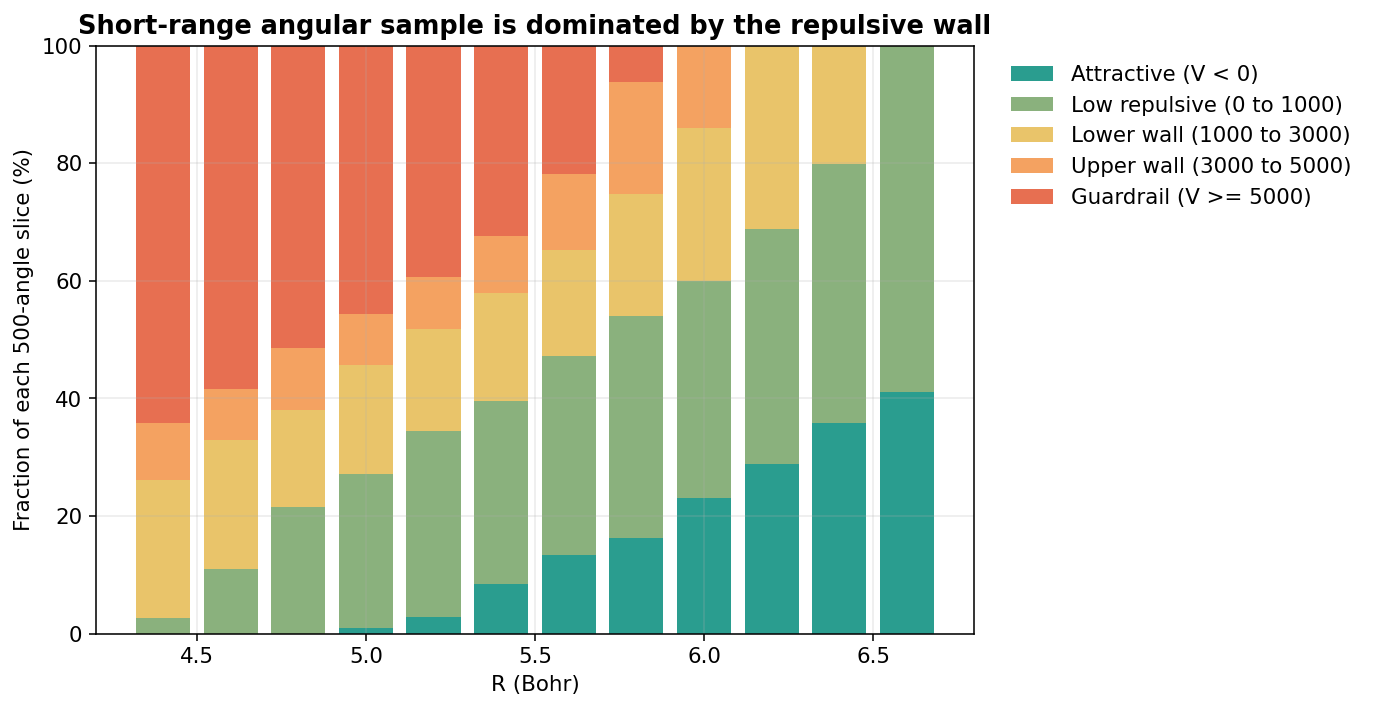

In [ ]:
dataset_summary = pd.DataFrame({
    "Quantity": [
        "Total energies", "Radial slices", "R range (Bohr)",
        "Shared orientations per R", "Angular basis terms",
        "R=4.4 points below 5000", "R=4.4 guardrail points",
    ],
    "Value": [
        f"{len(df_all):,}", df_all["R"].nunique(),
        f"{df_all['R'].min():.1f}–{df_all['R'].max():.1f}",
        EXPECTED_POINTS_PER_R, len(basis_indices),
        int(audit_summary.loc[4.4, "Points below 5000"]),
        int(audit_summary.loc[4.4, "Points at or above 5000"]),
    ],
})
display(dataset_summary)

fig, ax = plt.subplots(figsize=(10, 5.2))
colors = ["#2a9d8f", "#8ab17d", "#e9c46a", "#f4a261", "#e76f51"]
bottom = np.zeros(len(band_percentages))
for label, color in zip(ENERGY_LABELS, colors):
    values = band_percentages[label].to_numpy()
    ax.bar(band_percentages.index, values, bottom=bottom,
           width=0.16, label=label, color=color)
    bottom += values
ax.set(xlabel="R (Bohr)", ylabel="Fraction of each 500-angle slice (%)",
       title="Short-range angular sample is dominated by the repulsive wall")
ax.set_ylim(0, 100)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


**What this shows.** At (R=4.4), only 179 of 500 orientations lie below
(5000\ \mathrm{cm}^{-1}); 321 are in the guardrail region. The proportion of
physically relevant configurations grows rapidly with radius.

**What it does not show.** Energy composition alone says nothing about fitting
accuracy or about which geometries are most informative.

**Supported conclusion.** Sampling strategy must be evaluated explicitly, and
the shortest radii should control the safety audit.


<a id="criterion"></a>

## 3. Locked safety criterion

Before comparing methods, we fix the score. For raw energy below
$5000\ \mathrm{cm}^{-1}$, the pointwise tolerance is

$$
\tau(V)=\max(1\ \mathrm{cm}^{-1},\,0.01|V|), \qquad
z=\frac{|\widehat V-V|}{\tau(V)}.
$$

The default strict screen requires the worst sampled-grid normalized error to
be at most one and no true guardrail point to be predicted below
$3000\ \mathrm{cm}^{-1}$. These are working physical requirements, not laws;
their sensitivity is audited later.


In [3]:
safety_specification = pd.DataFrame({
    "Component": ["Physical ceiling", "Absolute floor", "Relative tolerance",
                  "Guardrail warning", "Dangerous opening"],
    "Value (cm^-1 or fraction)": [PHYSICAL_ENERGY_CEILING,
        ABSOLUTE_TOLERANCE_FLOOR, RELATIVE_TOLERANCE,
        GUARDRAIL_WARNING_THRESHOLD, GUARDRAIL_DANGEROUS_THRESHOLD],
})
display(safety_specification)


,Component,Value (cm^-1 or fraction)
0,Physical ceiling,5000.00
1,Absolute floor,1.00
2,Relative tolerance,0.01
3,Guardrail warning,3000.00
4,Dangerous opening,1000.00


**Evidence boundary.** A pass establishes consistency with this working
specification on the tested points. It does not establish independent physical
accuracy. That distinction is why the final request contains new ab initio
labels.


<a id="switch"></a>

## 4. Switching question: resolved

### Scientific question

Does compressing the high wall make the fixed 158-term regression more useful
below (5000\ \mathrm{cm}^{-1})?

The published/current switch is used exactly as implemented in v2, with **no
square on the inner sine**. Raw and switched targets are fit on identical
repeated five-fold splits at (R=4.4). The error is decomposed into deliberate
target distortion and regression error relative to the fitted target.


In [4]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — paired raw/switch comparison

# --- v2 source cell 28 ---
relevant_r44, guardrail_r44, predictions_r44, truth_r44 = (
    cross_validate_target_methods_at_R(
        df_all,
        target_R=4.4,
        design_matrix=M_orientation,
    )
)

relevant_r44_summary = (
    relevant_r44
    .groupby(["Method", "Energy band"], sort=False)
    .agg(
        N=("N", "first"),
        mean_MAE=("MAE (cm^-1)", "mean"),
        mean_RMSE=("RMSE (cm^-1)", "mean"),
        mean_P95_normalized_error=(
            "P95 normalized error",
            "mean",
        ),
        worst_max_normalized_error=(
            "Max normalized error",
            "max",
        ),
        mean_within_tolerance_percent=(
            "Within tolerance (%)",
            "mean",
        ),
    )
    .reset_index()
)

guardrail_r44_summary = (
    guardrail_r44
    .groupby("Method", sort=False)
    .agg(
        N=("N", "first"),
        mean_minimum_prediction=(
            "Minimum predicted V",
            "mean",
        ),
        mean_5th_percentile_prediction=(
            "5th percentile predicted V",
            "mean",
        ),
        mean_percent_below_3000=(
            "Predicted below 3000 (%)",
            "mean",
        ),
        mean_percent_below_1000=(
            "Predicted below 1000 (%)",
            "mean",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Out-of-sample accuracy below 5000 cm^-1 ===")
print(
    relevant_r44_summary
    .round(3)
    .to_string(index=False)
)

print("\n=== R = 4.4: Guardrail behavior for true V >= 5000 cm^-1 ===")
print(
    guardrail_r44_summary
    .round(3)
    .to_string(index=False)
)

# --- v2 source cell 31 ---
decomposition_r44 = summarize_error_decomposition(
    raw_truth=truth_r44,
    predictions=predictions_r44,
    target_methods=TARGET_METHODS,
)

print("=== R = 4.4: Physical-error decomposition ===")

print(
    decomposition_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)


In [5]:
switch_compact = decomposition_r44[[
    "Method", "Energy band", "N", "Target-distortion MAE",
    "CV MAE to own target", "CV MAE to raw potential",
]].copy()
display(switch_compact.round(3))


,Method,Energy band,N,Target-distortion MAE,CV MAE to own target,CV MAE to raw potential
0,Raw potential,Low repulsive (0 to 1000),13,0.000,2.646,2.646
1,Raw potential,Lower wall (1000 to 3000),118,0.000,2.426,2.426
2,Raw potential,Upper wall (3000 to 5000),48,0.000,3.659,3.659
3,Current switch,Low repulsive (0 to 1000),13,0.000,13.583,13.583
4,Current switch,Lower wall (1000 to 3000),118,311.511,7.911,312.001
5,Current switch,Upper wall (3000 to 5000),48,517.265,8.190,515.046


**What this shows.** The switched regression fits its own transformed target
well, but the transformation itself displaces the lower and upper wall by
hundreds of (mathrm{cm}^{-1}). Raw fits retain errors of only a few
(mathrm{cm}^{-1}) in the same paired test.

**What it does not show.** This one table does not by itself cover every sample
count. The appendix repeats the comparison at 165, 175, 250, and 400 points
under both random and D-optimal sampling.

**Supported conclusion.** The current switch is retired for raw-potential
fidelity below the working ceiling. Detailed switching audits are closed and
moved to the appendix.


<a id="baseline"></a>

## 5. All-500 raw-potential baseline

### Scientific question

Can the locked 158-term basis represent the completed angular dataset, and how
much error appears when known-grid points are withheld?

Two different evidence types are shown deliberately. The first is the
least-squares **reconstruction** using all 500 raw energies. The second is
repeated 400/100 **held-out known-grid testing**. Neither is off-grid validation.


In [6]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — all-500 projection and held-out known-grid baseline

# --- v2 source cell 39 ---
RAW_ONLY_METHOD = {
    "Raw potential": raw_target,
}

BASELINE_N_REPEATS = 10

SHORT_RANGE_R_VALUES = (
    df_all.loc[
        (df_all["R"] >= 4.4)
        & (df_all["R"] <= 6.6),
        "R",
    ]
    .drop_duplicates()
    .sort_values()
    .to_numpy()
)

print("Short-range radial slices:")
print(SHORT_RANGE_R_VALUES)

raw_baseline_results = {}

for target_R in SHORT_RANGE_R_VALUES:
    relevant, guardrail, predictions, truth = (
        cross_validate_target_methods_at_R(
            df_all,
            target_R=target_R,
            design_matrix=M_orientation,
            target_methods=RAW_ONLY_METHOD,
            n_repeats=BASELINE_N_REPEATS,
            n_folds=5,
        )
    )

    raw_baseline_results[target_R] = {
        "relevant": relevant,
        "guardrail": guardrail,
        "predictions": predictions,
        "truth": truth,
    }

    print(
        f"Completed R = {target_R:.1f}: "
        f"{BASELINE_N_REPEATS * 5} fits"
    )

# --- v2 source cell 40 ---
def summarize_raw_baseline_by_radius(
    baseline_results,
    n_repeats,
):
    rows = []

    for target_R, result in baseline_results.items():
        truth = np.asarray(result["truth"], dtype=float)

        relevant_mask = truth < 5000.0
        relevant_truth = truth[relevant_mask]

        tolerance = np.maximum(
            1.0,
            0.01 * np.abs(relevant_truth),
        )

        for repeat in range(n_repeats):
            prediction = np.asarray(
                result["predictions"][
                    ("Raw potential", repeat)
                ],
                dtype=float,
            )

            error = (
                prediction[relevant_mask]
                - relevant_truth
            )

            absolute_error = np.abs(error)
            normalized_error = absolute_error / tolerance

            rows.append({
                "R": target_R,
                "Repeat": repeat,
                "N below 5000": int(relevant_mask.sum()),
                "N at or above 5000": int(
                    (~relevant_mask).sum()
                ),
                "MAE (cm^-1)": np.mean(absolute_error),
                "RMSE (cm^-1)": np.sqrt(
                    np.mean(error**2)
                ),
                "P95 normalized error": np.percentile(
                    normalized_error,
                    95,
                ),
                "Max normalized error": np.max(
                    normalized_error
                ),
                "Within tolerance (%)": (
                    100.0
                    * np.mean(normalized_error <= 1.0)
                ),
            })

    per_repeat = pd.DataFrame(rows)

    summary = (
        per_repeat
        .groupby("R", sort=True)
        .agg(
            N_below_5000=("N below 5000", "first"),
            N_at_or_above_5000=(
                "N at or above 5000",
                "first",
            ),
            mean_MAE=("MAE (cm^-1)", "mean"),
            worst_repeat_MAE=("MAE (cm^-1)", "max"),
            mean_RMSE=("RMSE (cm^-1)", "mean"),
            mean_P95_normalized_error=(
                "P95 normalized error",
                "mean",
            ),
            worst_max_normalized_error=(
                "Max normalized error",
                "max",
            ),
            mean_within_tolerance_percent=(
                "Within tolerance (%)",
                "mean",
            ),
            worst_repeat_within_tolerance_percent=(
                "Within tolerance (%)",
                "min",
            ),
        )
        .reset_index()
    )

    return per_repeat, summary

# --- v2 source cell 41 ---
(
    raw_baseline_per_repeat,
    raw_baseline_summary,
) = summarize_raw_baseline_by_radius(
    raw_baseline_results,
    n_repeats=BASELINE_N_REPEATS,
)

print(
    "=== Full short-range raw-potential baseline ==="
)

print(
    raw_baseline_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

# Full-grid R=4.4 reconstruction without point-count-state dependencies
point_count_truth_r44 = truth_r44
full_projection_coefficients_r44, _, full_projection_rank_r44, full_projection_singular_values_r44 = (
    np.linalg.lstsq(
        M_orientation,
        point_count_truth_r44,
        rcond=LSTSQ_RCOND,
    )
)

full_projection_r44 = (
    M_orientation
    @ full_projection_coefficients_r44
)

full_projection_condition_r44 = (
    full_projection_singular_values_r44[0]
    / full_projection_singular_values_r44[-1]
)

print("=== R = 4.4: Full-grid basis projection audit ===")
print(f"Observations: {len(point_count_truth_r44)}")
print(f"Basis terms: {len(basis_indices)}")
print(f"Retained rank: {full_projection_rank_r44}")
print(
    "Condition number: "
    f"{full_projection_condition_r44:.3e}"
)
print(
    "Coefficient norm: "
    f"{np.linalg.norm(full_projection_coefficients_r44):.3e}"
)

full_projection_relevant_r44 = (
    score_relevant_predictions(
        point_count_truth_r44,
        full_projection_r44,
    )
)

full_projection_guardrail_r44 = (
    score_guardrail_predictions(
        point_count_truth_r44,
        full_projection_r44,
    )
)

print(
    "=== R = 4.4: Full-grid projection residual "
    "below 5000 cm^-1 ==="
)

print(
    full_projection_relevant_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

print(
    "\n=== R = 4.4: Full-grid projection "
    "guardrail behavior ==="
)

print(
    full_projection_guardrail_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)


In [7]:
projection_table = full_projection_relevant_r44[[
    "Energy band", "N", "MAE (cm^-1)", "P95 normalized error",
    "Max normalized error", "Within tolerance (%)",
]].copy()
cv_r44 = raw_baseline_summary.loc[
    np.isclose(raw_baseline_summary["R"], 4.4),
    ["R", "N_below_5000", "mean_MAE", "mean_RMSE",
     "worst_max_normalized_error", "mean_within_tolerance_percent"],
]
print("All-500 reconstruction at R=4.4")
display(projection_table.round(3))
print("Repeated 400/100 held-out known-grid summary at R=4.4")
display(cv_r44.round(3))


All-500 reconstruction at R=4.4
Repeated 400/100 held-out known-grid summary at R=4.4


,Energy band,N,MAE (cm^-1),P95 normalized error,Max normalized error,Within tolerance (%)
0,Low repulsive (0 to 1000),13,0.921,0.289,0.303,100.0
1,Lower wall (1000 to 3000),118,1.088,0.161,0.213,100.0
2,Upper wall (3000 to 5000),48,1.453,0.098,0.131,100.0


,R,N_below_5000,mean_MAE,mean_RMSE,worst_max_normalized_error,mean_within_tolerance_percent
0,4.4,179,2.954,4.999,2.788,98.994


**What this shows.** The all-500 design has rank 158 and condition number about
45.7. Its (R=4.4) band MAEs are approximately 0.92, 1.09, and 1.45
(mathrm{cm}^{-1}), with every sampled point inside the working tolerance.

**What it does not show.** It does not establish continuous-angle accuracy.

**Supported conclusion.** Because all 500 values already exist, the completed
surface should ordinarily use all 500 raw energies. Subset experiments answer a
prospective design question, not whether existing calculations should be
discarded.


<a id="random"></a>

## 6. Why sparse random sampling fails

### Scientific question

If a future calculation used fewer angular geometries, would an ordinary random
sample be enough?

Nested subsets of 158–400 points are drawn inside paired 400/100 folds. Ten
repeats separate systematic point-count behavior from a lucky draw. Rank and
condition number matter because 158 coefficients must be inferred from nearly
the same number of rows.


In [8]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — random point-count curves and leverage diagnosis

# --- v2 source cell 43 ---
POINT_COUNT_VALUES = np.array([
    158,
    175,
    200,
    225,
    250,
    300,
    350,
    400,
])

POINT_COUNT_N_REPEATS = 10
POINT_COUNT_N_FOLDS = 5
POINT_COUNT_RANDOM_SEED = 20260713


def nested_point_count_splits(
    n_points=EXPECTED_POINTS_PER_R,
    training_sizes=POINT_COUNT_VALUES,
    n_repeats=POINT_COUNT_N_REPEATS,
    n_folds=POINT_COUNT_N_FOLDS,
    random_seed=POINT_COUNT_RANDOM_SEED,
):
    """
    Generate paired, nested training subsets within repeated test folds.

    Each repetition partitions all orientations into disjoint test folds.
    For a given fold, the complementary training pool is randomly ordered.
    Every requested training set is a prefix of this common ordering.
    """
    orientation_ids = np.arange(n_points)
    training_sizes = np.asarray(training_sizes, dtype=int)

    if n_points % n_folds != 0:
        raise ValueError(
            "This implementation requires equal-sized test folds."
        )

    test_size = n_points // n_folds
    maximum_training_size = n_points - test_size

    if np.any(training_sizes < len(basis_indices)):
        raise ValueError(
            "Training sizes smaller than the number of basis "
            "coefficients are not included in this experiment."
        )

    if np.any(training_sizes > maximum_training_size):
        raise ValueError(
            f"Training sizes cannot exceed "
            f"{maximum_training_size} with these test folds."
        )

    if np.any(np.diff(training_sizes) <= 0):
        raise ValueError(
            "Training sizes must be strictly increasing."
        )

    for repeat in range(n_repeats):
        repeat_rng = np.random.default_rng(
            np.random.SeedSequence([
                random_seed,
                repeat,
            ])
        )

        shuffled_ids = repeat_rng.permutation(
            orientation_ids
        )

        test_folds = np.split(
            shuffled_ids,
            n_folds,
        )

        for fold, test_ids in enumerate(test_folds):
            training_pool = np.setdiff1d(
                orientation_ids,
                test_ids,
                assume_unique=True,
            )

            pool_rng = np.random.default_rng(
                np.random.SeedSequence([
                    random_seed,
                    repeat,
                    fold,
                    1,
                ])
            )

            training_order = pool_rng.permutation(
                training_pool
            )

            yield {
                "repeat": repeat,
                "fold": fold,
                "test_ids": test_ids,
                "training_order": training_order,
            }

# --- v2 source cell 44 ---
point_count_splits = list(
    nested_point_count_splits()
)

test_coverage = np.zeros(
    (
        POINT_COUNT_N_REPEATS,
        EXPECTED_POINTS_PER_R,
    ),
    dtype=int,
)

nested_sets_verified = True

for split in point_count_splits:
    repeat = split["repeat"]
    test_ids = split["test_ids"]
    training_order = split["training_order"]

    test_coverage[repeat, test_ids] += 1

    for smaller_N, larger_N in zip(
        POINT_COUNT_VALUES[:-1],
        POINT_COUNT_VALUES[1:],
    ):
        smaller_set = set(
            training_order[:smaller_N]
        )
        larger_set = set(
            training_order[:larger_N]
        )

        if not smaller_set.issubset(larger_set):
            nested_sets_verified = False

print("=== Nested point-count split audit ===")
print(f"Repeats: {POINT_COUNT_N_REPEATS}")
print(f"Folds per repeat: {POINT_COUNT_N_FOLDS}")
print(f"Total fold configurations: {len(point_count_splits)}")
print(
    "Test-set sizes:",
    sorted({
        len(split["test_ids"])
        for split in point_count_splits
    }),
)
print(
    "Training-pool sizes:",
    sorted({
        len(split["training_order"])
        for split in point_count_splits
    }),
)
print(
    "Out-of-sample predictions per point and repeat:",
    f"{test_coverage.min()} to {test_coverage.max()}",
)
print(f"Nested training sets verified: {nested_sets_verified}")
print(f"Training sizes: {POINT_COUNT_VALUES.tolist()}")

# --- v2 source cell 45 ---
def run_raw_point_count_experiment_at_R(
    df,
    target_R,
    design_matrix,
    splits,
    training_sizes=POINT_COUNT_VALUES,
    rcond=LSTSQ_RCOND,
):
    """
    Evaluate raw-potential fitting over nested training sizes.

    Returns band-resolved physical scores, guardrail scores,
    out-of-sample predictions, fit diagnostics, and raw truth.
    """
    df_r = df[np.isclose(df["R"], target_R)].copy()

    truth_by_orientation = (
        df_r
        .set_index("orientation_id")["V"]
        .reindex(range(EXPECTED_POINTS_PER_R))
        .to_numpy()
    )

    repeats = sorted({
        split["repeat"]
        for split in splits
    })

    predictions = {
        (int(training_N), repeat): np.full(
            EXPECTED_POINTS_PER_R,
            np.nan,
        )
        for training_N in training_sizes
        for repeat in repeats
    }

    fit_diagnostic_rows = []

    for split in splits:
        repeat = split["repeat"]
        fold = split["fold"]
        test_ids = split["test_ids"]
        training_order = split["training_order"]

        M_test = design_matrix[test_ids]

        for training_N in training_sizes:
            training_N = int(training_N)
            train_ids = training_order[:training_N]

            M_train = design_matrix[train_ids]
            y_train = truth_by_orientation[train_ids]

            (
                coefficients,
                residuals,
                retained_rank,
                singular_values,
            ) = np.linalg.lstsq(
                M_train,
                y_train,
                rcond=rcond,
            )

            predictions[
                (training_N, repeat)
            ][test_ids] = M_test @ coefficients

            if singular_values[-1] > 0.0:
                matrix_condition = (
                    singular_values[0]
                    / singular_values[-1]
                )
            else:
                matrix_condition = np.inf

            fit_diagnostic_rows.append({
                "R": target_R,
                "Training points": training_N,
                "Repeat": repeat,
                "Fold": fold,
                "Retained rank": retained_rank,
                "Rank deficient": (
                    retained_rank < len(basis_indices)
                ),
                "Condition number": matrix_condition,
                "Coefficient norm": np.linalg.norm(
                    coefficients
                ),
            })

    relevant_rows = []
    guardrail_rows = []

    for training_N in training_sizes:
        training_N = int(training_N)

        for repeat in repeats:
            prediction = predictions[
                (training_N, repeat)
            ]

            if not np.isfinite(prediction).all():
                raise RuntimeError(
                    "Incomplete out-of-sample predictions for "
                    f"N={training_N}, repeat={repeat}."
                )

            relevant = score_relevant_predictions(
                truth_by_orientation,
                prediction,
            )
            relevant.insert(0, "Repeat", repeat)
            relevant.insert(
                0,
                "Training points",
                training_N,
            )
            relevant.insert(0, "R", target_R)
            relevant_rows.append(relevant)

            guardrail = score_guardrail_predictions(
                truth_by_orientation,
                prediction,
            )
            guardrail.insert(0, "Repeat", repeat)
            guardrail.insert(
                0,
                "Training points",
                training_N,
            )
            guardrail.insert(0, "R", target_R)
            guardrail_rows.append(guardrail)

    return (
        pd.concat(relevant_rows, ignore_index=True),
        pd.concat(guardrail_rows, ignore_index=True),
        predictions,
        pd.DataFrame(fit_diagnostic_rows),
        truth_by_orientation,
    )

# --- v2 source cell 46 ---
(
    point_count_relevant_r44,
    point_count_guardrail_r44,
    point_count_predictions_r44,
    point_count_diagnostics_r44,
    point_count_truth_r44,
) = run_raw_point_count_experiment_at_R(
    df_all,
    target_R=4.4,
    design_matrix=M_orientation,
    splits=point_count_splits,
)

# --- v2 source cell 47 ---
point_count_numerical_summary_r44 = (
    point_count_diagnostics_r44
    .groupby("Training points", sort=True)
    .agg(
        minimum_retained_rank=(
            "Retained rank",
            "min",
        ),
        rank_deficient_fits=(
            "Rank deficient",
            "sum",
        ),
        median_condition_number=(
            "Condition number",
            "median",
        ),
        worst_condition_number=(
            "Condition number",
            "max",
        ),
        median_coefficient_norm=(
            "Coefficient norm",
            "median",
        ),
        maximum_coefficient_norm=(
            "Coefficient norm",
            "max",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Numerical stability by training count ===")

print(
    point_count_numerical_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3e}",
    )
)

# --- v2 source cell 48 ---
point_count_relevant_summary_r44 = (
    point_count_relevant_r44
    .groupby(
        ["Training points", "Energy band"],
        sort=True,
    )
    .agg(
        N=("N", "first"),
        mean_MAE=("MAE (cm^-1)", "mean"),
        worst_repeat_MAE=("MAE (cm^-1)", "max"),
        mean_P95_normalized_error=(
            "P95 normalized error",
            "mean",
        ),
        worst_max_normalized_error=(
            "Max normalized error",
            "max",
        ),
        mean_within_tolerance_percent=(
            "Within tolerance (%)",
            "mean",
        ),
        worst_repeat_within_tolerance_percent=(
            "Within tolerance (%)",
            "min",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Physical accuracy by training count ===")

print(
    point_count_relevant_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

# --- v2 source cell 49 ---
point_count_guardrail_summary_r44 = (
    point_count_guardrail_r44
    .groupby("Training points", sort=True)
    .agg(
        N=("N", "first"),
        mean_minimum_prediction=(
            "Minimum predicted V",
            "mean",
        ),
        worst_minimum_prediction=(
            "Minimum predicted V",
            "min",
        ),
        mean_5th_percentile_prediction=(
            "5th percentile predicted V",
            "mean",
        ),
        worst_percent_below_3000=(
            "Predicted below 3000 (%)",
            "max",
        ),
        worst_percent_below_1000=(
            "Predicted below 1000 (%)",
            "max",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Guardrail behavior by training count ===")

print(
    point_count_guardrail_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

# --- v2 source cell 53 ---
def summarize_sampling_vs_projection_error(
    raw_truth,
    full_projection,
    point_count_predictions,
    training_sizes=POINT_COUNT_VALUES,
):
    """
    Compare finite-sample predictions with the full-grid basis projection.

    The full-grid projection is a diagnostic reference, not an
    out-of-sample prediction.
    """
    raw_truth = np.asarray(raw_truth, dtype=float)
    full_projection = np.asarray(
        full_projection,
        dtype=float,
    )

    rows = []

    for training_N in training_sizes:
        training_N = int(training_N)

        repeats = sorted({
            key[1]
            for key in point_count_predictions
            if key[0] == training_N
        })

        for band_name, mask_function in PHYSICAL_ENERGY_BANDS:
            mask = mask_function(raw_truth)
            n_points = int(mask.sum())

            if n_points == 0:
                continue

            projection_error = (
                full_projection[mask]
                - raw_truth[mask]
            )

            projection_mae = np.mean(
                np.abs(projection_error)
            )

            for repeat in repeats:
                prediction = np.asarray(
                    point_count_predictions[
                        (training_N, repeat)
                    ],
                    dtype=float,
                )

                finite_sample_deviation = (
                    prediction[mask]
                    - full_projection[mask]
                )

                physical_error = (
                    prediction[mask]
                    - raw_truth[mask]
                )

                rows.append({
                    "Training points": training_N,
                    "Repeat": repeat,
                    "Energy band": band_name,
                    "N": n_points,
                    "Full-grid projection MAE": (
                        projection_mae
                    ),
                    "Finite-sample deviation MAE": (
                        np.mean(
                            np.abs(
                                finite_sample_deviation
                            )
                        )
                    ),
                    "CV physical MAE": (
                        np.mean(
                            np.abs(physical_error)
                        )
                    ),
                })

    per_repeat = pd.DataFrame(rows)

    summary = (
        per_repeat
        .groupby(
            ["Training points", "Energy band"],
            sort=True,
        )
        .agg(
            N=("N", "first"),
            full_grid_projection_MAE=(
                "Full-grid projection MAE",
                "first",
            ),
            mean_finite_sample_deviation_MAE=(
                "Finite-sample deviation MAE",
                "mean",
            ),
            worst_finite_sample_deviation_MAE=(
                "Finite-sample deviation MAE",
                "max",
            ),
            mean_CV_physical_MAE=(
                "CV physical MAE",
                "mean",
            ),
            worst_CV_physical_MAE=(
                "CV physical MAE",
                "max",
            ),
        )
        .reset_index()
    )

    return per_repeat, summary

# --- v2 source cell 54 ---
(
    sampling_projection_per_repeat_r44,
    sampling_projection_summary_r44,
) = summarize_sampling_vs_projection_error(
    raw_truth=point_count_truth_r44,
    full_projection=full_projection_r44,
    point_count_predictions=point_count_predictions_r44,
)

print(
    "=== R = 4.4: Sampling error versus "
    "full-grid projection residual ==="
)

print(
    sampling_projection_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

# --- v2 source cell 57 ---
random_point_count_results = {
    4.4: {
        "relevant": point_count_relevant_r44,
        "guardrail": point_count_guardrail_r44,
        "predictions": point_count_predictions_r44,
        "diagnostics": point_count_diagnostics_r44,
        "truth": point_count_truth_r44,
    }
}

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    if np.isclose(target_R, 4.4):
        continue

    (
        relevant,
        guardrail,
        predictions,
        diagnostics,
        truth,
    ) = run_raw_point_count_experiment_at_R(
        df_all,
        target_R=target_R,
        design_matrix=M_orientation,
        splits=point_count_splits,
    )

    random_point_count_results[target_R] = {
        "relevant": relevant,
        "guardrail": guardrail,
        "predictions": predictions,
        "diagnostics": diagnostics,
        "truth": truth,
    }

    print(f"Completed random point-count curve at R = {target_R:.1f}")

# --- v2 source cell 58 ---
random_relevant_all_R = pd.concat(
    [
        random_point_count_results[float(R)]["relevant"]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

random_band_summary_all_R = (
    random_relevant_all_R
    .groupby(
        ["R", "Training points", "Energy band"],
        sort=True,
    )
    .agg(
        N=("N", "first"),
        mean_MAE=("MAE (cm^-1)", "mean"),
        worst_repeat_MAE=("MAE (cm^-1)", "max"),
        mean_P95_normalized_error=(
            "P95 normalized error",
            "mean",
        ),
        worst_max_normalized_error=(
            "Max normalized error",
            "max",
        ),
        mean_within_tolerance_percent=(
            "Within tolerance (%)",
            "mean",
        ),
        worst_repeat_within_tolerance_percent=(
            "Within tolerance (%)",
            "min",
        ),
    )
    .reset_index()
)

# --- v2 source cell 59 ---
random_physical_screen = (
    random_band_summary_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        populated_bands=("Energy band", "count"),
        worst_band_mean_P95=(
            "mean_P95_normalized_error",
            "max",
        ),
        minimum_band_mean_within_percent=(
            "mean_within_tolerance_percent",
            "min",
        ),
        minimum_band_worst_repeat_within_percent=(
            "worst_repeat_within_tolerance_percent",
            "min",
        ),
        worst_individual_normalized_error=(
            "worst_max_normalized_error",
            "max",
        ),
    )
    .reset_index()
)

random_physical_screen["Physical screen passed"] = (
    (
        random_physical_screen[
            "worst_band_mean_P95"
        ] <= 1.0
    )
    & (
        random_physical_screen[
            "minimum_band_mean_within_percent"
        ] >= 95.0
    )
)

# --- v2 source cell 60 ---
random_guardrail_all_R = pd.concat(
    [
        random_point_count_results[float(R)]["guardrail"]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

random_guardrail_summary_all_R = (
    random_guardrail_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        guardrail_N=("N", "first"),
        worst_minimum_guardrail_prediction=(
            "Minimum predicted V",
            "min",
        ),
        worst_percent_below_3000=(
            "Predicted below 3000 (%)",
            "max",
        ),
        worst_percent_below_1000=(
            "Predicted below 1000 (%)",
            "max",
        ),
    )
    .reset_index()
)

# A radius with no true guardrail points passes this condition
# vacuously because there is no guardrail region to evaluate.
random_guardrail_summary_all_R[
    "Guardrail screen passed"
] = np.where(
    random_guardrail_summary_all_R["guardrail_N"] == 0,
    True,
    (
        random_guardrail_summary_all_R[
            "worst_percent_below_3000"
        ] == 0.0
    ),
)

# --- v2 source cell 61 ---
random_numerical_screen = (
    point_count_numerical_summary_r44[
        [
            "Training points",
            "rank_deficient_fits",
            "worst_condition_number",
        ]
    ]
    .copy()
)

random_numerical_screen["Numerical screen passed"] = (
    random_numerical_screen[
        "rank_deficient_fits"
    ] == 0
)

# --- v2 source cell 62 ---
random_screen_all_R = (
    random_physical_screen
    .merge(
        random_guardrail_summary_all_R,
        on=["R", "Training points"],
        how="left",
    )
    .merge(
        random_numerical_screen,
        on="Training points",
        how="left",
    )
)

random_screen_all_R["All screens passed"] = (
    random_screen_all_R["Physical screen passed"]
    & random_screen_all_R["Guardrail screen passed"]
    & random_screen_all_R["Numerical screen passed"]
)

# --- v2 source cell 63 ---
threshold_rows = []

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    curve = (
        random_screen_all_R[
            np.isclose(
                random_screen_all_R["R"],
                target_R,
            )
        ]
        .sort_values("Training points")
        .reset_index(drop=True)
    )

    passing_counts = curve.loc[
        curve["All screens passed"],
        "Training points",
    ].tolist()

    first_passing_count = (
        min(passing_counts)
        if passing_counts
        else pd.NA
    )

    stable_passing_count = pd.NA

    for row_index in range(len(curve)):
        remaining_passes = curve.loc[
            row_index:,
            "All screens passed",
        ]

        if remaining_passes.all():
            stable_passing_count = int(
                curve.loc[
                    row_index,
                    "Training points",
                ]
            )
            break

    largest_count_row = curve.loc[
        curve["Training points"].idxmax()
    ]

    threshold_rows.append({
        "R": target_R,
        "First passing count": first_passing_count,
        "Stable passing count": stable_passing_count,
        "N=400 worst-band mean P95": (
            largest_count_row[
                "worst_band_mean_P95"
            ]
        ),
        "N=400 minimum band mean within (%)": (
            largest_count_row[
                "minimum_band_mean_within_percent"
            ]
        ),
        "N=400 minimum worst-repeat within (%)": (
            largest_count_row[
                "minimum_band_worst_repeat_within_percent"
            ]
        ),
        "N=400 worst individual normalized error": (
            largest_count_row[
                "worst_individual_normalized_error"
            ]
        ),
        "N=400 guardrail passed": (
            largest_count_row[
                "Guardrail screen passed"
            ]
        ),
    })

random_threshold_summary = pd.DataFrame(
    threshold_rows
)

random_threshold_summary[
    "First passing count"
] = random_threshold_summary[
    "First passing count"
].astype("Int64")

random_threshold_summary[
    "Stable passing count"
] = random_threshold_summary[
    "Stable passing count"
].astype("Int64")

# --- v2 source cell 67 ---
Q_orientation, _ = np.linalg.qr(
    M_orientation,
    mode="reduced",
)

orientation_leverage = np.sum(
    Q_orientation**2,
    axis=1,
)

print("=== Full-grid leverage audit ===")
print(f"Minimum leverage: {orientation_leverage.min():.6f}")
print(f"Mean leverage: {orientation_leverage.mean():.6f}")
print(f"Maximum leverage: {orientation_leverage.max():.6f}")
print(f"Sum of leverage: {orientation_leverage.sum():.6f}")
print(f"Expected sum: {len(basis_indices)}")

# --- v2 source cell 68 ---
def assign_physical_energy_band(values):
    values = np.asarray(values, dtype=float)

    return np.select(
        [
            values < 0.0,
            (values >= 0.0) & (values < 1000.0),
            (values >= 1000.0) & (values < 3000.0),
            (values >= 3000.0) & (values < 5000.0),
            values >= 5000.0,
        ],
        [
            "Attractive (V < 0)",
            "Low repulsive (0 to 1000)",
            "Lower wall (1000 to 3000)",
            "Upper wall (3000 to 5000)",
            "Guardrail (V >= 5000)",
        ],
        default="Unclassified",
    )


def orientation_error_diagnostics(
    result,
    target_R,
    training_N=400,
):
    truth = np.asarray(result["truth"], dtype=float)

    repeats = sorted({
        repeat
        for sample_size, repeat in result["predictions"]
        if sample_size == training_N
    })

    prediction_matrix = np.stack(
        [
            result["predictions"][
                (training_N, repeat)
            ]
            for repeat in repeats
        ],
        axis=0,
    )

    error = prediction_matrix - truth[None, :]
    absolute_error = np.abs(error)

    tolerance = np.maximum(
        1.0,
        0.01 * np.abs(truth),
    )

    normalized_error = (
        absolute_error
        / tolerance[None, :]
    )

    angle_table = (
        reference_angles
        .set_index("orientation_id")
        .reindex(range(EXPECTED_POINTS_PER_R))
    )

    diagnostics = pd.DataFrame({
        "R": target_R,
        "orientation_id": np.arange(
            EXPECTED_POINTS_PER_R
        ),
        "Theta_1": angle_table["Theta_1"].to_numpy(),
        "Theta_2": angle_table["Theta_2"].to_numpy(),
        "Phi": angle_table["Phi"].to_numpy(),
        "V": truth,
        "Energy band": assign_physical_energy_band(
            truth
        ),
        "Leverage": orientation_leverage,
        "Mean absolute error": np.mean(
            absolute_error,
            axis=0,
        ),
        "Mean signed error": np.mean(
            error,
            axis=0,
        ),
        "Mean normalized error": np.mean(
            normalized_error,
            axis=0,
        ),
        "P95 normalized error": np.percentile(
            normalized_error,
            95,
            axis=0,
        ),
        "Maximum normalized error": np.max(
            normalized_error,
            axis=0,
        ),
        "Failure rate (%)": (
            100.0
            * np.mean(
                normalized_error > 1.0,
                axis=0,
            )
        ),
    })

    return diagnostics

# --- v2 source cell 69 ---
orientation_errors_r44 = orientation_error_diagnostics(
    random_point_count_results[4.4],
    target_R=4.4,
    training_N=400,
)

orientation_errors_r50 = orientation_error_diagnostics(
    random_point_count_results[5.0],
    target_R=5.0,
    training_N=400,
)

# --- v2 source cell 70 ---
def pooled_band_scores(
    result,
    target_R,
    training_N=400,
):
    truth = np.asarray(result["truth"], dtype=float)

    repeats = sorted({
        repeat
        for sample_size, repeat in result["predictions"]
        if sample_size == training_N
    })

    prediction_matrix = np.stack(
        [
            result["predictions"][
                (training_N, repeat)
            ]
            for repeat in repeats
        ],
        axis=0,
    )

    error = prediction_matrix - truth[None, :]
    absolute_error = np.abs(error)

    tolerance = np.maximum(
        1.0,
        0.01 * np.abs(truth),
    )

    normalized_error = (
        absolute_error
        / tolerance[None, :]
    )

    band_labels = assign_physical_energy_band(truth)
    rows = []

    for band_name, _ in PHYSICAL_ENERGY_BANDS:
        mask = band_labels == band_name

        if not mask.any():
            continue

        pooled_absolute_error = (
            absolute_error[:, mask].ravel()
        )
        pooled_normalized_error = (
            normalized_error[:, mask].ravel()
        )

        rows.append({
            "R": target_R,
            "Training points": training_N,
            "Energy band": band_name,
            "Orientations": int(mask.sum()),
            "Pooled predictions": int(
                pooled_normalized_error.size
            ),
            "Pooled MAE": np.mean(
                pooled_absolute_error
            ),
            "Pooled P95 normalized error": (
                np.percentile(
                    pooled_normalized_error,
                    95,
                )
            ),
            "Pooled maximum normalized error": (
                np.max(pooled_normalized_error)
            ),
            "Pooled within tolerance (%)": (
                100.0
                * np.mean(
                    pooled_normalized_error <= 1.0
                )
            ),
        })

    return pd.DataFrame(rows)

# --- v2 source cell 71 ---
unresolved_pooled_scores = pd.concat(
    [
        pooled_band_scores(
            random_point_count_results[4.4],
            target_R=4.4,
        ),
        pooled_band_scores(
            random_point_count_results[5.0],
            target_R=5.0,
        ),
    ],
    ignore_index=True,
)

print(
    "=== Pooled N=400 scores at unresolved radii ==="
)

print(
    unresolved_pooled_scores.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

# --- v2 source cell 72 ---
HARD_ORIENTATION_COLUMNS = [
    "R",
    "orientation_id",
    "Theta_1",
    "Theta_2",
    "Phi",
    "V",
    "Energy band",
    "Leverage",
    "Mean absolute error",
    "Mean normalized error",
    "P95 normalized error",
    "Maximum normalized error",
    "Failure rate (%)",
]


def print_hardest_orientations(
    diagnostics,
    target_R,
    n_rows=12,
):
    physically_relevant = diagnostics[
        diagnostics["V"] < 5000.0
    ]

    hardest = (
        physically_relevant
        .sort_values(
            [
                "Failure rate (%)",
                "Mean normalized error",
            ],
            ascending=False,
        )
        .head(n_rows)
    )

    print(
        f"=== R = {target_R:.1f}: "
        f"Most persistent N=400 failures ==="
    )

    print(
        hardest[
            HARD_ORIENTATION_COLUMNS
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.3f}",
        )
    )


print_hardest_orientations(
    orientation_errors_r44,
    target_R=4.4,
)

print()

print_hardest_orientations(
    orientation_errors_r50,
    target_R=5.0,
)

# --- v2 source cell 73 ---
from scipy.stats import spearmanr


def leverage_error_association(
    diagnostics,
    target_R,
):
    relevant = diagnostics[
        diagnostics["V"] < 5000.0
    ]

    correlation, p_value = spearmanr(
        relevant["Leverage"],
        relevant["Mean normalized error"],
    )

    return {
        "R": target_R,
        "Relevant orientations": len(relevant),
        "Spearman correlation": correlation,
        "Descriptive p-value": p_value,
    }


leverage_error_summary = pd.DataFrame([
    leverage_error_association(
        orientation_errors_r44,
        target_R=4.4,
    ),
    leverage_error_association(
        orientation_errors_r50,
        target_R=5.0,
    ),
])

print(
    "=== Leverage association with N=400 error ==="
)

print(
    leverage_error_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


,R,Stable passing count,N=400 worst individual normalized error
0,4.4,<NA>,3.636
1,4.6,350,2.549
2,4.8,300,2.686
3,5.0,<NA>,1.548
4,5.2,350,0.872
5,5.4,250,0.523
6,5.6,225,0.555
7,5.8,200,0.737
8,6.0,200,0.525
9,6.2,200,0.365


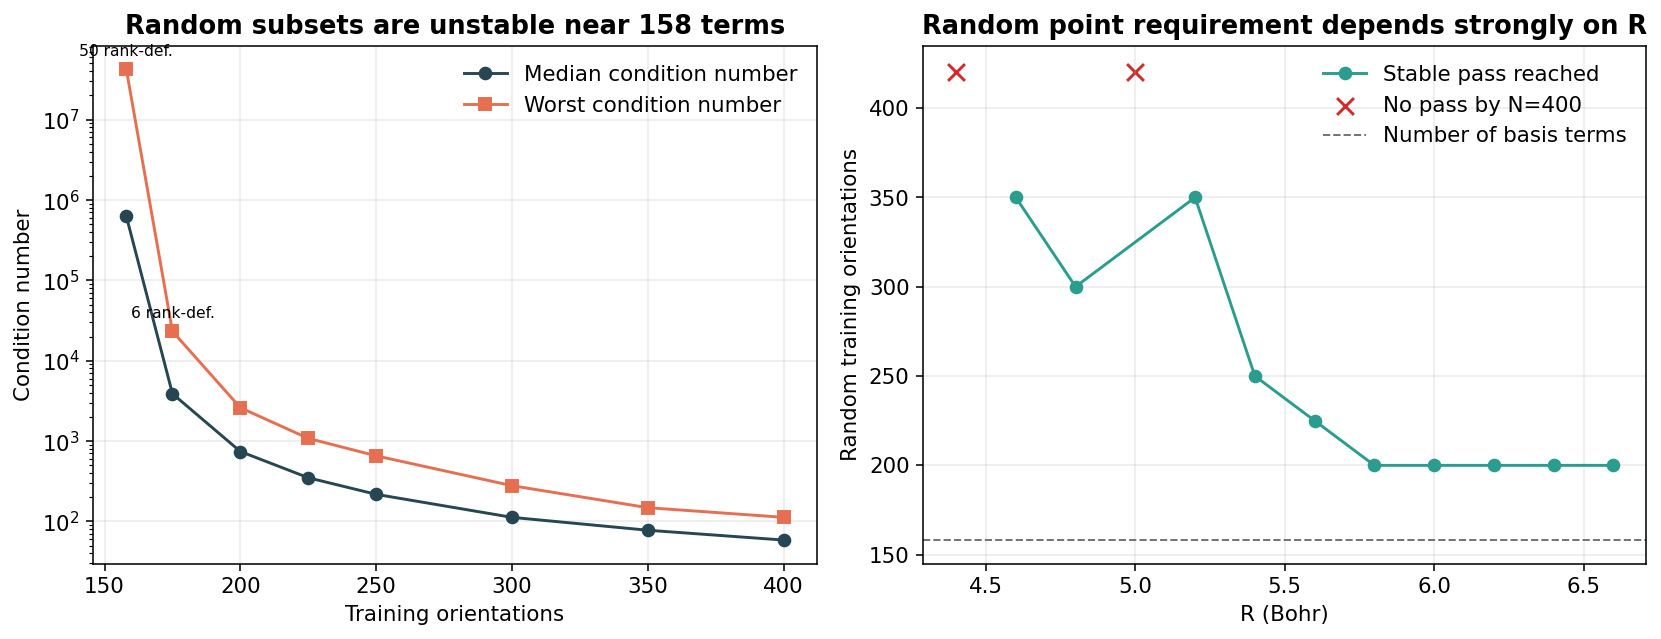

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))

numerical = point_count_numerical_summary_r44.sort_values("Training points")
axes[0].plot(numerical["Training points"], numerical["median_condition_number"],
             marker="o", color="#264653", label="Median condition number")
axes[0].plot(numerical["Training points"], numerical["worst_condition_number"],
             marker="s", color="#e76f51", label="Worst condition number")
axes[0].set_yscale("log")
axes[0].set(xlabel="Training orientations", ylabel="Condition number",
            title="Random subsets are unstable near 158 terms")
for _, row in numerical.iterrows():
    if row["rank_deficient_fits"] > 0:
        axes[0].annotate(f"{int(row['rank_deficient_fits'])} rank-def.",
                         (row["Training points"], row["worst_condition_number"]),
                         xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
axes[0].legend(frameon=False)

threshold = random_threshold_summary.copy()
resolved = threshold["Stable passing count"].notna()
axes[1].plot(threshold.loc[resolved, "R"],
             threshold.loc[resolved, "Stable passing count"].astype(float),
             marker="o", color="#2a9d8f", label="Stable pass reached")
unresolved = ~resolved
axes[1].scatter(threshold.loc[unresolved, "R"], np.full(unresolved.sum(), 420),
                marker="x", s=75, color="#d62828", label="No pass by N=400")
axes[1].axhline(158, color="0.45", linestyle="--", linewidth=1,
                label="Number of basis terms")
axes[1].set(xlabel="R (Bohr)", ylabel="Random training orientations",
            title="Random point requirement depends strongly on R", ylim=(145, 435))
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

display(random_threshold_summary[[
    "R", "Stable passing count", "N=400 worst individual normalized error"
]].round(3))


**What this shows.** At 158 points, every (R=4.4) random fit is rank
deficient; at 175, some remain deficient. Even at 400 training points, the
strict screen is unresolved at (R=4.4) and 5.0. The worst errors concentrate
at high-leverage geometries.

**What it does not show.** It does not imply that 400 arbitrary new calculations
are insufficient. It shows that random subsets are an inefficient design for
this fixed basis and candidate geometry.

**Supported conclusion.** Point count alone is the wrong control variable;
angular information content must enter the design.


<a id="doptimal"></a>

## 7. Geometry-only D-optimal selection

### Why this mathematical structure is appropriate

For a linear expansion (V=M c), the geometry matrix (M) is known before any
electronic-structure energies are calculated. A QR seed establishes full-rank
coverage, and greedy D-optimal augmentation favors rows that expand the
information volume. The ordering therefore uses angles and basis functions—but
no energy labels.

Uniform, leverage-weighted, and D-optimal designs are evaluated on the same
known 500-angle grid. This is retrospective reconstruction, but the selection
rule itself is prospectively reproducible.


In [10]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — geometry-only global sampling designs

# --- v2 source cell 81 ---
from scipy.linalg import qr


def whiten_candidate_design(candidate_matrix):
    """
    Whiten columns so the complete candidate information matrix is I.
    """
    information_matrix = (
        candidate_matrix.T
        @ candidate_matrix
    )

    eigenvalues, eigenvectors = np.linalg.eigh(
        information_matrix
    )

    if np.any(eigenvalues <= 0.0):
        raise np.linalg.LinAlgError(
            "Candidate design matrix is not full column rank."
        )

    inverse_square_root = (
        eigenvectors
        @ np.diag(1.0 / np.sqrt(eigenvalues))
        @ eigenvectors.T
    )

    whitened_matrix = (
        candidate_matrix
        @ inverse_square_root
    )

    return whitened_matrix


def qr_seeded_greedy_d_optimal_order(
    candidate_matrix,
    n_initial=None,
    recompute_interval=50,
):
    """
    Return a nested D-optimal-style ordering of candidate rows.

    The first p rows are chosen through column-pivoted QR of X.T,
    where p is the number of fitted coefficients. Remaining rows
    are added by maximum determinant gain.
    """
    n_candidates, n_parameters = candidate_matrix.shape

    if n_initial is None:
        n_initial = n_parameters

    if n_initial != n_parameters:
        raise ValueError(
            "This implementation uses exactly one QR-selected "
            "initial row per fitted parameter."
        )

    if n_candidates < n_parameters:
        raise ValueError(
            "Fewer candidate rows than fitted parameters."
        )

    X = whiten_candidate_design(
        candidate_matrix
    )

    # Pivoted QR of X.T selects informative rows of X.
    _, _, pivot_order = qr(
        X.T,
        pivoting=True,
        mode="economic",
    )

    selected_order = list(
        np.asarray(
            pivot_order[:n_parameters],
            dtype=int,
        )
    )

    selected_mask = np.zeros(
        n_candidates,
        dtype=bool,
    )
    selected_mask[selected_order] = True

    X_selected = X[selected_order]

    information_inverse = np.linalg.inv(
        X_selected.T @ X_selected
    )

    n_additions = n_candidates - n_parameters

    for addition in range(n_additions):
        predictive_variance = np.einsum(
            "ij,jk,ik->i",
            X,
            information_inverse,
            X,
        )

        predictive_variance[selected_mask] = -np.inf

        next_index = int(
            np.argmax(predictive_variance)
        )

        selected_order.append(next_index)
        selected_mask[next_index] = True

        x_next = X[next_index]
        inverse_times_x = (
            information_inverse
            @ x_next
        )

        denominator = (
            1.0
            + x_next @ inverse_times_x
        )

        information_inverse = (
            information_inverse
            - np.outer(
                inverse_times_x,
                inverse_times_x,
            )
            / denominator
        )

        # Periodically recompute the inverse to limit accumulated
        # floating-point error in repeated rank-one updates.
        if (
            (addition + 1) % recompute_interval == 0
            and addition + 1 < n_additions
        ):
            selected_indices = np.asarray(
                selected_order,
                dtype=int,
            )

            X_selected = X[selected_indices]

            information_inverse = np.linalg.inv(
                X_selected.T @ X_selected
            )

    return np.asarray(
        selected_order,
        dtype=int,
    )

# --- v2 source cell 90 ---
GLOBAL_DESIGN_N_REPEATS = 10
GLOBAL_DESIGN_RANDOM_SEED = 20260714

n_orientations = EXPECTED_POINTS_PER_R

uniform_selection_probability = np.full(
    n_orientations,
    1.0 / n_orientations,
)

leverage_selection_probability = (
    orientation_leverage
    / orientation_leverage.sum()
)

mixed_selection_probability = (
    0.5 * uniform_selection_probability
    + 0.5 * leverage_selection_probability
)


def weighted_order_from_draws(
    selection_probabilities,
    uniform_draws,
):
    """
    Generate a weighted random permutation using an exponential race.
    """
    selection_probabilities = np.asarray(
        selection_probabilities,
        dtype=float,
    )

    uniform_draws = np.clip(
        np.asarray(uniform_draws, dtype=float),
        np.finfo(float).tiny,
        1.0,
    )

    priority_keys = (
        -np.log(uniform_draws)
        / selection_probabilities
    )

    return np.argsort(priority_keys)

# --- v2 source cell 91 ---
global_uniform_orders = []
global_mixed_leverage_orders = []
global_pure_leverage_orders = []

for replicate in range(GLOBAL_DESIGN_N_REPEATS):
    rng = np.random.default_rng(
        np.random.SeedSequence([
            GLOBAL_DESIGN_RANDOM_SEED,
            replicate,
        ])
    )

    common_draws = rng.random(
        n_orientations
    )

    global_uniform_orders.append(
        weighted_order_from_draws(
            uniform_selection_probability,
            common_draws,
        )
    )

    global_mixed_leverage_orders.append(
        weighted_order_from_draws(
            mixed_selection_probability,
            common_draws,
        )
    )

    global_pure_leverage_orders.append(
        weighted_order_from_draws(
            leverage_selection_probability,
            common_draws,
        )
    )

# --- v2 source cell 92 ---
global_d_optimal_order = (
    qr_seeded_greedy_d_optimal_order(
        M_orientation
    )
)

global_design_orders = {
    "Uniform random": global_uniform_orders,
    "50% leverage mixture": (
        global_mixed_leverage_orders
    ),
    "Pure leverage-weighted": (
        global_pure_leverage_orders
    ),
    "QR + greedy D-optimal": [
        global_d_optimal_order
    ],
}

# --- v2 source cell 93 ---
global_design_audit_rows = []

expected_ids = set(
    range(EXPECTED_POINTS_PER_R)
)

for method_name, method_orders in (
    global_design_orders.items()
):
    for replicate, order in enumerate(method_orders):
        order = np.asarray(order, dtype=int)

        global_design_audit_rows.append({
            "Sampling method": method_name,
            "Replicate": replicate,
            "Length": len(order),
            "Unique orientations": len(
                np.unique(order)
            ),
            "Complete permutation": (
                set(order) == expected_ids
            ),
        })

global_design_audit = pd.DataFrame(
    global_design_audit_rows
)

print("=== Global-design integrity audit ===")

print(
    global_design_audit
    .groupby("Sampling method", sort=False)
    .agg(
        Replicates=("Replicate", "count"),
        Minimum_length=("Length", "min"),
        Minimum_unique=(
            "Unique orientations",
            "min",
        ),
        All_complete=(
            "Complete permutation",
            "all",
        ),
    )
    .reset_index()
    .to_string(index=False)
)

# --- v2 source cell 94 ---
def run_fixed_design_reconstruction_at_R(
    df,
    target_R,
    design_matrix,
    design_orders,
    training_sizes=POINT_COUNT_VALUES,
    rcond=LSTSQ_RCOND,
):
    """
    Fit each global subset and evaluate both the complete angular
    grid and the unselected complement.

    Selection orders must be constructed without using energies.
    """
    df_r = df[np.isclose(df["R"], target_R)].copy()

    truth = (
        df_r
        .set_index("orientation_id")["V"]
        .reindex(range(EXPECTED_POINTS_PER_R))
        .to_numpy()
    )

    all_ids = np.arange(
        EXPECTED_POINTS_PER_R
    )

    full_coefficients, _, _, _ = np.linalg.lstsq(
        design_matrix,
        truth,
        rcond=rcond,
    )

    full_projection = (
        design_matrix
        @ full_coefficients
    )

    highest_leverage_ids = set(
        np.argsort(orientation_leverage)[-20:]
    )

    full_grid_rows = []
    complement_rows = []
    guardrail_rows = []
    diagnostic_rows = []

    for method_name, method_orders in design_orders.items():
        for replicate, order in enumerate(method_orders):
            order = np.asarray(order, dtype=int)

            for training_N in training_sizes:
                training_N = int(training_N)

                selected_ids = order[:training_N]

                complement_ids = np.setdiff1d(
                    all_ids,
                    selected_ids,
                    assume_unique=True,
                )

                M_train = design_matrix[selected_ids]
                y_train = truth[selected_ids]

                (
                    coefficients,
                    _,
                    retained_rank,
                    singular_values,
                ) = np.linalg.lstsq(
                    M_train,
                    y_train,
                    rcond=rcond,
                )

                prediction = (
                    design_matrix
                    @ coefficients
                )

                full_score = score_relevant_predictions(
                    truth,
                    prediction,
                )
                full_score.insert(
                    0,
                    "Replicate",
                    replicate,
                )
                full_score.insert(
                    0,
                    "Training points",
                    training_N,
                )
                full_score.insert(
                    0,
                    "Sampling method",
                    method_name,
                )
                full_score.insert(0, "R", target_R)
                full_grid_rows.append(full_score)

                complement_score = (
                    score_relevant_predictions(
                        truth[complement_ids],
                        prediction[complement_ids],
                    )
                )
                complement_score.insert(
                    0,
                    "Replicate",
                    replicate,
                )
                complement_score.insert(
                    0,
                    "Training points",
                    training_N,
                )
                complement_score.insert(
                    0,
                    "Sampling method",
                    method_name,
                )
                complement_score.insert(
                    0,
                    "R",
                    target_R,
                )
                complement_rows.append(
                    complement_score
                )

                guardrail_score = (
                    score_guardrail_predictions(
                        truth,
                        prediction,
                    )
                )
                guardrail_score.insert(
                    0,
                    "Replicate",
                    replicate,
                )
                guardrail_score.insert(
                    0,
                    "Training points",
                    training_N,
                )
                guardrail_score.insert(
                    0,
                    "Sampling method",
                    method_name,
                )
                guardrail_score.insert(
                    0,
                    "R",
                    target_R,
                )
                guardrail_rows.append(
                    guardrail_score
                )

                condition_number = (
                    singular_values[0]
                    / singular_values[-1]
                    if singular_values[-1] > 0.0
                    else np.inf
                )

                prediction_deviation = (
                    prediction
                    - full_projection
                )

                relative_coefficient_error = (
                    np.linalg.norm(
                        coefficients
                        - full_coefficients
                    )
                    / np.linalg.norm(
                        full_coefficients
                    )
                )

                selected_high_leverage = len(
                    highest_leverage_ids.intersection(
                        selected_ids
                    )
                )

                diagnostic_rows.append({
                    "R": target_R,
                    "Sampling method": method_name,
                    "Replicate": replicate,
                    "Training points": training_N,
                    "Complement points": len(
                        complement_ids
                    ),
                    "Retained rank": retained_rank,
                    "Rank deficient": (
                        retained_rank
                        < len(basis_indices)
                    ),
                    "Condition number": (
                        condition_number
                    ),
                    "Projection-deviation RMSE": (
                        np.sqrt(
                            np.mean(
                                prediction_deviation**2
                            )
                        )
                    ),
                    "Relative coefficient error": (
                        relative_coefficient_error
                    ),
                    "Top-20 leverage points selected": (
                        selected_high_leverage
                    ),
                })

    return {
        "full_grid": pd.concat(
            full_grid_rows,
            ignore_index=True,
        ),
        "complement": pd.concat(
            complement_rows,
            ignore_index=True,
        ),
        "guardrail": pd.concat(
            guardrail_rows,
            ignore_index=True,
        ),
        "diagnostics": pd.DataFrame(
            diagnostic_rows
        ),
        "truth": truth,
        "full_projection": full_projection,
        "full_coefficients": full_coefficients,
    }

# --- v2 source cell 95 ---
fixed_design_results_r44 = (
    run_fixed_design_reconstruction_at_R(
        df_all,
        target_R=4.4,
        design_matrix=M_orientation,
        design_orders=global_design_orders,
    )
)

# --- v2 source cell 96 ---
def summarize_fixed_design_reconstruction(
    fixed_design_results,
):
    full_grid = fixed_design_results["full_grid"]
    guardrail = fixed_design_results["guardrail"]
    diagnostics = fixed_design_results["diagnostics"]

    band_summary = (
        full_grid
        .groupby(
            [
                "Sampling method",
                "Training points",
                "Energy band",
            ],
            sort=False,
        )
        .agg(
            mean_MAE=(
                "MAE (cm^-1)",
                "mean",
            ),
            mean_P95=(
                "P95 normalized error",
                "mean",
            ),
            worst_max=(
                "Max normalized error",
                "max",
            ),
            mean_within=(
                "Within tolerance (%)",
                "mean",
            ),
        )
        .reset_index()
    )

    physical_summary = (
        band_summary
        .groupby(
            [
                "Sampling method",
                "Training points",
            ],
            sort=False,
        )
        .agg(
            worst_band_mean_P95=(
                "mean_P95",
                "max",
            ),
            minimum_band_mean_within=(
                "mean_within",
                "min",
            ),
            worst_individual_normalized_error=(
                "worst_max",
                "max",
            ),
        )
        .reset_index()
    )

    guardrail_summary = (
        guardrail
        .groupby(
            [
                "Sampling method",
                "Training points",
            ],
            sort=False,
        )
        .agg(
            worst_minimum_guardrail_prediction=(
                "Minimum predicted V",
                "min",
            ),
            worst_percent_below_3000=(
                "Predicted below 3000 (%)",
                "max",
            ),
        )
        .reset_index()
    )

    diagnostic_summary = (
        diagnostics
        .groupby(
            [
                "Sampling method",
                "Training points",
            ],
            sort=False,
        )
        .agg(
            design_replicates=(
                "Replicate",
                "count",
            ),
            minimum_rank=(
                "Retained rank",
                "min",
            ),
            rank_deficient_designs=(
                "Rank deficient",
                "sum",
            ),
            median_condition_number=(
                "Condition number",
                "median",
            ),
            worst_condition_number=(
                "Condition number",
                "max",
            ),
            mean_projection_deviation_RMSE=(
                "Projection-deviation RMSE",
                "mean",
            ),
            worst_projection_deviation_RMSE=(
                "Projection-deviation RMSE",
                "max",
            ),
            mean_relative_coefficient_error=(
                "Relative coefficient error",
                "mean",
            ),
            mean_top20_leverage_selected=(
                "Top-20 leverage points selected",
                "mean",
            ),
        )
        .reset_index()
    )

    summary = (
        physical_summary
        .merge(
            guardrail_summary,
            on=[
                "Sampling method",
                "Training points",
            ],
        )
        .merge(
            diagnostic_summary,
            on=[
                "Sampling method",
                "Training points",
            ],
        )
    )

    summary["Full-grid screen passed"] = (
        (summary["worst_band_mean_P95"] <= 1.0)
        & (
            summary[
                "minimum_band_mean_within"
            ] >= 95.0
        )
        & (
            summary[
                "rank_deficient_designs"
            ] == 0
        )
        & (
            summary[
                "worst_percent_below_3000"
            ] == 0.0
        )
    )

    return (
        summary
        .sort_values(
            [
                "Training points",
                "Sampling method",
            ]
        )
        .reset_index(drop=True)
    )

# --- v2 source cell 97 ---
fixed_design_summary_r44 = (
    summarize_fixed_design_reconstruction(
        fixed_design_results_r44
    )
)

print(
    "=== R = 4.4: Fixed-design full-grid reconstruction ==="
)

print(
    fixed_design_summary_r44[
        [
            "Training points",
            "Sampling method",
            "design_replicates",
            "minimum_rank",
            "median_condition_number",
            "worst_band_mean_P95",
            "minimum_band_mean_within",
            "worst_individual_normalized_error",
            "mean_projection_deviation_RMSE",
            "mean_relative_coefficient_error",
            "mean_top20_leverage_selected",
            "worst_minimum_guardrail_prediction",
            "Full-grid screen passed",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

# --- v2 source cell 99 ---
D_OPTIMAL_DIAGNOSTIC_COUNTS = [
    158,
    175,
    200,
    225,
]

d_optimal_full_grid_detail = (
    fixed_design_results_r44["full_grid"]
    .loc[
        lambda table: (
            (
                table["Sampling method"]
                == "QR + greedy D-optimal"
            )
            & (
                table["Training points"].isin(
                    D_OPTIMAL_DIAGNOSTIC_COUNTS
                )
            )
        ),
        [
            "Training points",
            "Energy band",
            "N",
            "MAE (cm^-1)",
            "RMSE (cm^-1)",
            "P95 normalized error",
            "Max normalized error",
            "Within tolerance (%)",
        ],
    ]
    .rename(
        columns={
            "N": "Full-grid band N",
            "MAE (cm^-1)": "Full-grid MAE",
            "RMSE (cm^-1)": "Full-grid RMSE",
            "P95 normalized error": (
                "Full-grid P95 normalized error"
            ),
            "Max normalized error": (
                "Full-grid maximum normalized error"
            ),
            "Within tolerance (%)": (
                "Full-grid within tolerance (%)"
            ),
        }
    )
)

# --- v2 source cell 100 ---
d_optimal_complement_detail = (
    fixed_design_results_r44["complement"]
    .loc[
        lambda table: (
            (
                table["Sampling method"]
                == "QR + greedy D-optimal"
            )
            & (
                table["Training points"].isin(
                    D_OPTIMAL_DIAGNOSTIC_COUNTS
                )
            )
        ),
        [
            "Training points",
            "Energy band",
            "N",
            "MAE (cm^-1)",
            "RMSE (cm^-1)",
            "P95 normalized error",
            "Max normalized error",
            "Within tolerance (%)",
        ],
    ]
    .rename(
        columns={
            "N": "Unselected band N",
            "MAE (cm^-1)": "Complement MAE",
            "RMSE (cm^-1)": "Complement RMSE",
            "P95 normalized error": (
                "Complement P95 normalized error"
            ),
            "Max normalized error": (
                "Complement maximum normalized error"
            ),
            "Within tolerance (%)": (
                "Complement within tolerance (%)"
            ),
        }
    )
)

# --- v2 source cell 101 ---
d_optimal_selected_vs_complement_r44 = (
    d_optimal_full_grid_detail
    .merge(
        d_optimal_complement_detail,
        on=[
            "Training points",
            "Energy band",
        ],
        how="left",
    )
)

d_optimal_selected_vs_complement_r44[
    "Selected band N"
] = (
    d_optimal_selected_vs_complement_r44[
        "Full-grid band N"
    ]
    - d_optimal_selected_vs_complement_r44[
        "Unselected band N"
    ]
)

d_optimal_selected_vs_complement_r44 = (
    d_optimal_selected_vs_complement_r44[
        [
            "Training points",
            "Energy band",
            "Full-grid band N",
            "Selected band N",
            "Unselected band N",
            "Full-grid MAE",
            "Complement MAE",
            "Full-grid P95 normalized error",
            "Complement P95 normalized error",
            "Full-grid maximum normalized error",
            "Complement maximum normalized error",
            "Full-grid within tolerance (%)",
            "Complement within tolerance (%)",
        ]
    ]
    .sort_values(
        [
            "Training points",
            "Energy band",
        ]
    )
    .reset_index(drop=True)
)


In [11]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — fixed-design raw/switch due diligence
# Each design is selected without energy labels. Scores use only the
# unselected complement of the known grid.
SWITCH_DUE_DILIGENCE_COUNTS = np.array([165, 175, 250, 400], dtype=int)
SWITCH_DUE_DILIGENCE_ORDERS = {
    "Uniform random": global_uniform_orders,
    "QR + greedy D-optimal": [global_d_optimal_order],
}

switch_rows = []
switch_guardrail_rows = []
all_ids = np.arange(EXPECTED_POINTS_PER_R)

for sampling_name, orders in SWITCH_DUE_DILIGENCE_ORDERS.items():
    for replicate, order in enumerate(orders):
        for training_N in SWITCH_DUE_DILIGENCE_COUNTS:
            selected_ids = np.asarray(order[:training_N], dtype=int)
            complement_ids = np.setdiff1d(all_ids, selected_ids)
            M_train = M_orientation[selected_ids]
            M_test = M_orientation[complement_ids]

            for target_R in SHORT_RANGE_R_VALUES:
                truth = (
                    df_all[np.isclose(df_all["R"], target_R)]
                    .set_index("orientation_id")["V"]
                    .reindex(all_ids)
                    .to_numpy()
                )
                complement_truth = truth[complement_ids]

                for target_name, target_function in TARGET_METHODS.items():
                    target_values = target_function(truth)
                    coefficients, *_ = np.linalg.lstsq(
                        M_train, target_values[selected_ids], rcond=LSTSQ_RCOND
                    )
                    prediction = M_test @ coefficients
                    relevant = complement_truth < PHYSICAL_ENERGY_CEILING
                    if np.any(relevant):
                        absolute_error = np.abs(
                            prediction[relevant] - complement_truth[relevant]
                        )
                        normalized_error = hybrid_normalized_error(
                            complement_truth[relevant], prediction[relevant]
                        )
                        target_distortion = np.abs(
                            target_function(complement_truth[relevant])
                            - complement_truth[relevant]
                        )
                        switch_rows.append({
                            "R": float(target_R),
                            "Sampling method": sampling_name,
                            "Replicate": replicate,
                            "Training points": int(training_N),
                            "Target method": target_name,
                            "Relevant complement points": int(relevant.sum()),
                            "Raw-reference MAE": float(absolute_error.mean()),
                            "Target-distortion MAE": float(target_distortion.mean()),
                            "Worst normalized error": float(normalized_error.max()),
                            "Within tolerance (%)": float(
                                100.0 * np.mean(normalized_error <= 1.0)
                            ),
                        })

                    guardrail = complement_truth >= PHYSICAL_ENERGY_CEILING
                    if np.any(guardrail):
                        guardrail_prediction = prediction[guardrail]
                        switch_guardrail_rows.append({
                            "Sampling method": sampling_name,
                            "Training points": int(training_N),
                            "Target method": target_name,
                            "Minimum guardrail prediction": float(
                                guardrail_prediction.min()
                            ),
                            "Percent below 3000": float(
                                100.0 * np.mean(
                                    guardrail_prediction < GUARDRAIL_WARNING_THRESHOLD
                                )
                            ),
                        })

switch_due_diligence_detail = pd.DataFrame(switch_rows)
switch_guardrail_detail = pd.DataFrame(switch_guardrail_rows)

switch_due_diligence_global_summary = (
    switch_due_diligence_detail
    .groupby(["Sampling method", "Training points", "Target method"], sort=True)
    .agg(
        Mean_radial_complement_MAE=("Raw-reference MAE", "mean"),
        Mean_radial_target_distortion=("Target-distortion MAE", "mean"),
        Worst_individual_normalized_error=("Worst normalized error", "max"),
        Minimum_within_tolerance_percent=("Within tolerance (%)", "min"),
    )
    .reset_index()
)
switch_guardrail_summary = (
    switch_guardrail_detail
    .groupby(["Sampling method", "Training points", "Target method"], sort=True)
    .agg(
        Minimum_guardrail_prediction=("Minimum guardrail prediction", "min"),
        Worst_percent_below_3000=("Percent below 3000", "max"),
    )
    .reset_index()
)


,R,Relevant orientations,Spearman correlation,Descriptive p-value
0,4.4,179,0.791,0.0
1,5.0,272,0.502,0.0


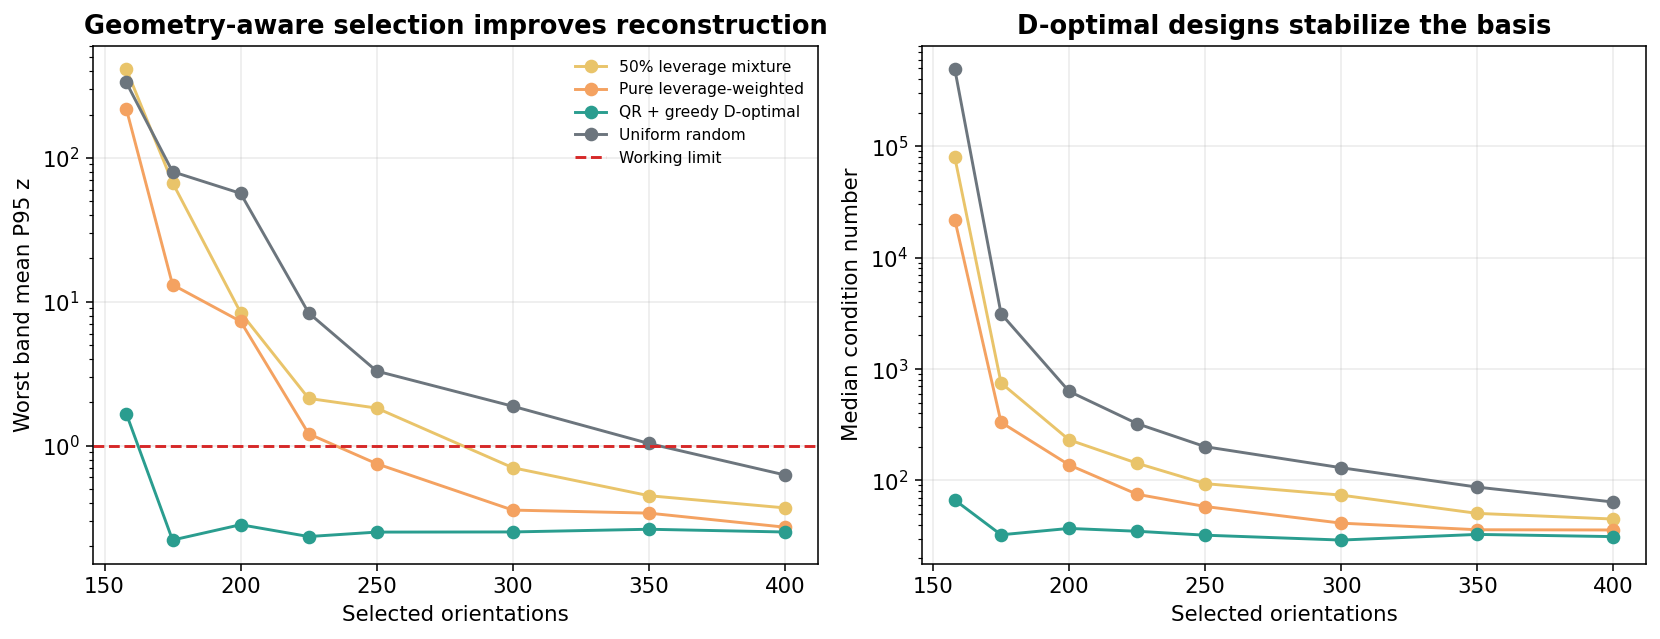

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
method_colors = {
    "Uniform random": "#6c757d",
    "50% leverage mixture": "#e9c46a",
    "Pure leverage-weighted": "#f4a261",
    "QR + greedy D-optimal": "#2a9d8f",
}
for method, group in fixed_design_summary_r44.groupby("Sampling method", sort=False):
    group = group.sort_values("Training points")
    axes[0].plot(group["Training points"], group["worst_band_mean_P95"],
                 marker="o", label=method, color=method_colors[method])
    axes[1].plot(group["Training points"], group["median_condition_number"],
                 marker="o", label=method, color=method_colors[method])
axes[0].axhline(1.0, color="#d62828", linestyle="--", label="Working limit")
axes[0].set_yscale("log")
axes[0].set(xlabel="Selected orientations", ylabel="Worst band mean P95 z",
            title="Geometry-aware selection improves reconstruction")
axes[1].set_yscale("log")
axes[1].set(xlabel="Selected orientations", ylabel="Median condition number",
            title="D-optimal designs stabilize the basis")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

display(leverage_error_summary.round(3))


**What this shows.** D-optimal prefixes produce full-rank, well-conditioned
designs close to the 158-coefficient limit and reconstruct the known grid much
more accurately than random designs of the same size. Leverage explains much
of the random-fit error, but pure leverage weighting is not as consistently
effective as a globally balanced D-optimal design.

**What it does not show.** The 500-angle grid was used to develop and score the
ordering. This is not independent evidence that the same point count suffices
at unseen continuous angles.

**Supported conclusion.** D-optimal selection is a credible prospective
sampling rule, subject to a frozen independent validation set.


<a id="interpretation"></a>

## 8. Correct interpretation of the 175–182-point result

The first known-grid strict pass occurs at 161 points, but a threshold is not
the same as a robust design. We therefore examine tolerance headroom, every
single substitution, and label-free reoptimization when a selected geometry is
unavailable. Acceptance criteria are also varied over 36 plausible working
specifications.


In [13]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — refined D-optimal threshold and headroom curves

# --- v2 source cell 108 ---
D_OPTIMAL_REFINED_COUNTS = np.arange(
    len(basis_indices),
    201,
    dtype=int,
)

D_OPTIMAL_ONLY_ORDERS = {
    "QR + greedy D-optimal": [
        global_d_optimal_order
    ],
}

d_optimal_radial_results = {}

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    d_optimal_radial_results[target_R] = (
        run_fixed_design_reconstruction_at_R(
            df_all,
            target_R=target_R,
            design_matrix=M_orientation,
            design_orders=D_OPTIMAL_ONLY_ORDERS,
            training_sizes=D_OPTIMAL_REFINED_COUNTS,
        )
    )

    print(
        f"Completed refined D-optimal curve "
        f"at R = {target_R:.1f}"
    )

# --- v2 source cell 109 ---
d_optimal_full_grid_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "full_grid"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

d_optimal_complement_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "complement"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

d_optimal_guardrail_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "guardrail"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

d_optimal_diagnostics_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "diagnostics"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

# --- v2 source cell 110 ---
d_optimal_full_band_summary = (
    d_optimal_full_grid_all_R
    .groupby(
        ["R", "Training points", "Energy band"],
        sort=True,
    )
    .agg(
        N=("N", "first"),
        MAE=("MAE (cm^-1)", "first"),
        P95_normalized_error=(
            "P95 normalized error",
            "first",
        ),
        maximum_normalized_error=(
            "Max normalized error",
            "first",
        ),
        within_tolerance_percent=(
            "Within tolerance (%)",
            "first",
        ),
    )
    .reset_index()
)

d_optimal_full_screen = (
    d_optimal_full_band_summary
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        full_worst_band_P95=(
            "P95_normalized_error",
            "max",
        ),
        full_worst_individual_error=(
            "maximum_normalized_error",
            "max",
        ),
        full_minimum_band_within_percent=(
            "within_tolerance_percent",
            "min",
        ),
    )
    .reset_index()
)

# --- v2 source cell 111 ---
d_optimal_complement_band_summary = (
    d_optimal_complement_all_R
    .groupby(
        ["R", "Training points", "Energy band"],
        sort=True,
    )
    .agg(
        Unselected_N=("N", "first"),
        Complement_MAE=(
            "MAE (cm^-1)",
            "first",
        ),
        Complement_P95_normalized_error=(
            "P95 normalized error",
            "first",
        ),
        Complement_maximum_normalized_error=(
            "Max normalized error",
            "first",
        ),
        Complement_within_tolerance_percent=(
            "Within tolerance (%)",
            "first",
        ),
    )
    .reset_index()
)

d_optimal_complement_screen = (
    d_optimal_complement_band_summary
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        complement_worst_band_P95=(
            "Complement_P95_normalized_error",
            "max",
        ),
        complement_worst_individual_error=(
            "Complement_maximum_normalized_error",
            "max",
        ),
        complement_minimum_band_within_percent=(
            "Complement_within_tolerance_percent",
            "min",
        ),
    )
    .reset_index()
)

# --- v2 source cell 112 ---
d_optimal_guardrail_screen = (
    d_optimal_guardrail_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        guardrail_N=("N", "first"),
        minimum_guardrail_prediction=(
            "Minimum predicted V",
            "first",
        ),
        percent_guardrail_below_3000=(
            "Predicted below 3000 (%)",
            "first",
        ),
        percent_guardrail_below_1000=(
            "Predicted below 1000 (%)",
            "first",
        ),
    )
    .reset_index()
)

d_optimal_numerical_screen = (
    d_optimal_diagnostics_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        retained_rank=("Retained rank", "first"),
        condition_number=(
            "Condition number",
            "first",
        ),
        projection_deviation_RMSE=(
            "Projection-deviation RMSE",
            "first",
        ),
        relative_coefficient_error=(
            "Relative coefficient error",
            "first",
        ),
        top20_leverage_selected=(
            "Top-20 leverage points selected",
            "first",
        ),
    )
    .reset_index()
)

# --- v2 source cell 113 ---
d_optimal_screen_all_R = (
    d_optimal_full_screen
    .merge(
        d_optimal_complement_screen,
        on=["R", "Training points"],
        how="left",
    )
    .merge(
        d_optimal_guardrail_screen,
        on=["R", "Training points"],
        how="left",
    )
    .merge(
        d_optimal_numerical_screen,
        on=["R", "Training points"],
        how="left",
    )
)

# --- v2 source cell 114 ---
def find_stable_threshold(
    curve,
    pass_column,
):
    curve = (
        curve
        .sort_values("Training points")
        .reset_index(drop=True)
    )

    passing_counts = curve.loc[
        curve[pass_column],
        "Training points",
    ].tolist()

    first_passing = (
        min(passing_counts)
        if passing_counts
        else pd.NA
    )

    stable_passing = pd.NA

    for row_index in range(len(curve)):
        if curve.loc[
            row_index:,
            pass_column,
        ].all():
            stable_passing = int(
                curve.loc[
                    row_index,
                    "Training points",
                ]
            )
            break

    return first_passing, stable_passing

# --- v2 source cell 115 ---
def apply_d_optimal_screen_criteria(
    screen_table,
):
    """
    Apply physical, numerical, and guardrail criteria.

    A radial slice with no guardrail observations passes the
    guardrail criterion vacuously.
    """
    corrected = screen_table.copy()

    corrected["Guardrail screen passed"] = (
        (
            corrected["guardrail_N"] == 0
        )
        | (
            corrected[
                "percent_guardrail_below_3000"
            ].fillna(0.0) == 0.0
        )
    )

    corrected["Standard screen passed"] = (
        (
            corrected[
                "full_worst_band_P95"
            ] <= 1.0
        )
        & (
            corrected[
                "full_minimum_band_within_percent"
            ] >= 95.0
        )
        & (
            corrected[
                "complement_worst_band_P95"
            ] <= 1.0
        )
        & (
            corrected[
                "complement_minimum_band_within_percent"
            ] >= 95.0
        )
        & (
            corrected["retained_rank"]
            == len(basis_indices)
        )
        & corrected["Guardrail screen passed"]
    )

    corrected["Strict screen passed"] = (
        (
            corrected[
                "full_worst_individual_error"
            ] <= 1.0
        )
        & (
            corrected[
                "complement_worst_individual_error"
            ] <= 1.0
        )
        & (
            corrected["retained_rank"]
            == len(basis_indices)
        )
        & corrected["Guardrail screen passed"]
    )

    return corrected

# --- v2 source cell 116 ---
d_optimal_screen_all_R = (
    apply_d_optimal_screen_criteria(
        d_optimal_screen_all_R
    )
)

corrected_threshold_rows = []

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    radial_curve = d_optimal_screen_all_R[
        np.isclose(
            d_optimal_screen_all_R["R"],
            target_R,
        )
    ]

    (
        first_standard,
        stable_standard,
    ) = find_stable_threshold(
        radial_curve,
        "Standard screen passed",
    )

    (
        first_strict,
        stable_strict,
    ) = find_stable_threshold(
        radial_curve,
        "Strict screen passed",
    )

    corrected_threshold_rows.append({
        "R": target_R,
        "First standard pass": first_standard,
        "Stable standard pass": stable_standard,
        "First strict pass": first_strict,
        "Stable strict pass": stable_strict,
    })

d_optimal_threshold_summary = pd.DataFrame(
    corrected_threshold_rows
)

for column in [
    "First standard pass",
    "Stable standard pass",
    "First strict pass",
    "Stable strict pass",
]:
    d_optimal_threshold_summary[column] = (
        d_optimal_threshold_summary[column]
        .astype("Int64")
    )

print(
    "=== Corrected refined D-optimal thresholds by radius ==="
)

print(
    d_optimal_threshold_summary.to_string(
        index=False
    )
)

# --- v2 source cell 119 ---
d_optimal_margin_table = d_optimal_screen_all_R.copy()

# The full-grid maximum already contains every complement point.
d_optimal_margin_table[
    "finite_grid_worst_normalized_error"
] = d_optimal_margin_table[
    "full_worst_individual_error"
]

margin_rows = []

for training_N in D_OPTIMAL_REFINED_COUNTS:
    count_table = d_optimal_margin_table[
        d_optimal_margin_table["Training points"] == training_N
    ]

    limiting_index = count_table[
        "finite_grid_worst_normalized_error"
    ].idxmax()
    limiting_row = count_table.loc[limiting_index]
    worst_normalized_error = float(
        limiting_row["finite_grid_worst_normalized_error"]
    )

    margin_rows.append({
        "Training points": int(training_N),
        "Worst normalized error": worst_normalized_error,
        "Tolerance headroom": 1.0 - worst_normalized_error,
        "Tolerance safety factor": (
            1.0 / worst_normalized_error
            if worst_normalized_error > 0.0
            else np.inf
        ),
        "Limiting R": limiting_row["R"],
        "Maximum condition number": count_table[
            "condition_number"
        ].max(),
        "Maximum relative coefficient error": count_table[
            "relative_coefficient_error"
        ].max(),
        "Minimum guardrail prediction": count_table[
            "minimum_guardrail_prediction"
        ].min(skipna=True),
        "All radii strict pass": count_table[
            "Strict screen passed"
        ].all(),
    })

d_optimal_margin_summary = pd.DataFrame(margin_rows)

# --- v2 source cell 120 ---
MARGIN_DISPLAY_COUNTS = [
    158,
    159,
    160,
    161,
    162,
    165,
    170,
    175,
    180,
    190,
    200,
]

print(
    "=== D-optimal short-range tolerance headroom ==="
)

print(
    d_optimal_margin_summary[
        d_optimal_margin_summary[
            "Training points"
        ].isin(MARGIN_DISPLAY_COUNTS)
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

# --- v2 source cell 121 ---
best_margin_index = (
    d_optimal_margin_summary[
        "Worst normalized error"
    ].idxmin()
)

best_margin_row = (
    d_optimal_margin_summary.loc[
        best_margin_index
    ]
)

print(
    "\nBest worst-case performance between "
    "158 and 200 points:"
)

print(
    f"Training points: "
    f"{int(best_margin_row['Training points'])}"
)

print(
    f"Worst normalized error: "
    f"{best_margin_row['Worst normalized error']:.4f}"
)

print(
    f"Tolerance safety factor: "
    f"{best_margin_row['Tolerance safety factor']:.3f}"
)

print(
    f"Limiting R: "
    f"{best_margin_row['Limiting R']:.1f}"
)

# --- v2 source cell 122 ---
for target_factor in [1.25, 1.5, 2.0, 3.0]:
    eligible = d_optimal_margin_summary[
        d_optimal_margin_summary[
            "Tolerance safety factor"
        ] >= target_factor
    ]

    if len(eligible) > 0:
        first_count = int(
            eligible["Training points"].min()
        )

        print(
            f"First count with safety factor >= "
            f"{target_factor:.2f}: {first_count}"
        )
    else:
        print(
            f"No count through 200 reaches safety "
            f"factor >= {target_factor:.2f}"
        )


In [14]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — single-substitution and label-free recovery audits

# --- v2 source cell 124 ---
short_range_truth_matrix = np.column_stack(
    [
        (
            df_all[np.isclose(df_all["R"], float(R))]
            .set_index("orientation_id")["V"]
            .reindex(range(EXPECTED_POINTS_PER_R))
            .to_numpy()
        )
        for R in SHORT_RANGE_R_VALUES
    ]
)

marginal_design_rows = []

for position in range(158, 183):
    orientation_id = int(
        global_d_optimal_order[position - 1]
    )

    margin_match = d_optimal_margin_summary[
        d_optimal_margin_summary[
            "Training points"
        ] == position
    ]

    marginal_design_rows.append({
        "Design position": position,
        "orientation_id": orientation_id,
        "Theta_1": reference_angles.loc[
            reference_angles["orientation_id"]
            == orientation_id,
            "Theta_1",
        ].iloc[0],
        "Theta_2": reference_angles.loc[
            reference_angles["orientation_id"]
            == orientation_id,
            "Theta_2",
        ].iloc[0],
        "Phi": reference_angles.loc[
            reference_angles["orientation_id"]
            == orientation_id,
            "Phi",
        ].iloc[0],
        "Leverage": orientation_leverage[
            orientation_id
        ],
        "V at R=4.4": short_range_truth_matrix[
            orientation_id,
            np.where(
                np.isclose(
                    SHORT_RANGE_R_VALUES,
                    4.4,
                )
            )[0][0],
        ],
        "V at R=4.8": short_range_truth_matrix[
            orientation_id,
            np.where(
                np.isclose(
                    SHORT_RANGE_R_VALUES,
                    4.8,
                )
            )[0][0],
        ],
        "Worst normalized error at this count": (
            margin_match[
                "Worst normalized error"
            ].iloc[0]
        ),
    })

marginal_design_table = pd.DataFrame(
    marginal_design_rows
)

print(
    "=== D-optimal ordering near the strict threshold ==="
)

print(
    marginal_design_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

# --- v2 source cell 125 ---
def evaluate_fixed_subset_across_short_range(
    selected_ids,
    design_matrix=M_orientation,
    truth_matrix=short_range_truth_matrix,
    radial_values=SHORT_RANGE_R_VALUES,
    rcond=LSTSQ_RCOND,
):
    """
    Evaluate one fixed angular subset simultaneously across all
    short-range radial slices.
    """
    selected_ids = np.asarray(
        selected_ids,
        dtype=int,
    )

    all_ids = np.arange(
        design_matrix.shape[0]
    )

    selected_mask = np.zeros(
        design_matrix.shape[0],
        dtype=bool,
    )
    selected_mask[selected_ids] = True

    complement_mask = ~selected_mask

    M_selected = design_matrix[selected_ids]
    Y_selected = truth_matrix[selected_ids, :]

    (
        coefficient_matrix,
        _,
        retained_rank,
        singular_values,
    ) = np.linalg.lstsq(
        M_selected,
        Y_selected,
        rcond=rcond,
    )

    prediction_matrix = (
        design_matrix
        @ coefficient_matrix
    )

    condition_number = (
        singular_values[0]
        / singular_values[-1]
        if singular_values[-1] > 0.0
        else np.inf
    )

    radial_rows = []

    for radial_index, target_R in enumerate(
        radial_values
    ):
        truth = truth_matrix[:, radial_index]
        prediction = prediction_matrix[
            :,
            radial_index,
        ]

        relevant_mask = truth < PHYSICAL_ENERGY_CEILING

        tolerance = hybrid_tolerance(truth)

        normalized_error = (
            np.abs(prediction - truth)
            / tolerance
        )

        full_relevant_errors = (
            normalized_error[relevant_mask]
        )

        complement_relevant_mask = (
            relevant_mask
            & complement_mask
        )

        complement_relevant_errors = (
            normalized_error[
                complement_relevant_mask
            ]
        )

        guardrail_mask = truth >= PHYSICAL_ENERGY_CEILING

        if guardrail_mask.any():
            minimum_guardrail_prediction = (
                prediction[guardrail_mask].min()
            )

            guardrail_below_3000 = bool(
                np.any(
                    prediction[guardrail_mask]
                    < GUARDRAIL_WARNING_THRESHOLD
                )
            )
        else:
            minimum_guardrail_prediction = np.nan
            guardrail_below_3000 = False

        radial_rows.append({
            "R": float(target_R),
            "Full maximum normalized error": (
                full_relevant_errors.max()
            ),
            "Complement maximum normalized error": (
                complement_relevant_errors.max()
                if complement_relevant_errors.size > 0
                else 0.0
            ),
            "Minimum guardrail prediction": (
                minimum_guardrail_prediction
            ),
            "Guardrail below 3000": (
                guardrail_below_3000
            ),
        })

    radial_diagnostics = pd.DataFrame(
        radial_rows
    )

    combined_radial_error = radial_diagnostics[
        "Full maximum normalized error"
    ]

    limiting_index = (
        combined_radial_error.idxmax()
    )

    finite_guardrail_predictions = (
        radial_diagnostics[
            "Minimum guardrail prediction"
        ].dropna()
    )

    return {
        "Retained rank": retained_rank,
        "Condition number": condition_number,
        "Worst normalized error": (
            combined_radial_error.max()
        ),
        "Tolerance safety factor": (
            1.0 / combined_radial_error.max()
            if combined_radial_error.max() > 0.0
            else np.inf
        ),
        "Limiting R": radial_diagnostics.loc[
            limiting_index,
            "R",
        ],
        "Minimum guardrail prediction": (
            finite_guardrail_predictions.min()
            if len(finite_guardrail_predictions) > 0
            else np.nan
        ),
        "Any guardrail below 3000": (
            radial_diagnostics[
                "Guardrail below 3000"
            ].any()
        ),
        "Strict pass": (
            retained_rank == len(basis_indices)
            and combined_radial_error.max() <= 1.0
            and not radial_diagnostics[
                "Guardrail below 3000"
            ].any()
        ),
    }

# --- v2 source cell 126 ---
SUBSTITUTION_TEST_COUNTS = [
    161,
    175,
    180,
    182,
]

baseline_subset_rows = []

for training_N in SUBSTITUTION_TEST_COUNTS:
    baseline_metrics = (
        evaluate_fixed_subset_across_short_range(
            global_d_optimal_order[:training_N]
        )
    )

    baseline_subset_rows.append({
        "Training points": training_N,
        **baseline_metrics,
    })

baseline_subset_audit = pd.DataFrame(
    baseline_subset_rows
)

print(
    "=== Baseline subset audit before substitutions ==="
)

print(
    baseline_subset_audit.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

# --- v2 source cell 127 ---
single_substitution_rows = []

for training_N in SUBSTITUTION_TEST_COUNTS:
    baseline_selected = np.asarray(
        global_d_optimal_order[:training_N],
        dtype=int,
    )

    replacement_id = int(
        global_d_optimal_order[training_N]
    )

    for removed_position in range(training_N):
        removed_id = int(
            baseline_selected[removed_position]
        )

        modified_selected = (
            baseline_selected.copy()
        )

        modified_selected[
            removed_position
        ] = replacement_id

        metrics = (
            evaluate_fixed_subset_across_short_range(
                modified_selected
            )
        )

        single_substitution_rows.append({
            "Training points": training_N,
            "Removed position": (
                removed_position + 1
            ),
            "Removed orientation": removed_id,
            "Removed leverage": (
                orientation_leverage[removed_id]
            ),
            "Replacement orientation": (
                replacement_id
            ),
            "Replacement leverage": (
                orientation_leverage[
                    replacement_id
                ]
            ),
            **metrics,
        })

    print(
        f"Completed {training_N} single-substitution "
        f"variants at N={training_N}"
    )

single_substitution_results = pd.DataFrame(
    single_substitution_rows
)

# --- v2 source cell 128 ---
substitution_summary_rows = []

for training_N in SUBSTITUTION_TEST_COUNTS:
    count_results = (
        single_substitution_results[
            single_substitution_results[
                "Training points"
            ] == training_N
        ]
    )

    worst_index = count_results[
        "Worst normalized error"
    ].idxmax()

    worst_variant = count_results.loc[
        worst_index
    ]

    substitution_summary_rows.append({
        "Training points": training_N,
        "Variants tested": len(count_results),
        "Strict pass rate (%)": (
            100.0
            * count_results[
                "Strict pass"
            ].mean()
        ),
        "Median worst normalized error": (
            count_results[
                "Worst normalized error"
            ].median()
        ),
        "P95 worst normalized error": (
            np.percentile(
                count_results[
                    "Worst normalized error"
                ],
                95,
            )
        ),
        "Worst normalized error": (
            worst_variant[
                "Worst normalized error"
            ]
        ),
        "Worst removed position": int(
            worst_variant[
                "Removed position"
            ]
        ),
        "Worst removed orientation": int(
            worst_variant[
                "Removed orientation"
            ]
        ),
        "Worst removed leverage": (
            worst_variant[
                "Removed leverage"
            ]
        ),
        "Worst limiting R": (
            worst_variant[
                "Limiting R"
            ]
        ),
        "Rank-deficient variants": int(
            (
                count_results[
                    "Retained rank"
                ] < len(basis_indices)
            ).sum()
        ),
        "Worst condition number": (
            count_results[
                "Condition number"
            ].max()
        ),
        "Minimum guardrail prediction": (
            count_results[
                "Minimum guardrail prediction"
            ].min()
        ),
    })

single_substitution_summary = pd.DataFrame(
    substitution_summary_rows
)

print(
    "=== Single-substitution robustness summary ==="
)

print(
    single_substitution_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

# --- v2 source cell 130 ---
failed_large_design_substitutions = (
    single_substitution_results[
        (
            single_substitution_results[
                "Training points"
            ].isin([175, 180, 182])
        )
        & (
            ~single_substitution_results[
                "Strict pass"
            ]
        )
    ]
    .sort_values(
        [
            "Removed orientation",
            "Training points",
        ]
    )
    .reset_index(drop=True)
)

print(
    "=== Failed single substitutions at "
    "175–182 points ==="
)

print(
    failed_large_design_substitutions[
        [
            "Training points",
            "Removed position",
            "Removed orientation",
            "Removed leverage",
            "Replacement orientation",
            "Replacement leverage",
            "Worst normalized error",
            "Tolerance safety factor",
            "Limiting R",
            "Condition number",
            "Minimum guardrail prediction",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

# --- v2 source cell 131 ---
unavailable_orientation_ids = sorted(
    failed_large_design_substitutions[
        "Removed orientation"
    ].unique()
)

reoptimized_order_cache = {}

for unavailable_id in unavailable_orientation_ids:
    candidate_ids = np.setdiff1d(
        np.arange(EXPECTED_POINTS_PER_R),
        np.array([unavailable_id]),
        assume_unique=True,
    )

    reduced_candidate_matrix = (
        M_orientation[candidate_ids]
    )

    reduced_local_order = (
        qr_seeded_greedy_d_optimal_order(
            reduced_candidate_matrix
        )
    )

    reoptimized_order_cache[unavailable_id] = (
        candidate_ids[reduced_local_order]
    )

    print(
        "Reoptimized candidate grid without "
        f"orientation {unavailable_id}"
    )

# --- v2 source cell 132 ---
reoptimized_recovery_rows = []

for _, failed_case in (
    failed_large_design_substitutions.iterrows()
):
    training_N = int(
        failed_case["Training points"]
    )

    unavailable_id = int(
        failed_case["Removed orientation"]
    )

    reoptimized_selected = (
        reoptimized_order_cache[
            unavailable_id
        ][:training_N]
    )

    reoptimized_metrics = (
        evaluate_fixed_subset_across_short_range(
            reoptimized_selected
        )
    )

    original_selected = set(
        global_d_optimal_order[:training_N]
    )

    reoptimized_selected_set = set(
        reoptimized_selected
    )

    retained_from_original = len(
        original_selected.intersection(
            reoptimized_selected_set
        )
    )

    reoptimized_recovery_rows.append({
        "Training points": training_N,
        "Unavailable orientation": unavailable_id,
        "Unavailable leverage": (
            orientation_leverage[
                unavailable_id
            ]
        ),
        "Simple-replacement error": (
            failed_case[
                "Worst normalized error"
            ]
        ),
        "Reoptimized error": (
            reoptimized_metrics[
                "Worst normalized error"
            ]
        ),
        "Reoptimized safety factor": (
            reoptimized_metrics[
                "Tolerance safety factor"
            ]
        ),
        "Reoptimized limiting R": (
            reoptimized_metrics[
                "Limiting R"
            ]
        ),
        "Reoptimized condition number": (
            reoptimized_metrics[
                "Condition number"
            ]
        ),
        "Original selected points retained": (
            retained_from_original
        ),
        "Selected points changed": (
            training_N
            - retained_from_original
        ),
        "Reoptimized strict pass": (
            reoptimized_metrics[
                "Strict pass"
            ]
        ),
        "Minimum guardrail prediction": (
            reoptimized_metrics[
                "Minimum guardrail prediction"
            ]
        ),
    })

reoptimized_recovery_results = pd.DataFrame(
    reoptimized_recovery_rows
)


In [15]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — acceptance-criterion sensitivity

# --- v2 source cell 136 ---
from itertools import product

CRITERION_SENSITIVITY_COUNTS = [161, 175, 180, 182, 200]
CRITERION_ABSOLUTE_FLOORS = [0.5, 1.0, 2.0]
CRITERION_RELATIVE_FRACTIONS = [0.005, 0.01, 0.02]
CRITERION_PHYSICAL_CEILINGS = [4000.0, 5000.0]
CRITERION_GUARDRAIL_WARNINGS = [3000.0, 4000.0]

criterion_prediction_matrices = {}
criterion_rank = {}

for training_N in CRITERION_SENSITIVITY_COUNTS:
    selected_ids = global_d_optimal_order[:training_N]
    coefficients, _, rank, _ = np.linalg.lstsq(
        M_orientation[selected_ids],
        short_range_truth_matrix[selected_ids, :],
        rcond=LSTSQ_RCOND,
    )
    criterion_prediction_matrices[training_N] = M_orientation @ coefficients
    criterion_rank[training_N] = int(rank)

criterion_rows = []

for absolute_floor, relative_fraction, physical_ceiling, guardrail_warning in product(
    CRITERION_ABSOLUTE_FLOORS,
    CRITERION_RELATIVE_FRACTIONS,
    CRITERION_PHYSICAL_CEILINGS,
    CRITERION_GUARDRAIL_WARNINGS,
):
    for training_N in CRITERION_SENSITIVITY_COUNTS:
        prediction_matrix = criterion_prediction_matrices[training_N]
        worst_error = -np.inf
        limiting_R = np.nan
        minimum_guardrail_prediction = np.inf
        guardrail_failure = False

        for radial_index, target_R in enumerate(SHORT_RANGE_R_VALUES):
            truth = short_range_truth_matrix[:, radial_index]
            prediction = prediction_matrix[:, radial_index]
            relevant = truth < physical_ceiling
            normalized = np.abs(prediction - truth) / hybrid_tolerance(
                truth,
                absolute_floor=absolute_floor,
                relative_fraction=relative_fraction,
            )
            if np.any(relevant):
                radial_worst = normalized[relevant].max()
                if radial_worst > worst_error:
                    worst_error = radial_worst
                    limiting_R = float(target_R)

            guardrail = truth >= physical_ceiling
            if np.any(guardrail):
                guardrail_predictions = prediction[guardrail]
                minimum_guardrail_prediction = min(
                    minimum_guardrail_prediction,
                    guardrail_predictions.min(),
                )
                guardrail_failure |= np.any(
                    guardrail_predictions < guardrail_warning
                )

        criterion_rows.append({
            "Absolute floor": absolute_floor,
            "Relative fraction": relative_fraction,
            "Physical ceiling": physical_ceiling,
            "Guardrail warning": guardrail_warning,
            "Training points": training_N,
            "Retained rank": criterion_rank[training_N],
            "Worst normalized error": worst_error,
            "Tolerance safety factor": 1.0 / worst_error,
            "Limiting R": limiting_R,
            "Minimum guardrail prediction": minimum_guardrail_prediction,
            "Guardrail failure": guardrail_failure,
            "Strict pass": (
                criterion_rank[training_N] == len(basis_indices)
                and worst_error <= 1.0
                and not guardrail_failure
            ),
        })

criterion_sensitivity_results = pd.DataFrame(criterion_rows)

# --- v2 source cell 137 ---
criterion_sensitivity_summary = (
    criterion_sensitivity_results
    .groupby("Training points", sort=True)
    .agg(
        Specifications=("Strict pass", "size"),
        Specifications_passed=("Strict pass", "sum"),
        Pass_rate_percent=("Strict pass", lambda x: 100.0 * x.mean()),
        Minimum_safety_factor=("Tolerance safety factor", "min"),
        Median_safety_factor=("Tolerance safety factor", "median"),
        Maximum_safety_factor=("Tolerance safety factor", "max"),
    )
    .reset_index()
)

criterion_180_detail = criterion_sensitivity_results[
    criterion_sensitivity_results["Training points"] == 180
][
    [
        "Absolute floor",
        "Relative fraction",
        "Physical ceiling",
        "Guardrail warning",
        "Worst normalized error",
        "Tolerance safety factor",
        "Limiting R",
        "Guardrail failure",
        "Strict pass",
    ]
]

print("=== Criterion-sensitivity summary by candidate count ===")
print(
    criterion_sensitivity_summary.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)

print("\n=== Detailed scoring sensitivity at N=180 ===")
print(
    criterion_180_detail.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)


,Training points,Worst normalized error,Tolerance safety factor,Strict pass rate (%),Minimum_safety_factor
0,161,0.470,2.126,65.839,1.063
1,175,0.364,2.747,96.571,1.373
2,180,0.330,3.028,97.222,1.514
3,182,0.306,3.265,97.253,1.633


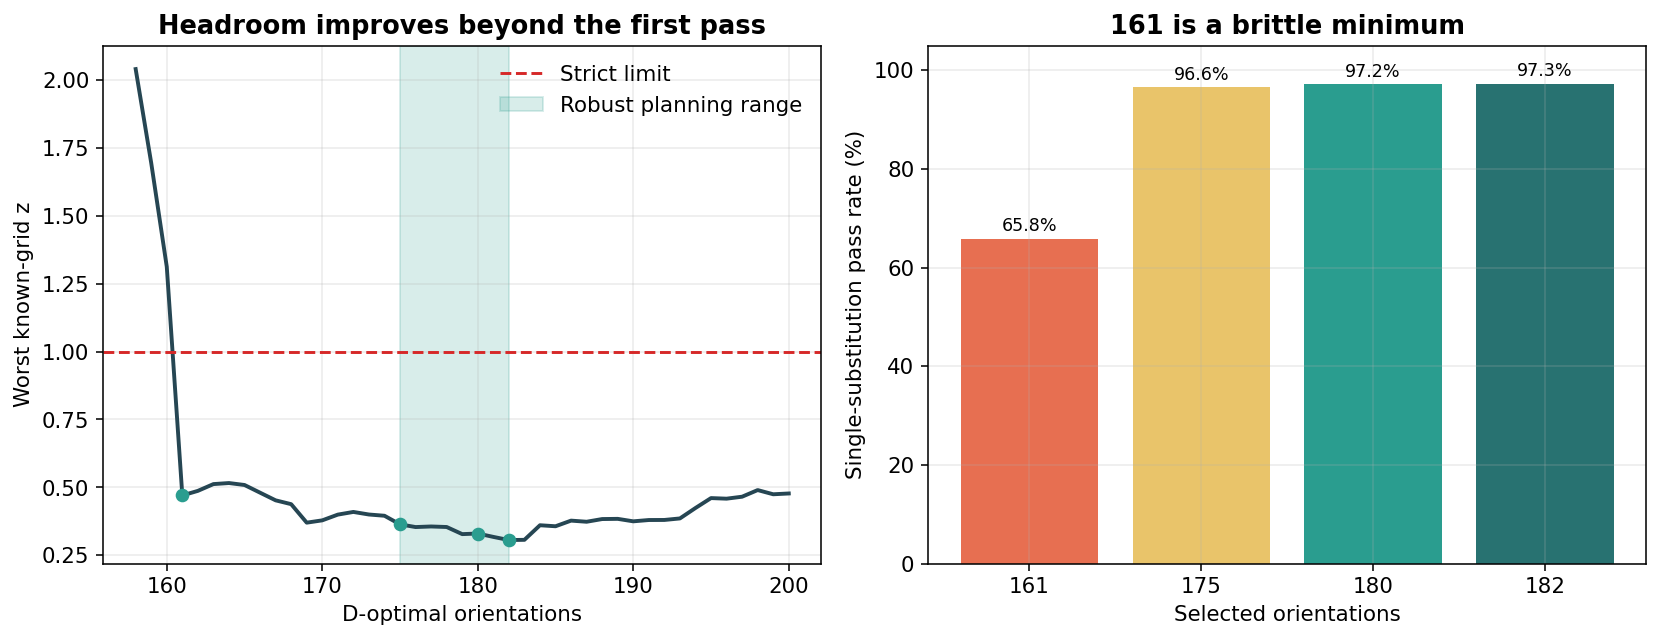

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
margin = d_optimal_margin_summary.sort_values("Training points")
axes[0].plot(margin["Training points"], margin["Worst normalized error"],
             color="#264653", linewidth=2)
axes[0].axhline(1.0, color="#d62828", linestyle="--", label="Strict limit")
axes[0].axvspan(175, 182, color="#2a9d8f", alpha=0.18,
                label="Robust planning range")
for count in [161, 175, 180, 182]:
    row = margin.loc[margin["Training points"] == count].iloc[0]
    axes[0].scatter(count, row["Worst normalized error"], color="#2a9d8f", zorder=3)
axes[0].set(xlabel="D-optimal orientations", ylabel="Worst known-grid z",
            title="Headroom improves beyond the first pass")
axes[0].legend(frameon=False)

robust = single_substitution_summary.set_index("Training points").loc[[161,175,180,182]]
axes[1].bar(robust.index.astype(str), robust["Strict pass rate (%)"],
            color=["#e76f51", "#e9c46a", "#2a9d8f", "#287271"])
axes[1].set(xlabel="Selected orientations", ylabel="Single-substitution pass rate (%)",
            title="161 is a brittle minimum", ylim=(0, 105))
for x, value in enumerate(robust["Strict pass rate (%)"]):
    axes[1].text(x, value + 1.5, f"{value:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

robustness_compact = pd.DataFrame({
    "Training points": [161, 175, 180, 182],
}).merge(
    d_optimal_margin_summary[["Training points", "Worst normalized error",
                              "Tolerance safety factor"]],
    on="Training points"
).merge(
    single_substitution_summary[["Training points", "Strict pass rate (%)"]],
    on="Training points"
).merge(
    criterion_sensitivity_summary[["Training points", "Minimum_safety_factor"]],
    on="Training points"
)
display(robustness_compact.round(3))


**What this shows.** The 161-point prefix passes nominally but only 65.8% of
single substitutions. Counts 175–182 pass roughly 96.6–97.3%, and label-free
reoptimization recovers all 16 examined failures. The 180-point design has a
nominal safety factor of about 3.03 and a minimum factor of about 1.51 across
the criterion sweep.

**What it does not show.** It does not validate a 180-point total electronic-
structure budget. The candidate grid influenced both design development and
evaluation.

**Supported conclusion.** Use 175–182 as a prospective pilot range; 180 is a
convenient planning value, while all 500 existing values remain appropriate for
the completed surface.


<a id="diagnostics"></a>

## 9. Off-grid angular and radial diagnostics

### Off-grid angular question

Could the 180-point and 500-point fits agree on the known grid yet develop very
different structures between sampled orientations?

Two independent 4096-point Sobol measures probe new angular coordinates. We
compare energies, finite-difference angular gradients, threshold crossings, and
multistart local minima. Because neither model is ab initio truth, this is a
model–model stress test.


In [17]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — all-radius transfer and coefficient stability

# --- v2 source cell 140 ---
ALL_R_VALUES = (
    df_all["R"]
    .drop_duplicates()
    .sort_values()
    .to_numpy()
)

all_radial_truth_matrix = np.column_stack(
    [
        (
            df_all[np.isclose(df_all["R"], float(R))]
            .set_index("orientation_id")["V"]
            .reindex(range(EXPECTED_POINTS_PER_R))
            .to_numpy()
        )
        for R in ALL_R_VALUES
    ]
)

print("=== Complete radial-grid audit ===")
print(f"Radial slices: {len(ALL_R_VALUES)}")
print(
    f"R range: {ALL_R_VALUES.min():.1f} "
    f"to {ALL_R_VALUES.max():.1f} Bohr"
)
print(
    "Energy-matrix shape:",
    all_radial_truth_matrix.shape,
)

assert len(ALL_R_VALUES) == 30
assert all_radial_truth_matrix.shape == (500, 30)
assert np.isfinite(all_radial_truth_matrix).all()

# --- v2 source cell 141 ---
FULL_RADIAL_TEST_COUNTS = [
    161,
    175,
    180,
    182,
]

full_radial_transfer_rows = []

for training_N in FULL_RADIAL_TEST_COUNTS:
    selected_ids = (
        global_d_optimal_order[:training_N]
    )

    metrics = (
        evaluate_fixed_subset_across_short_range(
            selected_ids=selected_ids,
            design_matrix=M_orientation,
            truth_matrix=all_radial_truth_matrix,
            radial_values=ALL_R_VALUES,
            rcond=LSTSQ_RCOND,
        )
    )

    full_radial_transfer_rows.append({
        "Training points": training_N,
        "Total ab initio energies": (
            training_N * len(ALL_R_VALUES)
        ),
        "Reduction from 15000 (%)": (
            100.0
            * (
                1.0
                - (
                    training_N
                    * len(ALL_R_VALUES)
                    / len(df_all)
                )
            )
        ),
        **metrics,
    })

full_radial_transfer_summary = pd.DataFrame(
    full_radial_transfer_rows
)

# --- v2 source cell 144 ---
def fit_radial_coefficient_matrix(
    selected_ids,
    truth_matrix=all_radial_truth_matrix,
    design_matrix=M_orientation,
    rcond=LSTSQ_RCOND,
):
    selected_ids = np.asarray(
        selected_ids,
        dtype=int,
    )

    coefficients, _, rank, singular_values = (
        np.linalg.lstsq(
            design_matrix[selected_ids],
            truth_matrix[selected_ids, :],
            rcond=rcond,
        )
    )

    condition_number = (
        singular_values[0]
        / singular_values[-1]
        if singular_values[-1] > 0.0
        else np.inf
    )

    return coefficients, rank, condition_number

# --- v2 source cell 145 ---
full_radial_coefficients, full_radial_rank, full_radial_condition = (
    fit_radial_coefficient_matrix(
        selected_ids=np.arange(
            EXPECTED_POINTS_PER_R
        )
    )
)

full_radial_projection = (
    M_orientation
    @ full_radial_coefficients
)

print("=== Full-grid radial coefficient audit ===")
print(f"Coefficient shape: {full_radial_coefficients.shape}")
print(f"Retained rank: {full_radial_rank}")
print(f"Condition number: {full_radial_condition:.3e}")

# --- v2 source cell 146 ---
COEFFICIENT_STABILITY_COUNTS = [
    161,
    175,
    180,
    182,
]

coefficient_stability_rows = []
coefficient_stability_by_R_rows = []
candidate_coefficient_matrices = {}

full_first_derivative = np.gradient(
    full_radial_coefficients,
    ALL_R_VALUES,
    axis=1,
)

full_second_derivative = np.gradient(
    full_first_derivative,
    ALL_R_VALUES,
    axis=1,
)

for training_N in COEFFICIENT_STABILITY_COUNTS:
    selected_ids = (
        global_d_optimal_order[:training_N]
    )

    (
        candidate_coefficients,
        retained_rank,
        condition_number,
    ) = fit_radial_coefficient_matrix(
        selected_ids
    )

    candidate_coefficient_matrices[
        training_N
    ] = candidate_coefficients

    coefficient_difference = (
        candidate_coefficients
        - full_radial_coefficients
    )

    candidate_projection = (
        M_orientation
        @ candidate_coefficients
    )

    projection_difference = (
        candidate_projection
        - full_radial_projection
    )

    candidate_first_derivative = np.gradient(
        candidate_coefficients,
        ALL_R_VALUES,
        axis=1,
    )

    candidate_second_derivative = np.gradient(
        candidate_first_derivative,
        ALL_R_VALUES,
        axis=1,
    )

    first_derivative_difference = (
        candidate_first_derivative
        - full_first_derivative
    )

    second_derivative_difference = (
        candidate_second_derivative
        - full_second_derivative
    )

    coefficient_relative_errors = []
    coefficient_cosine_similarities = []
    projection_RMSE_by_R = []
    projection_maximum_by_R = []

    for radial_index, target_R in enumerate(
        ALL_R_VALUES
    ):
        full_vector = full_radial_coefficients[
            :,
            radial_index,
        ]

        candidate_vector = candidate_coefficients[
            :,
            radial_index,
        ]

        difference_vector = coefficient_difference[
            :,
            radial_index,
        ]

        full_norm = np.linalg.norm(
            full_vector
        )

        candidate_norm = np.linalg.norm(
            candidate_vector
        )

        relative_error = (
            np.linalg.norm(difference_vector)
            / full_norm
            if full_norm > 0.0
            else np.nan
        )

        cosine_similarity = (
            np.dot(
                candidate_vector,
                full_vector,
            )
            / (
                candidate_norm
                * full_norm
            )
            if (
                candidate_norm > 0.0
                and full_norm > 0.0
            )
            else np.nan
        )

        radial_projection_difference = (
            projection_difference[
                :,
                radial_index,
            ]
        )

        projection_RMSE = np.sqrt(
            np.mean(
                radial_projection_difference**2
            )
        )

        projection_maximum = np.max(
            np.abs(
                radial_projection_difference
            )
        )

        coefficient_relative_errors.append(
            relative_error
        )
        coefficient_cosine_similarities.append(
            cosine_similarity
        )
        projection_RMSE_by_R.append(
            projection_RMSE
        )
        projection_maximum_by_R.append(
            projection_maximum
        )

        coefficient_stability_by_R_rows.append({
            "Training points": training_N,
            "R": float(target_R),
            "Relative coefficient error": (
                relative_error
            ),
            "Coefficient cosine similarity": (
                cosine_similarity
            ),
            "Projection-deviation RMSE": (
                projection_RMSE
            ),
            "Maximum projection deviation": (
                projection_maximum
            ),
        })

    projection_RMSE_by_R = np.asarray(
        projection_RMSE_by_R
    )

    maximum_projection_index = int(
        np.argmax(projection_RMSE_by_R)
    )

    coefficient_stability_rows.append({
        "Training points": training_N,
        "Retained rank": retained_rank,
        "Condition number": condition_number,
        "Global relative coefficient error": (
            np.linalg.norm(
                coefficient_difference
            )
            / np.linalg.norm(
                full_radial_coefficients
            )
        ),
        "Median per-R coefficient error": (
            np.nanmedian(
                coefficient_relative_errors
            )
        ),
        "Maximum per-R coefficient error": (
            np.nanmax(
                coefficient_relative_errors
            )
        ),
        "Minimum cosine similarity": (
            np.nanmin(
                coefficient_cosine_similarities
            )
        ),
        "Maximum projection-deviation RMSE": (
            projection_RMSE_by_R[
                maximum_projection_index
            ]
        ),
        "Projection-deviation limiting R": (
            ALL_R_VALUES[
                maximum_projection_index
            ]
        ),
        "Maximum pointwise projection deviation": (
            np.max(
                projection_maximum_by_R
            )
        ),
        "Relative first-derivative error": (
            np.linalg.norm(
                first_derivative_difference
            )
            / np.linalg.norm(
                full_first_derivative
            )
        ),
        "Relative second-derivative error": (
            np.linalg.norm(
                second_derivative_difference
            )
            / np.linalg.norm(
                full_second_derivative
            )
        ),
    })

coefficient_stability_summary = pd.DataFrame(
    coefficient_stability_rows
)

coefficient_stability_by_R = pd.DataFrame(
    coefficient_stability_by_R_rows
)


In [18]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — off-grid angular disagreement and local-minimum stress test

# --- v2 source cell 149 ---
from scipy.optimize import minimize
from scipy.stats import qmc

OFFGRID_SAMPLE_SIZE = 4096
OFFGRID_SEED = 20260715
OFFGRID_MARGIN = 1.0e-3
OFFGRID_DERIVATIVE_STEP = 1.0e-4
OFFGRID_ANCHOR_RADII = [4.4, 4.8, 5.0, 5.8, 6.6]


def design_matrix_from_radians(theta1, theta2, phi):
    matrix = np.empty((len(theta1), len(basis_indices)))
    for column, (l1, l2, l) in enumerate(basis_indices):
        matrix[:, column] = evaluate_A_basis(
            l1, l2, l, theta1, theta2, phi
        )
    return matrix


def make_offgrid_angles(mode, n_points=OFFGRID_SAMPLE_SIZE):
    m = int(np.log2(n_points))
    if 2**m != n_points:
        raise ValueError("Sobol sample size must be a power of two.")
    seed_offset = 0 if mode == "coordinate-uniform" else 1
    unit = qmc.Sobol(
        d=3, scramble=True, seed=OFFGRID_SEED + seed_offset
    ).random_base2(m)
    unit = OFFGRID_MARGIN + (1.0 - 2.0 * OFFGRID_MARGIN) * unit

    if mode == "coordinate-uniform":
        theta1 = np.pi * unit[:, 0]
        theta2 = np.pi * unit[:, 1]
    elif mode == "solid-angle":
        theta1 = np.arccos(1.0 - 2.0 * unit[:, 0])
        theta2 = np.arccos(1.0 - 2.0 * unit[:, 1])
    else:
        raise ValueError(f"Unknown mode: {mode}")
    phi = np.pi * unit[:, 2]
    return theta1, theta2, phi


def offgrid_design_and_derivatives(mode):
    theta1, theta2, phi = make_offgrid_angles(mode)
    base = design_matrix_from_radians(theta1, theta2, phi)
    derivatives = []
    coordinates = [theta1, theta2, phi]

    for coordinate_index in range(3):
        plus = [values.copy() for values in coordinates]
        minus = [values.copy() for values in coordinates]
        plus[coordinate_index] += OFFGRID_DERIVATIVE_STEP
        minus[coordinate_index] -= OFFGRID_DERIVATIVE_STEP
        M_plus = design_matrix_from_radians(*plus)
        M_minus = design_matrix_from_radians(*minus)
        derivatives.append(
            (M_plus - M_minus) / (2.0 * OFFGRID_DERIVATIVE_STEP)
        )

    return (theta1, theta2, phi), base, derivatives


offgrid_summary_rows = []
offgrid_candidate_rows = []
offgrid_cache = {}

for mode in ["coordinate-uniform", "solid-angle"]:
    coordinates, M_offgrid, derivative_matrices = (
        offgrid_design_and_derivatives(mode)
    )
    offgrid_cache[mode] = (coordinates, M_offgrid, derivative_matrices)
    theta1, theta2, phi = coordinates

    for target_R in OFFGRID_ANCHOR_RADII:
        radial_index = int(np.where(np.isclose(ALL_R_VALUES, target_R))[0][0])
        coefficients_500 = full_radial_coefficients[:, radial_index]
        coefficients_180 = candidate_coefficient_matrices[180][:, radial_index]

        V_500 = M_offgrid @ coefficients_500
        V_180 = M_offgrid @ coefficients_180
        disagreement = np.abs(V_180 - V_500)
        normalized_disagreement = disagreement / hybrid_tolerance(V_500)

        gradient_500 = np.column_stack([
            derivative @ coefficients_500
            for derivative in derivative_matrices
        ])
        gradient_180 = np.column_stack([
            derivative @ coefficients_180
            for derivative in derivative_matrices
        ])
        gradient_disagreement = np.linalg.norm(
            gradient_180 - gradient_500, axis=1
        )

        severe_opening = (V_500 >= 5000.0) & (V_180 < 3000.0)
        low_opening = (V_500 >= 1000.0) & (V_180 < 1000.0)

        offgrid_summary_rows.append({
            "Sampling measure": mode,
            "R": target_R,
            "Points": len(V_500),
            "P95 absolute disagreement": np.percentile(disagreement, 95),
            "Maximum absolute disagreement": disagreement.max(),
            "P95 normalized disagreement": np.percentile(
                normalized_disagreement, 95
            ),
            "Maximum normalized disagreement": normalized_disagreement.max(),
            "P95 gradient disagreement (cm^-1 rad^-1)": np.percentile(
                gradient_disagreement, 95
            ),
            "Maximum gradient disagreement (cm^-1 rad^-1)": (
                gradient_disagreement.max()
            ),
            "Reference-high / candidate-below-3000": int(severe_opening.sum()),
            "Reference-above-1000 / candidate-below-1000": int(low_opening.sum()),
        })

        candidate_reasons = {}

        def add_candidate_reason(indices, reason):
            for candidate_index in np.asarray(indices, dtype=int):
                candidate_reasons.setdefault(candidate_index, set()).add(reason)

        add_candidate_reason(
            np.flatnonzero(severe_opening),
            "reference-high / candidate-below-3000",
        )
        add_candidate_reason(
            np.flatnonzero(low_opening),
            "reference-above-1000 / candidate-below-1000",
        )
        add_candidate_reason(
            np.argsort(normalized_disagreement)[-5:],
            "largest normalized disagreement",
        )
        add_candidate_reason(
            np.argsort(disagreement)[-5:],
            "largest absolute disagreement",
        )
        add_candidate_reason(
            np.argsort(gradient_disagreement)[-5:],
            "largest gradient disagreement",
        )

        for index, reasons in candidate_reasons.items():
            offgrid_candidate_rows.append({
                "Sampling measure": mode,
                "R": target_R,
                "Theta_1": np.degrees(theta1[index]),
                "Theta_2": np.degrees(theta2[index]),
                "Phi": np.degrees(phi[index]),
                "V_500_reference": V_500[index],
                "V_180_candidate": V_180[index],
                "Absolute disagreement": disagreement[index],
                "Normalized disagreement": normalized_disagreement[index],
                "Gradient disagreement (cm^-1 rad^-1)": (
                    gradient_disagreement[index]
                ),
                "Reference-high / candidate-below-3000": bool(
                    severe_opening[index]
                ),
                "Reference-above-1000 / candidate-below-1000": bool(
                    low_opening[index]
                ),
                "Selection reason": "; ".join(sorted(reasons)),
            })

offgrid_disagreement_summary = pd.DataFrame(offgrid_summary_rows)
offgrid_validation_candidates = pd.DataFrame(offgrid_candidate_rows)

print("=== Off-grid 180-versus-500 disagreement summary ===")
print(
    offgrid_disagreement_summary.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)

offgrid_priority_parts = []
threshold_crossings = offgrid_validation_candidates[
    offgrid_validation_candidates[
        "Reference-high / candidate-below-3000"
    ]
    | offgrid_validation_candidates[
        "Reference-above-1000 / candidate-below-1000"
    ]
].copy()
threshold_crossings.insert(0, "Priority category", "threshold crossing")
offgrid_priority_parts.append(threshold_crossings)

for priority_category, metric in [
    ("normalized disagreement", "Normalized disagreement"),
    ("absolute disagreement", "Absolute disagreement"),
    (
        "gradient disagreement",
        "Gradient disagreement (cm^-1 rad^-1)",
    ),
]:
    priority_part = (
        offgrid_validation_candidates
        .sort_values(metric, ascending=False)
        .head(5)
        .copy()
    )
    priority_part.insert(0, "Priority category", priority_category)
    offgrid_priority_parts.append(priority_part)

offgrid_priority_candidates = pd.concat(
    offgrid_priority_parts, ignore_index=True
)

print("\n=== Priority off-grid independent-validation candidates ===")
print(
    offgrid_priority_candidates.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)

# --- v2 source cell 150 ---
def evaluate_single_orientation(coefficients, angles_rad):
    theta1, theta2, phi = np.asarray(angles_rad, dtype=float)
    matrix = design_matrix_from_radians(
        np.array([theta1]),
        np.array([theta2]),
        np.array([phi]),
    )
    return float(matrix[0] @ coefficients)


local_minimum_rows = []
bounds = [(0.0, np.pi), (0.0, np.pi), (0.0, np.pi)]

coordinate_mode = "coordinate-uniform"
coordinates, M_offgrid, _ = offgrid_cache[coordinate_mode]

for target_R in [4.4, 4.8, 5.0]:
    radial_index = int(np.where(np.isclose(ALL_R_VALUES, target_R))[0][0])
    coefficients_500 = full_radial_coefficients[:, radial_index]
    coefficients_180 = candidate_coefficient_matrices[180][:, radial_index]
    V_500 = M_offgrid @ coefficients_500
    V_180 = M_offgrid @ coefficients_180
    normalized_disagreement = np.abs(V_180 - V_500) / hybrid_tolerance(V_500)

    start_indices = np.unique(np.concatenate([
        np.argsort(V_180)[:8],
        np.argsort(normalized_disagreement)[-8:],
    ]))

    seen = set()
    for start_index in start_indices:
        start = np.array([
            coordinates[0][start_index],
            coordinates[1][start_index],
            coordinates[2][start_index],
        ])
        result = minimize(
            lambda angles: evaluate_single_orientation(
                coefficients_180, angles
            ),
            x0=start,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 200, "ftol": 1e-10},
        )
        key = tuple(np.round(result.x, 4))
        if key in seen:
            continue
        seen.add(key)

        V180_min = evaluate_single_orientation(coefficients_180, result.x)
        V500_at_min = evaluate_single_orientation(coefficients_500, result.x)
        local_minimum_rows.append({
            "R": target_R,
            "Theta_1": np.degrees(result.x[0]),
            "Theta_2": np.degrees(result.x[1]),
            "Phi": np.degrees(result.x[2]),
            "V_180_candidate": V180_min,
            "V_500_reference": V500_at_min,
            "Candidate minus reference": V180_min - V500_at_min,
            "Optimizer success": bool(result.success),
        })

offgrid_local_minima = (
    pd.DataFrame(local_minimum_rows)
    .sort_values(["R", "V_180_candidate"])
    .reset_index(drop=True)
)

print("=== Multi-start off-grid local minima of the 180-point surface ===")
print(
    offgrid_local_minima.groupby("R", group_keys=False)
    .head(10)
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)


,Sampling measure,R,Reference-high / candidate-below-3000,Reference-above-1000 / candidate-below-1000
5,solid-angle,4.4,0,1


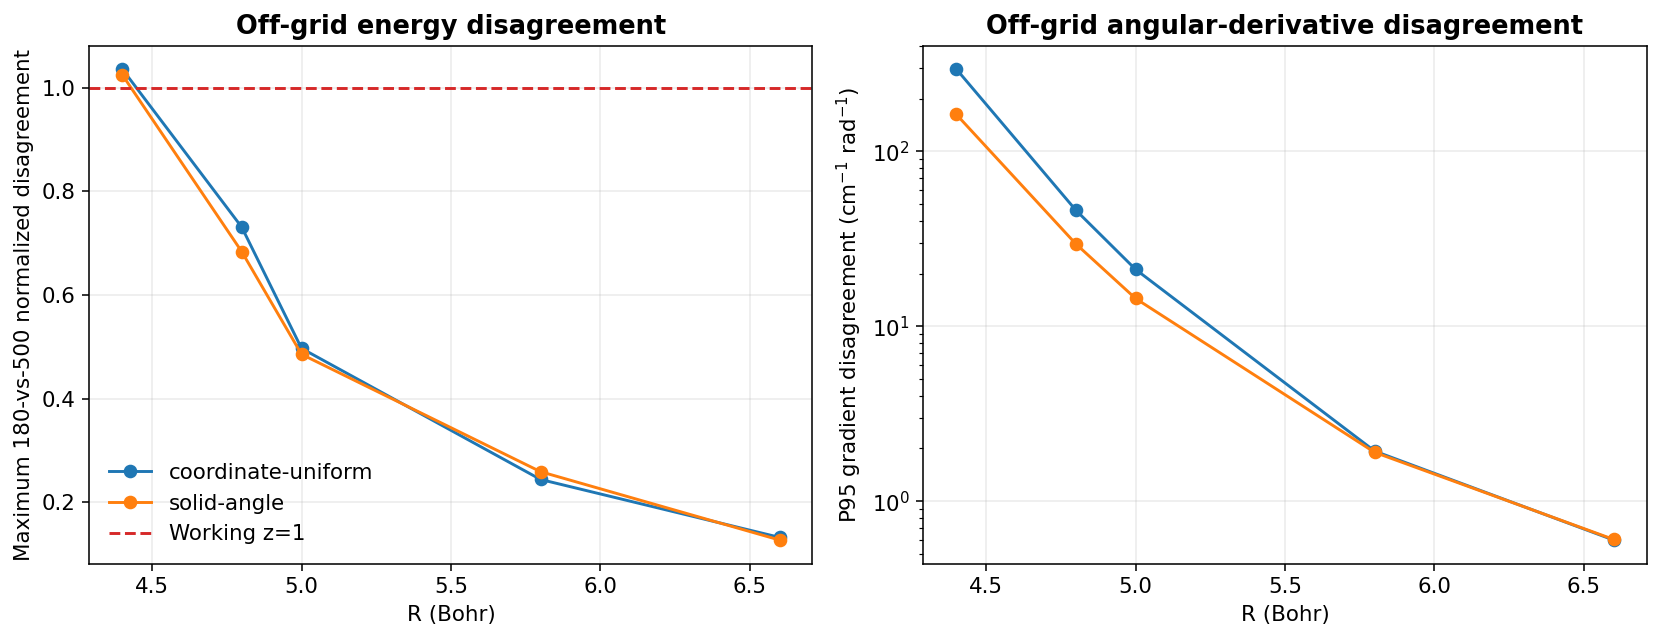

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for measure, group in offgrid_disagreement_summary.groupby("Sampling measure"):
    group = group.sort_values("R")
    axes[0].plot(group["R"], group["Maximum normalized disagreement"],
                 marker="o", label=measure)
    axes[1].plot(group["R"], group["P95 gradient disagreement (cm^-1 rad^-1)"],
                 marker="o", label=measure)
axes[0].axhline(1.0, color="#d62828", linestyle="--", label="Working z=1")
axes[0].set(xlabel="R (Bohr)", ylabel="Maximum 180-vs-500 normalized disagreement",
            title="Off-grid energy disagreement")
axes[1].set_yscale("log")
axes[1].set(xlabel="R (Bohr)", ylabel="P95 gradient disagreement (cm$^{-1}$ rad$^{-1}$)",
            title="Off-grid angular-derivative disagreement")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

offgrid_openings = offgrid_disagreement_summary[[
    "Sampling measure", "R", "Reference-high / candidate-below-3000",
    "Reference-above-1000 / candidate-below-1000",
]]
display(offgrid_openings[
    (offgrid_openings.iloc[:, 2] > 0) | (offgrid_openings.iloc[:, 3] > 0)
])


**What this shows.** Disagreement is largest at (R=4.4). No point with the
500-point reference above 5000 is opened below 3000 by the 180-point model.
One solid-angle point narrowly crosses the 1000 boundary, which is retained in
the validation stress set rather than described as harmless.

**What it does not show.** Agreement with the 500-point fit cannot establish
agreement with the true off-grid potential.

### Radial question

Can coefficient curves predict an omitted known radial slice without inventing
a production interpolation? We use a transparent leave-one-(R)-out cubic
spline only as a diagnostic and apply it identically to the 180- and 500-point
coefficient matrices.


In [20]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — leave-one-R-out radial diagnostic

# --- v2 source cell 153 ---
from scipy.interpolate import CubicSpline

RADIAL_HOLDOUT_VALUES = [
    float(R)
    for R in SHORT_RANGE_R_VALUES
    if R > SHORT_RANGE_R_VALUES.min() and R < SHORT_RANGE_R_VALUES.max()
]

radial_holdout_rows = []
radial_coefficient_sources = {
    "500-point angular fit": full_radial_coefficients,
    "180-point angular fit": candidate_coefficient_matrices[180],
}

for design_name, coefficient_matrix in radial_coefficient_sources.items():
    for heldout_R in RADIAL_HOLDOUT_VALUES:
        heldout_index = int(
            np.where(np.isclose(ALL_R_VALUES, heldout_R))[0][0]
        )
        keep_mask = np.ones(len(ALL_R_VALUES), dtype=bool)
        keep_mask[heldout_index] = False

        spline = CubicSpline(
            ALL_R_VALUES[keep_mask],
            coefficient_matrix[:, keep_mask],
            axis=1,
        )
        heldout_coefficients = spline(heldout_R)
        prediction = M_orientation @ heldout_coefficients
        truth = all_radial_truth_matrix[:, heldout_index]

        relevant_score = score_relevant_predictions(truth, prediction)
        for _, score_row in relevant_score.iterrows():
            radial_holdout_rows.append({
                "Angular design": design_name,
                "Held-out R": heldout_R,
                **score_row.to_dict(),
            })

radial_holdout_results = pd.DataFrame(radial_holdout_rows)
radial_holdout_summary = (
    radial_holdout_results
    .groupby(["Angular design", "Held-out R"], sort=True)
    .agg(
        Worst_band_MAE=("MAE (cm^-1)", "max"),
        Worst_band_P95_normalized_error=("P95 normalized error", "max"),
        Worst_individual_normalized_error=("Max normalized error", "max"),
        Minimum_band_within_tolerance_percent=(
            "Within tolerance (%)", "min"
        ),
    )
    .reset_index()
)

print("=== Leave-one-R-out cubic-spline diagnostic ===")
print(
    radial_holdout_summary.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)


,Angular design,Held-out R,Worst_band_MAE,Worst_band_P95_normalized_error,Worst_individual_normalized_error,Minimum_band_within_tolerance_percent
1,180-point angular fit,4.8,3.2262,0.7242,1.4226,96.2963
11,500-point angular fit,4.8,3.2805,0.7677,1.2874,96.2963


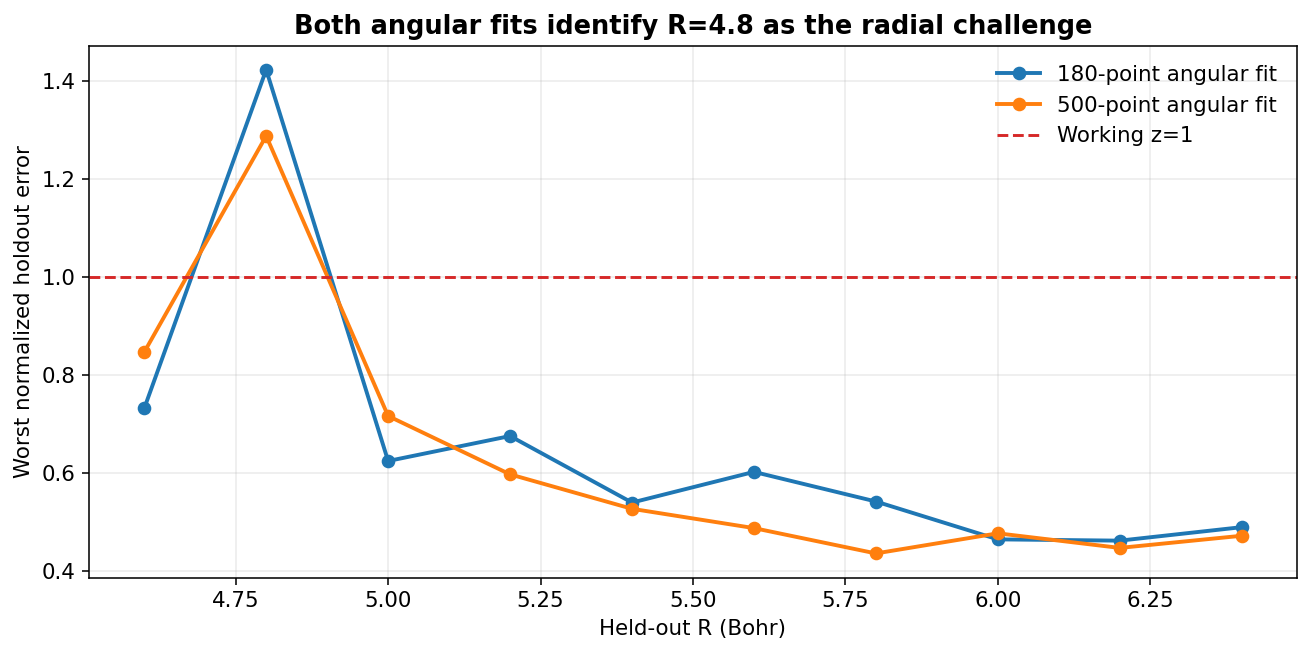

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for design, group in radial_holdout_summary.groupby("Angular design", sort=False):
    group = group.sort_values("Held-out R")
    ax.plot(group["Held-out R"], group["Worst_individual_normalized_error"],
            marker="o", linewidth=2, label=design)
ax.axhline(1.0, color="#d62828", linestyle="--", label="Working z=1")
ax.set(xlabel="Held-out R (Bohr)", ylabel="Worst normalized holdout error",
       title="Both angular fits identify R=4.8 as the radial challenge")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(radial_holdout_summary.loc[
    np.isclose(radial_holdout_summary["Held-out R"], 4.8)
].round(4))


**What this shows.** Both angular fits fail the strict pointwise criterion at
the same (R=4.8) holdout, with maxima near 1.42 for the 180-point fit and 1.29
for the 500-point fit. The shared failure points to radial interpolation rather
than angular compression alone.

**What it does not show.** The cubic spline is not being proposed as the
production radial representation.

**Supported conclusion.** New validation should emphasize the shortest radii
and include a small midpoint challenge around (R=4.8).


In [22]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — solver and synthetic-noise appendix analyses

# --- v2 source cell 156 ---
def score_prediction_matrix_over_radial_grid(
    prediction_matrix,
    truth_matrix=all_radial_truth_matrix,
    radial_values=ALL_R_VALUES,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
    physical_ceiling=PHYSICAL_ENERGY_CEILING,
    guardrail_warning=GUARDRAIL_WARNING_THRESHOLD,
):
    """Return strict finite-grid and guardrail diagnostics."""
    worst_normalized_error = -np.inf
    limiting_R = np.nan
    minimum_guardrail_prediction = np.inf
    any_guardrail_below_warning = False

    for radial_index, target_R in enumerate(radial_values):
        truth = truth_matrix[:, radial_index]
        prediction = prediction_matrix[:, radial_index]
        relevant_mask = truth < physical_ceiling
        normalized_error = np.abs(prediction - truth) / hybrid_tolerance(
            truth,
            absolute_floor=absolute_floor,
            relative_fraction=relative_fraction,
        )

        if np.any(relevant_mask):
            radial_maximum = normalized_error[relevant_mask].max()
            if radial_maximum > worst_normalized_error:
                worst_normalized_error = radial_maximum
                limiting_R = float(target_R)

        guardrail_mask = truth >= physical_ceiling
        if np.any(guardrail_mask):
            radial_guardrail_predictions = prediction[guardrail_mask]
            minimum_guardrail_prediction = min(
                minimum_guardrail_prediction,
                radial_guardrail_predictions.min(),
            )
            if np.any(radial_guardrail_predictions < guardrail_warning):
                any_guardrail_below_warning = True

    if not np.isfinite(minimum_guardrail_prediction):
        minimum_guardrail_prediction = np.nan

    return {
        "Worst normalized error": worst_normalized_error,
        "Tolerance safety factor": (
            1.0 / worst_normalized_error
            if worst_normalized_error > 0.0
            else np.inf
        ),
        "Limiting R": limiting_R,
        "Minimum guardrail prediction": minimum_guardrail_prediction,
        "Any guardrail below 3000": any_guardrail_below_warning,
        "Strict pass": (
            worst_normalized_error <= 1.0
            and not any_guardrail_below_warning
        ),
    }

# --- v2 source cell 157 ---
RECOMMENDED_TRAINING_COUNT = 180

recommended_selected_ids = (
    global_d_optimal_order[
        :RECOMMENDED_TRAINING_COUNT
    ]
)

M_recommended = M_orientation[
    recommended_selected_ids
]

Y_recommended = all_radial_truth_matrix[
    recommended_selected_ids,
    :,
]

default_coefficients, _, _, _ = np.linalg.lstsq(
    M_recommended,
    Y_recommended,
    rcond=LSTSQ_RCOND,
)

RCOND_TEST_VALUES = [
    1e-12,
    1e-10,
    1e-8,
    1e-6,
    1e-4,
    1e-3,
    1e-2,
    2e-2,
    3e-2,
    5e-2,
]

rcond_sensitivity_rows = []

for tested_rcond in RCOND_TEST_VALUES:
    (
        tested_coefficients,
        _,
        retained_rank,
        singular_values,
    ) = np.linalg.lstsq(
        M_recommended,
        Y_recommended,
        rcond=tested_rcond,
    )

    tested_prediction = (
        M_orientation
        @ tested_coefficients
    )

    physical_metrics = (
        score_prediction_matrix_over_radial_grid(
            tested_prediction
        )
    )

    rcond_sensitivity_rows.append({
        "rcond": tested_rcond,
        "Retained rank": retained_rank,
        "Retained-subspace condition number": (
            singular_values[0]
            / singular_values[retained_rank - 1]
        ),
        "Relative coefficient change": (
            np.linalg.norm(
                tested_coefficients
                - default_coefficients
            )
            / np.linalg.norm(
                default_coefficients
            )
        ),
        **physical_metrics,
    })

rcond_sensitivity_summary = pd.DataFrame(
    rcond_sensitivity_rows
)

# --- v2 source cell 159 ---
SYNTHETIC_NOISE_LEVELS = [
    0.0,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    1.00,
]

N_SYNTHETIC_NOISE_REPLICATES = 200
SYNTHETIC_NOISE_SEED = 20260714

recommended_pseudoinverse = np.linalg.pinv(
    M_recommended,
    rcond=LSTSQ_RCOND,
)

baseline_recommended_coefficients = (
    recommended_pseudoinverse
    @ Y_recommended
)

rng = np.random.default_rng(
    SYNTHETIC_NOISE_SEED
)

standardized_noise_draws = rng.normal(
    size=(
        N_SYNTHETIC_NOISE_REPLICATES,
        RECOMMENDED_TRAINING_COUNT,
        len(ALL_R_VALUES),
    )
)

synthetic_noise_rows = []

for noise_sigma in SYNTHETIC_NOISE_LEVELS:
    for replicate in range(
        N_SYNTHETIC_NOISE_REPLICATES
    ):
        perturbed_training_energies = (
            Y_recommended
            + noise_sigma
            * standardized_noise_draws[replicate]
        )

        perturbed_coefficients = (
            recommended_pseudoinverse
            @ perturbed_training_energies
        )

        perturbed_prediction = (
            M_orientation
            @ perturbed_coefficients
        )

        physical_metrics = (
            score_prediction_matrix_over_radial_grid(
                perturbed_prediction
            )
        )

        synthetic_noise_rows.append({
            "Noise sigma (cm^-1)": noise_sigma,
            "Replicate": replicate,
            "Relative coefficient perturbation": (
                np.linalg.norm(
                    perturbed_coefficients
                    - baseline_recommended_coefficients
                )
                / np.linalg.norm(
                    baseline_recommended_coefficients
                )
            ),
            **physical_metrics,
        })

    print(
        f"Completed sigma = {noise_sigma:.2f} cm^-1"
    )

synthetic_noise_results = pd.DataFrame(
    synthetic_noise_rows
)

# --- v2 source cell 160 ---
synthetic_noise_summary = (
    synthetic_noise_results
    .groupby(
        "Noise sigma (cm^-1)",
        sort=True,
    )
    .agg(
        strict_pass_rate_percent=(
            "Strict pass",
            lambda values: (
                100.0 * values.mean()
            ),
        ),
        median_worst_normalized_error=(
            "Worst normalized error",
            "median",
        ),
        P95_worst_normalized_error=(
            "Worst normalized error",
            lambda values: np.percentile(
                values,
                95,
            ),
        ),
        maximum_worst_normalized_error=(
            "Worst normalized error",
            "max",
        ),
        median_relative_coefficient_perturbation=(
            "Relative coefficient perturbation",
            "median",
        ),
        P95_relative_coefficient_perturbation=(
            "Relative coefficient perturbation",
            lambda values: np.percentile(
                values,
                95,
            ),
        ),
        minimum_guardrail_prediction=(
            "Minimum guardrail prediction",
            "min",
        ),
        guardrail_failure_count=(
            "Any guardrail below 3000",
            "sum",
        ),
    )
    .reset_index()
)


In [23]:
%%capture
# COLLAPSIBLE IMPLEMENTATION — candidate-design comparison

# --- v2 source cell 163 ---
FINAL_COMPARISON_COUNTS = [
    161,
    175,
    180,
    182,
]

DESIGN_ROLES = {
    161: "Empirical minimum",
    175: "Robust lower bound",
    180: "Prospective pilot",
    182: "Upper pilot comparator",
}

final_decision_rows = []

for training_N in FINAL_COMPARISON_COUNTS:
    radial_row = (
        full_radial_transfer_summary[
            full_radial_transfer_summary[
                "Training points"
            ] == training_N
        ]
        .iloc[0]
    )

    coefficient_row = (
        coefficient_stability_summary[
            coefficient_stability_summary[
                "Training points"
            ] == training_N
        ]
        .iloc[0]
    )

    substitution_row = (
        single_substitution_summary[
            single_substitution_summary[
                "Training points"
            ] == training_N
        ]
        .iloc[0]
    )

    recovery_rows = (
        reoptimized_recovery_results[
            reoptimized_recovery_results[
                "Training points"
            ] == training_N
        ]
    )

    if len(recovery_rows) > 0:
        failed_substitutions_recovered = (
            100.0
            * recovery_rows[
                "Reoptimized strict pass"
            ].mean()
        )
    else:
        failed_substitutions_recovered = np.nan

    final_decision_rows.append({
        "Training points": training_N,
        "Interpretation": DESIGN_ROLES[
            training_N
        ],
        "Total energies over 30 R": int(
            radial_row[
                "Total ab initio energies"
            ]
        ),
        "Conditional training-count reduction (%)": (
            radial_row[
                "Reduction from 15000 (%)"
            ]
        ),
        "Condition number": (
            radial_row["Condition number"]
        ),
        "Worst normalized error": (
            radial_row[
                "Worst normalized error"
            ]
        ),
        "Tolerance safety factor": (
            radial_row[
                "Tolerance safety factor"
            ]
        ),
        "Maximum per-R coefficient error": (
            coefficient_row[
                "Maximum per-R coefficient error"
            ]
        ),
        "Single-substitution pass rate (%)": (
            substitution_row[
                "Strict pass rate (%)"
            ]
        ),
        "Failed cases recovered after reoptimization (%)": (
            failed_substitutions_recovered
        ),
        "All-radius strict pass": (
            radial_row["Strict pass"]
        ),
    })

final_design_comparison = pd.DataFrame(
    final_decision_rows
)


<a id="request"></a>

## 10. Concrete independent-ab-initio request

### Why new calculations are necessary

Every point-count result so far ultimately refers back to the existing
500-angle grid or to disagreement between fitted models. To validate the
continuous-angle claim, new geometries must be frozen before their electronic-
structure values are known.

The request contains 24 distributional orientations and 24 stress
orientations. Stress points target energy disagreement, angular-derivative
disagreement, wall boundaries, and local extrema. Selection uses geometry and
existing-model diagnostics; it never uses the requested labels.


### Collapsible request-construction helper

Unlike v2 Section 18, this helper receives every late-stage analysis object as
an explicit argument. It does not write files or depend on an incidental output
directory.


In [24]:
REQUEST_SOBOL_SEED = 20260716
PRIMARY_VALIDATION_R_VALUES = np.array([4.4, 4.8, 5.0])
RADIAL_CHALLENGE_R_VALUES = np.array([4.7, 4.9])


def build_validation_request(
    *,
    validation_candidates,
    local_minima,
    offgrid_cache,
    full_coefficients,
    candidate_coefficients_180,
    all_r_values,
    design_matrix_function,
    request_seed=REQUEST_SOBOL_SEED,
    primary_r_values=PRIMARY_VALIDATION_R_VALUES,
    radial_r_values=RADIAL_CHALLENGE_R_VALUES,
    offgrid_margin=OFFGRID_MARGIN,
):
    """Build the frozen request without inspecting any new ab initio labels."""
    def make_request_distributional_angles(mode, n_points=12):
        # Draw 16 Sobol candidates and freeze the first 12. A fresh seed keeps
        # this ordinary validation component separate from Section 14 tuning.
        seed_offset = 0 if mode == "coordinate-uniform" else 1
        unit = qmc.Sobol(
            d=3,
            scramble=True,
            seed=request_seed + seed_offset,
        ).random_base2(4)[:n_points]
        unit = offgrid_margin + (1.0 - 2.0 * offgrid_margin) * unit

        if mode == "coordinate-uniform":
            theta1 = np.pi * unit[:, 0]
            theta2 = np.pi * unit[:, 1]
        elif mode == "solid-angle":
            theta1 = np.arccos(1.0 - 2.0 * unit[:, 0])
            theta2 = np.arccos(1.0 - 2.0 * unit[:, 1])
        else:
            raise ValueError(f"Unknown mode: {mode}")

        phi = np.pi * unit[:, 2]
        return np.column_stack([
            np.degrees(theta1),
            np.degrees(theta2),
            np.degrees(phi),
        ])


    distributional_rows = []
    for mode in ["coordinate-uniform", "solid-angle"]:
        for angles in make_request_distributional_angles(mode):
            distributional_rows.append({
                "Category": f"Distributional: {mode}",
                "Selection detail": (
                    f"Fresh Sobol seed {request_seed}; label-free"
                ),
                "Theta_1": angles[0],
                "Theta_2": angles[1],
                "Phi": angles[2],
            })

    distributional_request = pd.DataFrame(distributional_rows)


    def design_signature(row):
        angles_rad = np.radians([
            row["Theta_1"], row["Theta_2"], row["Phi"]
        ])
        basis_row = design_matrix_function(
            np.array([angles_rad[0]]),
            np.array([angles_rad[1]]),
            np.array([angles_rad[2]]),
        )[0]
        # Coordinate-distinct geometries with the same symmetry-adapted basis
        # row are redundant for both fits and should not both be requested.
        return tuple(np.round(basis_row, 10))


    # Collapse repeated appearances of the same diagnostic orientation across R.
    stress_pool = (
        validation_candidates
        .groupby(
            ["Sampling measure", "Theta_1", "Theta_2", "Phi"],
            as_index=False,
        )
        .agg(
            Source_R=("R", lambda x: ",".join(
                f"{value:.1f}" for value in sorted(set(x))
            )),
            Maximum_absolute_disagreement=("Absolute disagreement", "max"),
            Maximum_normalized_disagreement=("Normalized disagreement", "max"),
            Maximum_gradient_disagreement=(
                "Gradient disagreement (cm^-1 rad^-1)", "max"
            ),
            Any_severe_opening=(
                "Reference-high / candidate-below-3000", "max"
            ),
            Any_1000_crossing=(
                "Reference-above-1000 / candidate-below-1000", "max"
            ),
        )
    )

    used_signatures = {
        design_signature(row)
        for _, row in distributional_request.iterrows()
    }
    if len(used_signatures) != len(distributional_request):
        raise RuntimeError(
            "The ordinary request contains symmetry-equivalent basis rows."
        )
    selected_stress_rows = []


    def add_unique_stress_rows(ordered_pool, count, category, detail):
        added = 0
        for _, row in ordered_pool.iterrows():
            signature = design_signature(row)
            if signature in used_signatures:
                continue
            used_signatures.add(signature)
            selected_stress_rows.append({
                "Category": category,
                "Selection detail": detail(row),
                "Theta_1": row["Theta_1"],
                "Theta_2": row["Theta_2"],
                "Phi": row["Phi"],
            })
            added += 1
            if added == count:
                break
        if added != count:
            raise RuntimeError(
                f"Could select only {added} of {count} rows for {category}."
            )


    add_unique_stress_rows(
        stress_pool.sort_values(
            "Maximum_normalized_disagreement", ascending=False
        ),
        4,
        "Stress: energy disagreement",
        lambda row: (
            "largest normalized 180-vs-500 disagreement; "
            f"source R={row['Source_R']}"
        ),
    )
    add_unique_stress_rows(
        stress_pool.sort_values(
            "Maximum_absolute_disagreement", ascending=False
        ),
        4,
        "Stress: energy disagreement",
        lambda row: (
            "largest absolute 180-vs-500 disagreement; "
            f"source R={row['Source_R']}"
        ),
    )
    add_unique_stress_rows(
        stress_pool.sort_values(
            "Maximum_gradient_disagreement", ascending=False
        ),
        8,
        "Stress: angular derivative",
        lambda row: (
            "largest angular-gradient disagreement; "
            f"source R={row['Source_R']}"
        ),
    )

    # Search all diagnostic Sobol points for threshold crossings and points
    # closest to the 1000, 3000, or 5000 cm^-1 boundaries.
    boundary_rows = []
    extrema_rows = []
    thresholds = np.array([1000.0, 3000.0, 5000.0])

    for mode, (coordinates, M_offgrid, _) in offgrid_cache.items():
        theta1, theta2, phi = coordinates
        angles_degree = np.column_stack([
            np.degrees(theta1),
            np.degrees(theta2),
            np.degrees(phi),
        ])

        for target_R in primary_r_values:
            radial_index = int(
                np.where(np.isclose(all_r_values, target_R))[0][0]
            )
            V500 = M_offgrid @ full_coefficients[:, radial_index]
            V180 = (
                M_offgrid
                @ candidate_coefficients_180[:, radial_index]
            )

            crossing_matrix = (
                (V500[:, None] - thresholds[None, :])
                * (V180[:, None] - thresholds[None, :])
                < 0.0
            )
            any_crossing = crossing_matrix.any(axis=1)
            boundary_distance = np.minimum(
                np.min(np.abs(V500[:, None] - thresholds[None, :]), axis=1),
                np.min(np.abs(V180[:, None] - thresholds[None, :]), axis=1),
            )

            boundary_indices = np.unique(np.concatenate([
                np.flatnonzero(any_crossing),
                np.argsort(boundary_distance)[:20],
            ]))
            for index in boundary_indices:
                boundary_rows.append({
                    "Sampling measure": mode,
                    "Source_R": target_R,
                    "Theta_1": angles_degree[index, 0],
                    "Theta_2": angles_degree[index, 1],
                    "Phi": angles_degree[index, 2],
                    "Any threshold crossing": bool(any_crossing[index]),
                    "Boundary distance": boundary_distance[index],
                })

            low_indices = np.argsort(np.minimum(V500, V180))[:20]
            for index in low_indices:
                extrema_rows.append({
                    "Sampling measure": mode,
                    "Source_R": target_R,
                    "Theta_1": angles_degree[index, 0],
                    "Theta_2": angles_degree[index, 1],
                    "Phi": angles_degree[index, 2],
                    "Minimum fitted energy": min(V500[index], V180[index]),
                })

    boundary_pool = (
        pd.DataFrame(boundary_rows)
        .groupby(
            ["Sampling measure", "Theta_1", "Theta_2", "Phi"],
            as_index=False,
        )
        .agg(
            Source_R=("Source_R", lambda x: ",".join(
                f"{value:.1f}" for value in sorted(set(x))
            )),
            Any_threshold_crossing=("Any threshold crossing", "max"),
            Boundary_distance=("Boundary distance", "min"),
        )
        .sort_values(
            ["Any_threshold_crossing", "Boundary_distance"],
            ascending=[False, True],
        )
    )
    add_unique_stress_rows(
        boundary_pool,
        4,
        "Stress: wall boundary",
        lambda row: (
            f"threshold crossing={bool(row['Any_threshold_crossing'])}; "
            f"nearest fitted-boundary distance={row['Boundary_distance']:.4f}; "
            f"source R={row['Source_R']}"
        ),
    )

    optimized_extrema = local_minima[
        ["R", "Theta_1", "Theta_2", "Phi", "V_180_candidate"]
    ].rename(columns={
        "R": "Source_R",
        "V_180_candidate": "Minimum fitted energy",
    })
    optimized_extrema["Sampling measure"] = "optimized"
    extrema_pool = pd.concat(
        [optimized_extrema, pd.DataFrame(extrema_rows)],
        ignore_index=True,
    ).sort_values("Minimum fitted energy")
    add_unique_stress_rows(
        extrema_pool,
        4,
        "Stress: local extremum",
        lambda row: (
            f"low fitted-energy/local-minimum candidate; source R={row['Source_R']}"
        ),
    )

    stress_request = pd.DataFrame(selected_stress_rows)
    if len(distributional_request) != 24 or len(stress_request) != 24:
        raise RuntimeError("Expected 24 distributional and 24 stress orientations.")

    validation_orientation_request = pd.concat(
        [distributional_request, stress_request],
        ignore_index=True,
    )
    validation_orientation_request.insert(
        0,
        "Validation ID",
        [f"V{index:03d}" for index in range(1, 49)],
    )
    validation_orientation_request[["Theta_1", "Theta_2", "Phi"]] = (
        validation_orientation_request[["Theta_1", "Theta_2", "Phi"]]
        .round(6)
    )

    if validation_orientation_request[
        ["Theta_1", "Theta_2", "Phi"]
    ].duplicated().any():
        raise RuntimeError("The frozen 48-orientation request is not unique.")

    rounded_request_matrix = design_matrix_function(
        np.radians(validation_orientation_request["Theta_1"].to_numpy()),
        np.radians(validation_orientation_request["Theta_2"].to_numpy()),
        np.radians(validation_orientation_request["Phi"].to_numpy()),
    )
    rounded_signatures = {
        tuple(np.round(row, 9)) for row in rounded_request_matrix
    }
    if len(rounded_signatures) != len(validation_orientation_request):
        raise RuntimeError(
            "The rounded request contains symmetry-equivalent basis rows."
        )

    validation_energy_request = validation_orientation_request.merge(
        pd.DataFrame({"R": primary_r_values}),
        how="cross",
    )
    validation_energy_request.insert(0, "Request phase", "Primary off-grid")

    radial_category_counts = {
        "Distributional: coordinate-uniform": 2,
        "Distributional: solid-angle": 2,
        "Stress: energy disagreement": 3,
        "Stress: angular derivative": 3,
        "Stress: wall boundary": 1,
        "Stress: local extremum": 1,
    }
    radial_orientation_parts = [
        validation_orientation_request[
            validation_orientation_request["Category"] == category
        ].head(count)
        for category, count in radial_category_counts.items()
    ]
    radial_orientation_request = pd.concat(
        radial_orientation_parts, ignore_index=True
    )
    if len(radial_orientation_request) != 12:
        raise RuntimeError("Expected 12 radial-challenge orientations.")

    radial_energy_request = radial_orientation_request.merge(
        pd.DataFrame({"R": radial_r_values}),
        how="cross",
    )
    radial_energy_request.insert(0, "Request phase", "Optional radial midpoint")

    complete_energy_request = pd.concat(
        [validation_energy_request, radial_energy_request],
        ignore_index=True,
    )

    return (
        validation_orientation_request,
        validation_energy_request,
        radial_energy_request,
        complete_energy_request,
    )


In [25]:
(
    validation_orientation_request,
    validation_energy_request,
    radial_energy_request,
    complete_energy_request,
) = build_validation_request(
    validation_candidates=offgrid_validation_candidates,
    local_minima=offgrid_local_minima,
    offgrid_cache=offgrid_cache,
    full_coefficients=full_radial_coefficients,
    candidate_coefficients_180=candidate_coefficient_matrices[180],
    all_r_values=ALL_R_VALUES,
    design_matrix_function=design_matrix_from_radians,
)


In [26]:
expected_categories = {
    "Distributional: coordinate-uniform": 12,
    "Distributional: solid-angle": 12,
    "Stress: energy disagreement": 8,
    "Stress: angular derivative": 8,
    "Stress: wall boundary": 4,
    "Stress: local extremum": 4,
}
assert len(validation_orientation_request) == 48
assert validation_orientation_request["Validation ID"].is_unique
assert not validation_orientation_request[["Theta_1", "Theta_2", "Phi"]].duplicated().any()
assert validation_orientation_request["Category"].value_counts().to_dict() == expected_categories
assert len(validation_energy_request) == 144
assert len(radial_energy_request) == 24
assert len(complete_energy_request) == 168
assert not complete_energy_request[["R", "Theta_1", "Theta_2", "Phi"]].duplicated().any()

request_audit = pd.DataFrame({
    "Request": ["Frozen orientations", "Primary independent energies",
                "Optional radial energies", "Complete request"],
    "Count": [48, 144, 24, 168],
    "R values": ["new angles", "4.4, 4.8, 5.0", "4.7, 4.9", "4.4–5.0 focus"],
})
display(request_audit)
display(validation_orientation_request["Category"].value_counts().rename("Orientations"))


,Request,Count,R values
0,Frozen orientations,48,new angles
1,Primary independent energies,144,"4.4, 4.8, 5.0"
2,Optional radial energies,24,"4.7, 4.9"
3,Complete request,168,4.4–5.0 focus


Category
Distributional: coordinate-uniform    12
Distributional: solid-angle           12
Stress: energy disagreement            8
Stress: angular derivative             8
Stress: wall boundary                  4
Stress: local extremum                 4
Name: Orientations, dtype: int64

### Export and readback verification

The four files are written to the project-root-derived `meeting_outputs_v3`
directory, reloaded, and compared with the in-memory tables. A successful cell
therefore verifies both construction and serialization.


In [27]:
MEETING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
request_files = {
    "orientations_48": MEETING_OUTPUT_DIR / "co2_h2_validation_orientations_v3.csv",
    "primary_144": MEETING_OUTPUT_DIR / "co2_h2_primary_validation_energies_v3.csv",
    "optional_radial_24": MEETING_OUTPUT_DIR / "co2_h2_optional_radial_energies_v3.csv",
    "complete_168": MEETING_OUTPUT_DIR / "co2_h2_complete_ab_initio_request_v3.csv",
}
request_tables = {
    "orientations_48": validation_orientation_request,
    "primary_144": validation_energy_request,
    "optional_radial_24": radial_energy_request,
    "complete_168": complete_energy_request,
}
manifest_rows = []
for key, table in request_tables.items():
    path = request_files[key]
    table.to_csv(path, index=False)
    loaded = pd.read_csv(path)
    pd.testing.assert_frame_equal(
        table.reset_index(drop=True), loaded.reset_index(drop=True),
        check_dtype=False, check_exact=False, rtol=1e-12, atol=1e-12,
    )
    manifest_rows.append({"Artifact": key, "Rows": len(loaded), "Path": str(path)})
request_file_manifest = pd.DataFrame(manifest_rows)
display(request_file_manifest)


,Artifact,Rows,Path
0,orientations_48,48,/workspace/scratch/25391e901cda/meeting_output...
1,primary_144,144,/workspace/scratch/25391e901cda/meeting_output...
2,optional_radial_24,24,/workspace/scratch/25391e901cda/meeting_output...
3,complete_168,168,/workspace/scratch/25391e901cda/meeting_output...


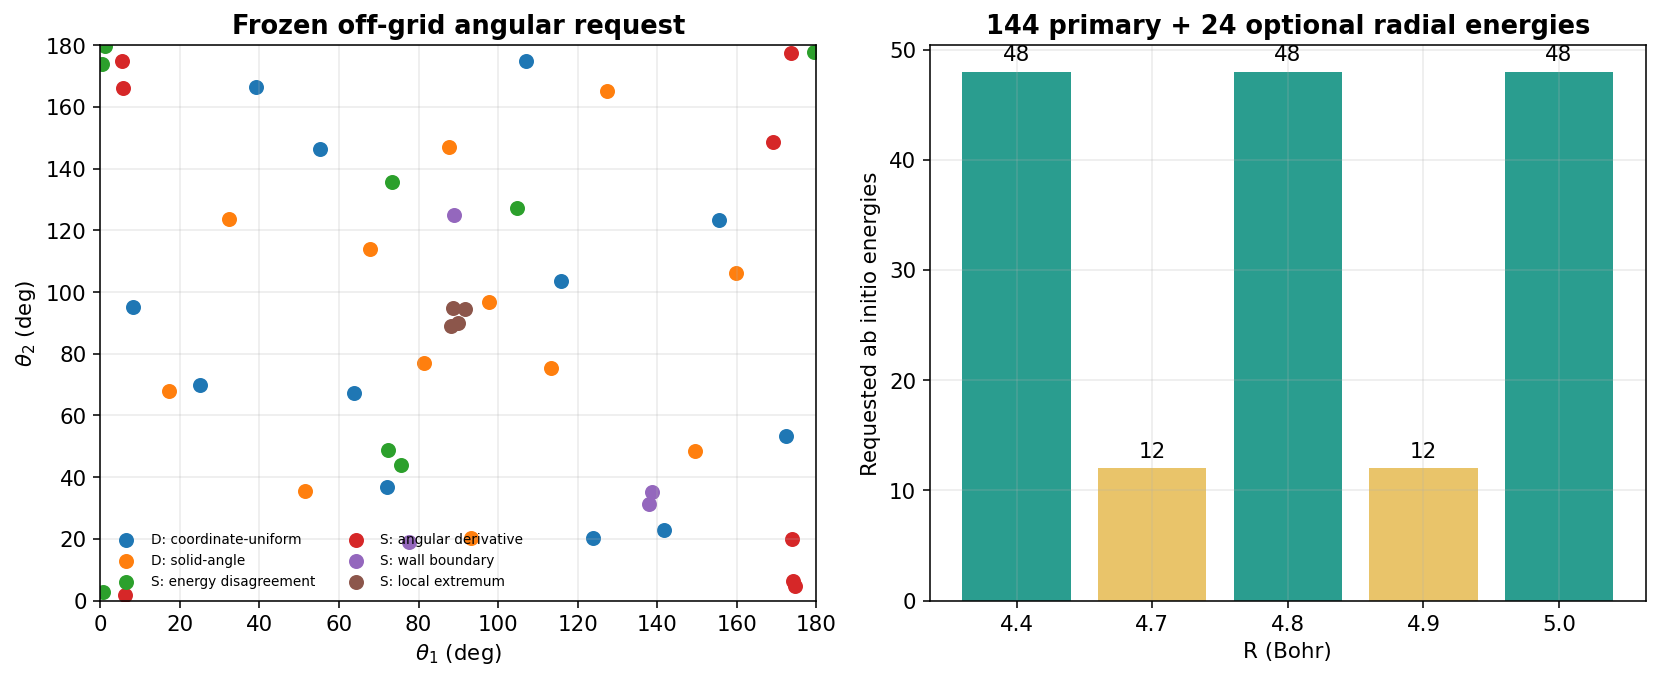

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
categories = validation_orientation_request["Category"].unique()
cmap = plt.get_cmap("tab10")
for index, category in enumerate(categories):
    group = validation_orientation_request[
        validation_orientation_request["Category"] == category
    ]
    axes[0].scatter(group["Theta_1"], group["Theta_2"], s=45,
                    label=category.replace("Distributional: ", "D: ").replace("Stress: ", "S: "),
                    color=cmap(index))
axes[0].set(xlabel=r"$\theta_1$ (deg)", ylabel=r"$\theta_2$ (deg)",
            title="Frozen off-grid angular request", xlim=(0,180), ylim=(0,180))
axes[0].legend(frameon=False, fontsize=7, ncol=2)

counts_by_R = complete_energy_request["R"].value_counts().sort_index()
axes[1].bar(counts_by_R.index.astype(str), counts_by_R.values,
            color=["#2a9d8f" if value in [4.4,4.8,5.0] else "#e9c46a"
                   for value in counts_by_R.index])
axes[1].set(xlabel="R (Bohr)", ylabel="Requested ab initio energies",
            title="144 primary + 24 optional radial energies")
for x, value in enumerate(counts_by_R.values):
    axes[1].text(x, value + 1, str(value), ha="center")
plt.tight_layout()
plt.show()


**What this request tests.** The 144 primary calculations compare the 180- and
500-point predictions with genuinely independent ab initio truth at the three
shortest diagnostic radii. The optional 24 calculations probe interpolation on
either side of the shared (R=4.8) holdout difficulty.

**What happens if validation fails.** The 180-point design is expanded or
reoptimized, and a fresh holdout is reserved after any substantial tuning.
Failure is therefore informative rather than concealed.


<a id="summary"></a>

## 11. One-screen meeting summary

### Conclusions

1. **Completed surface:** fit all **500 raw energies** at every radius.
2. **Wall treatment:** retire the current switch for this raw-fidelity objective.
3. **Prospective design:** use **180 orientations** as a geometry-only pilot,
   not as a validated total ab initio budget.
4. **Primary request:** calculate **144 new energies**—48 frozen off-grid
   orientations at (R=4.4, 4.8, 5.0) Bohr.
5. **Optional radial request:** calculate **24 energies**—12 frozen orientations
   at (R=4.7, 4.9) Bohr.

### Decisions requested from the group

- Approve the working tolerance and guardrail definitions for validation.
- Approve the 144-energy primary request and decide whether to include the
  24-energy radial challenge.
- Confirm the electronic-structure level, angular convention, and requested
  output precision.
- Agree that a failed frozen validation set triggers adaptive augmentation and
  a fresh holdout rather than retrospective relabeling of the budget.

[Return to the presentation route](#contents)


<a id="appendices"></a>

# Technical appendices

These cells preserve the detailed audits needed during questions. They are not
part of the default 20-minute route.


## Appendix A — Data, basis, and cross-validation integrity


In [29]:
display(dataset_summary)
display(pd.DataFrame({
    "Design rows": [M_orientation.shape[0]],
    "Basis columns": [M_orientation.shape[1]],
    "Retained rank": [matrix_rank],
    "Condition number": [matrix_condition],
    "Basis normalization integral": [normal_integral],
    "Cross-basis orthogonality integral": [orthogonal_integral],
}))

example = list(repeated_fivefold_splits(
    df_all[np.isclose(df_all["R"], 4.4)], n_repeats=3, n_folds=5
))
coverage = pd.Series(np.concatenate([
    df_all.loc[s["test_indices"], "orientation_id"].to_numpy() for s in example
])).value_counts()
display(pd.DataFrame({
    "Fits": [len(example)], "Training size": [len(example[0]["train_indices"])],
    "Test size": [len(example[0]["test_indices"])],
    "Predictions per point (min)": [coverage.min()],
    "Predictions per point (max)": [coverage.max()],
}))


,Quantity,Value
0,Total energies,"15,000"
1,Radial slices,30
2,R range (Bohr),4.4–40.0
3,Shared orientations per R,500
4,Angular basis terms,158
5,R=4.4 points below 5000,179
6,R=4.4 guardrail points,321


,Design rows,Basis columns,Retained rank,Condition number,Basis normalization integral,Cross-basis orthogonality integral
0,500,158,158,45.711988,1.0,0.0


,Fits,Training size,Test size,Predictions per point (min),Predictions per point (max)
0,15,400,100,3,3


## Appendix B — Switching due diligence


In [30]:
display(switch_due_diligence_global_summary.round(4))
display(switch_guardrail_summary.round(4))


,Sampling method,Training points,Target method,Mean_radial_complement_MAE,Mean_radial_target_distortion,Worst_individual_normalized_error,Minimum_within_tolerance_percent
0,QR + greedy D-optimal,165,Current switch,168.0383,165.2260,29.0610,1.7544
1,QR + greedy D-optimal,165,Raw potential,0.4188,0.0000,0.5089,100.0000
2,QR + greedy D-optimal,175,Current switch,169.2171,167.1354,29.0054,1.8519
3,QR + greedy D-optimal,175,Raw potential,0.3496,0.0000,0.3641,100.0000
4,QR + greedy D-optimal,250,Current switch,167.0317,165.8648,28.9746,4.8193
5,QR + greedy D-optimal,250,Raw potential,0.2400,0.0000,0.3456,100.0000
6,QR + greedy D-optimal,400,Current switch,177.5508,176.7805,28.3359,3.1250
7,QR + greedy D-optimal,400,Raw potential,0.1496,0.0000,0.1411,100.0000
8,Uniform random,165,Current switch,254.6480,161.7824,4341.5903,0.0000
9,Uniform random,165,Raw potential,108.8181,0.0000,1814.3500,3.2787


,Sampling method,Training points,Target method,Minimum_guardrail_prediction,Worst_percent_below_3000
0,QR + greedy D-optimal,165,Current switch,3525.7271,0.0000
1,QR + greedy D-optimal,165,Raw potential,5000.9672,0.0000
2,QR + greedy D-optimal,175,Current switch,3522.1879,0.0000
3,QR + greedy D-optimal,175,Raw potential,5000.9653,0.0000
4,QR + greedy D-optimal,250,Current switch,3529.0930,0.0000
5,QR + greedy D-optimal,250,Raw potential,5000.9935,0.0000
6,QR + greedy D-optimal,400,Current switch,3535.1642,0.0000
7,QR + greedy D-optimal,400,Raw potential,5016.5328,0.0000
8,Uniform random,165,Current switch,217.6864,4.0936
9,Uniform random,165,Raw potential,-3986.0981,1.3761


## Appendix C — Random sampling details


In [31]:
display(point_count_numerical_summary_r44.round(4))
display(point_count_relevant_summary_r44.round(4))
display(random_threshold_summary.round(4))
display(leverage_error_summary.round(4))


,Training points,minimum_retained_rank,rank_deficient_fits,median_condition_number,worst_condition_number,median_coefficient_norm,maximum_coefficient_norm
0,158,150,50,631410.0435,4.259860e+07,112113.6833,120051.7032
1,175,156,6,3879.1330,2.319343e+04,112535.0551,117138.6907
2,200,158,0,740.5088,2.598894e+03,112557.5206,112742.3799
3,225,158,0,349.1966,1.078847e+03,112557.4858,112613.1401
4,250,158,0,216.9778,6.544086e+02,112559.8859,112599.1644
5,300,158,0,112.2347,2.781893e+02,112563.0309,112586.7278
6,350,158,0,77.5636,1.480300e+02,112564.6068,112581.1679
7,400,158,0,58.5457,1.123146e+02,112565.5081,112577.9377


,Training points,Energy band,N,mean_MAE,worst_repeat_MAE,mean_P95_normalized_error,worst_max_normalized_error,mean_within_tolerance_percent,worst_repeat_within_tolerance_percent
0,158,Low repulsive (0 to 1000),13,1646.1068,2615.1105,632.9210,1293.2654,0.0000,0.0000
1,158,Lower wall (1000 to 3000),118,805.6049,1214.0444,197.2702,997.4223,9.9153,4.2373
2,158,Upper wall (3000 to 5000),48,1004.8377,1454.1968,107.2174,365.5391,15.0000,6.2500
3,175,Low repulsive (0 to 1000),13,622.7240,1595.5293,274.0822,836.0286,5.3846,0.0000
4,175,Lower wall (1000 to 3000),118,273.9193,606.9905,70.7656,818.6383,28.3051,11.0169
5,175,Upper wall (3000 to 5000),48,356.4359,615.4617,35.1389,252.5654,46.2500,22.9167
6,200,Low repulsive (0 to 1000),13,81.7028,150.1754,35.5009,147.5385,18.4615,0.0000
7,200,Lower wall (1000 to 3000),118,33.5925,70.9527,8.9915,81.5086,62.1186,52.5424
8,200,Upper wall (3000 to 5000),48,66.8955,171.8864,8.7760,77.0127,76.4583,64.5833
9,225,Low repulsive (0 to 1000),13,37.2113,66.0495,16.5102,70.9219,29.2308,0.0000


,R,First passing count,Stable passing count,N=400 worst-band mean P95,N=400 minimum band mean within (%),N=400 minimum worst-repeat within (%),N=400 worst individual normalized error,N=400 guardrail passed
0,4.4,<NA>,<NA>,1.5651,84.6154,69.2308,3.6362,True
1,4.6,350,350,0.6601,97.6364,96.3636,2.5490,True
2,4.8,300,300,0.4029,98.4259,98.1481,2.6858,True
3,5.0,<NA>,<NA>,0.7547,90.0000,80.0000,1.5479,True
4,5.2,350,350,0.4604,100.0000,100.0000,0.8725,True
5,5.4,250,250,0.2086,100.0000,100.0000,0.5229,True
6,5.6,225,225,0.1566,100.0000,100.0000,0.5545,True
7,5.8,200,200,0.1137,100.0000,100.0000,0.7371,True
8,6.0,200,200,0.0859,100.0000,100.0000,0.5252,True
9,6.2,200,200,0.0591,100.0000,100.0000,0.3646,True


,R,Relevant orientations,Spearman correlation,Descriptive p-value
0,4.4,179,0.7913,0.0
1,5.0,272,0.5016,0.0


## Appendix D — Fixed-design reconstruction


In [32]:
display(fixed_design_summary_r44.round(4))
display(d_optimal_selected_vs_complement_r44.round(4))


,Sampling method,Training points,worst_band_mean_P95,minimum_band_mean_within,worst_individual_normalized_error,worst_minimum_guardrail_prediction,worst_percent_below_3000,design_replicates,minimum_rank,rank_deficient_designs,median_condition_number,worst_condition_number,mean_projection_deviation_RMSE,worst_projection_deviation_RMSE,mean_relative_coefficient_error,mean_top20_leverage_selected,Full-grid screen passed
0,50% leverage mixture,158,414.2186,36.5254,1936.1139,-7382.6785,0.9346,10,154,9,79604.5884,7.339937e+06,1208.0487,2350.1713,0.1228,10.2,False
1,Pure leverage-weighted,158,219.6436,38.0508,1081.9701,-4846.6914,0.6231,10,157,6,21956.5452,1.760514e+06,682.3105,1656.4682,0.0617,13.0,False
2,QR + greedy D-optimal,158,1.6697,76.9231,2.0392,5274.4176,0.0000,1,158,0,66.6849,6.668490e+01,14.6620,14.6620,0.0007,20.0,False
3,Uniform random,158,334.5350,36.1864,966.0856,-5026.5893,1.5576,10,151,10,492319.7038,1.414540e+07,1132.5568,2312.4336,0.1140,6.8,False
4,50% leverage mixture,175,67.2396,54.6154,557.2819,5124.7065,0.0000,10,158,0,748.9972,2.859856e+03,133.9832,301.9370,0.0136,11.0,False
5,Pure leverage-weighted,175,13.1286,61.5385,41.7472,4503.4840,0.0000,10,158,0,332.3463,4.828789e+02,52.6568,133.6612,0.0042,14.1,False
6,QR + greedy D-optimal,175,0.2204,100.0000,0.3641,5272.6680,0.0000,1,158,0,32.4886,3.248860e+01,14.0357,14.0357,0.0004,20.0,True
7,Uniform random,175,80.1668,43.0769,284.2089,-1804.3026,0.6231,10,157,1,3134.4296,1.379920e+04,313.4322,721.2175,0.0322,7.4,False
8,50% leverage mixture,200,8.4084,65.3846,31.5856,5260.7399,0.0000,10,158,0,231.2310,3.962327e+02,39.1936,68.5164,0.0035,12.2,False
9,Pure leverage-weighted,200,7.3013,74.6154,48.9499,5267.6190,0.0000,10,158,0,137.6750,3.997104e+02,24.9845,57.0594,0.0017,14.9,False


,Training points,Energy band,Full-grid band N,Selected band N,Unselected band N,Full-grid MAE,Complement MAE,Full-grid P95 normalized error,Complement P95 normalized error,Full-grid maximum normalized error,Complement maximum normalized error,Full-grid within tolerance (%),Complement within tolerance (%)
0,158,Low repulsive (0 to 1000),13,8,5,3.4950,9.0871,1.6697,1.9161,2.0392,2.0392,76.9231,40.0
1,158,Lower wall (1000 to 3000),118,36,82,2.6578,3.8247,0.6524,0.6731,0.9733,0.9733,100.0000,100.0
2,158,Upper wall (3000 to 5000),48,18,30,2.2150,3.5441,0.2410,0.2619,0.3433,0.3433,100.0000,100.0
3,175,Low repulsive (0 to 1000),13,9,4,0.5174,1.1465,0.1869,0.1982,0.2020,0.2020,100.0000,100.0
4,175,Lower wall (1000 to 3000),118,43,75,1.2129,1.5366,0.1955,0.2755,0.3641,0.3641,100.0000,100.0
5,175,Upper wall (3000 to 5000),48,19,29,2.1751,3.0600,0.2204,0.2613,0.3109,0.3109,100.0000,100.0
6,200,Low repulsive (0 to 1000),13,9,4,1.0222,1.8231,0.2818,0.3087,0.3177,0.3177,100.0000,100.0
7,200,Lower wall (1000 to 3000),118,47,71,1.4519,1.6243,0.2353,0.2748,0.4777,0.4777,100.0000,100.0
8,200,Upper wall (3000 to 5000),48,23,25,1.6134,1.7728,0.1310,0.1371,0.1483,0.1483,100.0000,100.0
9,225,Low repulsive (0 to 1000),13,9,4,0.9598,0.9990,0.2332,0.2586,0.2777,0.2777,100.0000,100.0


## Appendix E — D-optimal thresholds and robustness


In [33]:
display(d_optimal_threshold_summary)
display(d_optimal_margin_summary.round(4))
display(single_substitution_summary.round(4))
display(reoptimized_recovery_results.round(4))
display(criterion_sensitivity_summary.round(4))


,R,First standard pass,Stable standard pass,First strict pass,Stable strict pass
0,4.4,161,161,161,161
1,4.6,159,159,160,160
2,4.8,158,158,161,161
3,5.0,158,158,158,158
4,5.2,158,158,158,158
5,5.4,158,158,158,158
6,5.6,158,158,158,158
7,5.8,158,158,158,158
8,6.0,158,158,158,158
9,6.2,158,158,158,158


,Training points,Worst normalized error,Tolerance headroom,Tolerance safety factor,Limiting R,Maximum condition number,Maximum relative coefficient error,Minimum guardrail prediction,All radii strict pass
0,158,2.0392,-1.0392,0.4904,4.4,66.6849,0.0007,5000.5538,False
1,159,1.6937,-0.6937,0.5904,4.4,57.7073,0.0006,5000.6007,False
2,160,1.3119,-0.3119,0.7622,4.4,55.8223,0.0005,5000.6693,False
3,161,0.4704,0.5296,2.1257,4.4,55.6877,0.0005,5000.7035,True
4,162,0.4873,0.5127,2.0523,4.4,47.2646,0.0005,5000.6707,True
5,163,0.5122,0.4878,1.9524,4.8,44.9523,0.0005,5000.7378,True
6,164,0.5160,0.4840,1.9378,4.8,43.7945,0.0005,5000.7356,True
7,165,0.5089,0.4911,1.9652,4.8,43.5911,0.0005,5000.7355,True
8,166,0.4806,0.5194,2.0808,4.8,43.5613,0.0005,5000.7352,True
9,167,0.4524,0.5476,2.2103,4.8,41.7335,0.0005,5000.7347,True


,Training points,Variants tested,Strict pass rate (%),Median worst normalized error,P95 worst normalized error,Worst normalized error,Worst removed position,Worst removed orientation,Worst removed leverage,Worst limiting R,Rank-deficient variants,Worst condition number,Minimum guardrail prediction
0,161,161,65.8385,0.6340,4.1347,16.7017,57,243,0.5129,4.4,0,341.1706,5000.0844
1,175,175,96.5714,0.3659,0.7191,2.3084,7,282,0.7911,4.4,0,60.6703,5000.6564
2,180,180,97.2222,0.3240,0.7035,2.7988,7,282,0.7911,4.4,0,59.9807,5000.6618
3,182,182,97.2527,0.3138,0.6572,2.2154,7,282,0.7911,4.4,0,59.8126,5000.6394


,Training points,Unavailable orientation,Unavailable leverage,Simple-replacement error,Reoptimized error,Reoptimized safety factor,Reoptimized limiting R,Reoptimized condition number,Original selected points retained,Selected points changed,Reoptimized strict pass,Minimum guardrail prediction
0,175,187,0.1742,1.3352,0.4238,2.3596,4.4,32.5990,170,5,True,5000.7289
1,180,187,0.1742,1.2040,0.4169,2.3985,4.4,32.0707,174,6,True,5000.7274
2,182,187,0.1742,1.0941,0.3944,2.5353,4.4,31.6231,176,6,True,5000.7230
3,175,203,0.5093,1.0291,0.6173,1.6199,4.4,35.7471,159,16,True,5000.7256
4,180,215,0.4320,1.0781,0.3203,3.1217,4.4,34.3426,177,3,True,5000.7326
5,182,215,0.4320,1.1741,0.3058,3.2703,4.4,33.9865,179,3,True,5000.7287
6,175,241,0.2378,1.2835,0.3506,2.8520,4.8,33.0109,172,3,True,5000.7352
7,180,241,0.2378,1.2590,0.3363,2.9739,4.4,32.5187,177,3,True,5000.7323
8,182,241,0.2378,1.2662,0.3019,3.3120,4.4,31.9772,179,3,True,5000.7282
9,175,267,0.6555,1.2058,0.3670,2.7251,5.2,31.8114,170,5,True,5000.7360


,Training points,Specifications,Specifications_passed,Pass_rate_percent,Minimum_safety_factor,Median_safety_factor,Maximum_safety_factor
0,161,36,36,100.0,1.0628,1.8001,4.2514
1,175,36,36,100.0,1.3734,2.6658,5.4934
2,180,36,36,100.0,1.5138,2.7655,6.0552
3,182,36,36,100.0,1.6327,3.1979,6.5308
4,200,36,36,100.0,1.0468,2.0935,4.1871


## Appendix F — Radial, coefficient, and off-grid audits


In [34]:
display(full_radial_transfer_summary.round(5))
display(coefficient_stability_summary.round(6))
display(offgrid_disagreement_summary.round(5))
display(offgrid_local_minima.groupby("R", group_keys=False).head(5).round(5))
display(radial_holdout_summary.round(5))


,Training points,Total ab initio energies,Reduction from 15000 (%),Retained rank,Condition number,Worst normalized error,Tolerance safety factor,Limiting R,Minimum guardrail prediction,Any guardrail below 3000,Strict pass
0,161,4830,67.8,158,55.68774,0.47044,2.12568,4.4,5000.70346,False,True
1,175,5250,65.0,158,32.48864,0.36407,2.74672,4.4,5000.73182,False,True
2,180,5400,64.0,158,32.09528,0.33030,3.02759,4.4,5000.73018,False,True
3,182,5460,63.6,158,31.63181,0.30624,3.26540,4.4,5000.72597,False,True


,Training points,Retained rank,Condition number,Global relative coefficient error,Median per-R coefficient error,Maximum per-R coefficient error,Minimum cosine similarity,Maximum projection-deviation RMSE,Projection-deviation limiting R,Maximum pointwise projection deviation,Relative first-derivative error,Relative second-derivative error
0,161,158,55.687742,0.000374,0.000125,0.000990,1.0,14.350858,4.4,93.606063,0.000860,0.001823
1,175,158,32.488635,0.000333,0.000093,0.000603,1.0,14.035718,4.4,92.863705,0.000753,0.001575
2,180,158,32.095282,0.000284,0.000089,0.000674,1.0,13.748238,4.4,91.719372,0.000660,0.001412
3,182,158,31.631806,0.000280,0.000084,0.000617,1.0,13.795837,4.4,91.842528,0.000658,0.001415


,Sampling measure,R,Points,P95 absolute disagreement,Maximum absolute disagreement,P95 normalized disagreement,Maximum normalized disagreement,P95 gradient disagreement (cm^-1 rad^-1),Maximum gradient disagreement (cm^-1 rad^-1),Reference-high / candidate-below-3000,Reference-above-1000 / candidate-below-1000
0,coordinate-uniform,4.4,4096,25.80339,108.38843,0.23060,1.03612,294.84831,836.59602,0,0
1,coordinate-uniform,4.8,4096,3.90006,18.34329,0.09445,0.73081,46.02159,141.08537,0,0
2,coordinate-uniform,5.0,4096,1.68088,8.12045,0.08616,0.49678,21.10638,62.22666,0,0
3,coordinate-uniform,5.8,4096,0.15954,0.37758,0.06225,0.24368,1.93155,3.62964,0,0
4,coordinate-uniform,6.6,4096,0.04556,0.13184,0.03483,0.13184,0.59870,1.14565,0,0
5,solid-angle,4.4,4096,11.35609,57.52553,0.31071,1.02518,162.33489,710.01059,0,1
6,solid-angle,4.8,4096,2.09322,8.36542,0.15697,0.68350,29.52344,108.83591,0,0
7,solid-angle,5.0,4096,0.99364,3.84360,0.16280,0.48537,14.39209,46.13756,0,0
8,solid-angle,5.8,4096,0.14675,0.34965,0.08516,0.25868,1.89961,3.60214,0,0
9,solid-angle,6.6,4096,0.04824,0.12669,0.04359,0.12669,0.60376,1.15120,0,0


,R,Theta_1,Theta_2,Phi,V_180_candidate,V_500_reference,Candidate minus reference,Optimizer success
0,4.4,90.0,90.00000,180.0,517.17643,518.77838,-1.60195,True
1,4.4,90.0,89.99999,0.0,517.17643,518.77838,-1.60195,True
2,4.8,90.0,90.00000,0.0,-0.37677,-0.54918,0.17241,True
3,4.8,90.0,90.00000,180.0,-0.37677,-0.54918,0.17241,True
4,5.0,90.0,90.00000,180.0,-119.87787,-120.06354,0.18567,True
5,5.0,90.0,90.00000,0.0,-119.87787,-120.06354,0.18567,True


,Angular design,Held-out R,Worst_band_MAE,Worst_band_P95_normalized_error,Worst_individual_normalized_error,Minimum_band_within_tolerance_percent
0,180-point angular fit,4.6,4.94226,0.62972,0.73122,100.0000
1,180-point angular fit,4.8,3.22619,0.72418,1.42264,96.2963
2,180-point angular fit,5.0,1.87358,0.60493,0.62360,100.0000
3,180-point angular fit,5.2,2.21204,0.54715,0.67461,100.0000
4,180-point angular fit,5.4,2.39760,0.46274,0.53873,100.0000
5,180-point angular fit,5.6,2.80348,0.37010,0.60137,100.0000
6,180-point angular fit,5.8,3.64278,0.34686,0.54090,100.0000
7,180-point angular fit,6.0,3.44357,0.33385,0.46358,100.0000
8,180-point angular fit,6.2,2.20119,0.35567,0.46097,100.0000
9,180-point angular fit,6.4,1.92019,0.35150,0.48850,100.0000


## Appendix G — Solver and synthetic-noise diagnostics


In [35]:
display(rcond_sensitivity_summary.round(6))
display(synthetic_noise_summary.round(6))


,rcond,Retained rank,Retained-subspace condition number,Relative coefficient change,Worst normalized error,Tolerance safety factor,Limiting R,Minimum guardrail prediction,Any guardrail below 3000,Strict pass
0,0.000000,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
1,0.000000,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
2,0.000000,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
3,0.000001,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
4,0.000100,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
5,0.001000,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
6,0.010000,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
7,0.020000,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
8,0.030000,158,32.095282,0.000000,0.330295,3.027594,4.4,5000.730180,False,True
9,0.050000,154,19.117107,0.048825,288.978258,0.003460,5.2,4894.009067,False,False


,Noise sigma (cm^-1),strict_pass_rate_percent,median_worst_normalized_error,P95_worst_normalized_error,maximum_worst_normalized_error,median_relative_coefficient_perturbation,P95_relative_coefficient_perturbation,minimum_guardrail_prediction,guardrail_failure_count
0,0.00,100.0,0.330295,0.330295,0.330295,0.000000,0.000000,5000.730180,0
1,0.01,100.0,0.330432,0.331872,0.332900,0.000004,0.000004,5000.713339,0
2,0.05,100.0,0.331452,0.340251,0.398547,0.000018,0.000019,5000.645973,0
3,0.10,100.0,0.487029,0.590351,0.664945,0.000037,0.000038,5000.561767,0
4,0.25,0.5,1.196313,1.444907,1.690878,0.000092,0.000095,5000.309147,0
5,0.50,0.0,2.378781,2.888720,3.400768,0.000184,0.000191,4999.888113,0
6,1.00,0.0,4.765228,5.776346,6.820547,0.000369,0.000381,4999.007385,0


## Appendix H — Final design and frozen request audit


In [36]:
display(final_design_comparison.round(5))
display(validation_orientation_request)
display(request_file_manifest)


,Training points,Interpretation,Total energies over 30 R,Conditional training-count reduction (%),Condition number,Worst normalized error,Tolerance safety factor,Maximum per-R coefficient error,Single-substitution pass rate (%),Failed cases recovered after reoptimization (%),All-radius strict pass
0,161,Empirical minimum,4830,67.8,55.68774,0.47044,2.12568,0.00099,65.83851,NaN,True
1,175,Robust lower bound,5250,65.0,32.48864,0.36407,2.74672,0.00060,96.57143,100.0,True
2,180,Prospective pilot,5400,64.0,32.09528,0.33030,3.02759,0.00067,97.22222,100.0,True
3,182,Upper pilot comparator,5460,63.6,31.63181,0.30624,3.26540,0.00062,97.25275,100.0,True


,Validation ID,Category,Selection detail,Theta_1,Theta_2,Phi
0,V001,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,71.948981,36.717370,145.179469
1,V002,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,107.061699,174.749823,80.568893
2,V003,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,172.314384,53.186918,122.641417
3,V004,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,8.148389,95.170160,13.274406
4,V005,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,25.029307,69.884512,57.810860
5,V006,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,155.609924,123.339040,167.227216
6,V007,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,123.951345,20.390337,35.283772
7,V008,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,55.234424,146.211066,99.943694
8,V009,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,63.713134,67.284320,25.547974
9,V010,Distributional: coordinate-uniform,Fresh Sobol seed 20260716; label-free,115.691836,103.659301,106.872961


,Artifact,Rows,Path
0,orientations_48,48,/workspace/scratch/25391e901cda/meeting_output...
1,primary_144,144,/workspace/scratch/25391e901cda/meeting_output...
2,optional_radial_24,24,/workspace/scratch/25391e901cda/meeting_output...
3,complete_168,168,/workspace/scratch/25391e901cda/meeting_output...


## Limitations retained for discussion

1. The D-optimal count was developed and scored on the same finite 500-angle
   candidate grid.
2. Complement testing withholds known-grid labels but is not continuous-angle
   validation.
3. The acceptance thresholds are working physical choices.
4. The D-optimal ordering is greedy and candidate-grid dependent.
5. Off-grid diagnostics compare fitted models and create no new truth.
6. The radial spline is diagnostic rather than a production interpolation.
7. Synthetic independent noise is not calibrated to the electronic-structure
   method and is retained only as a numerical stress test.

[Return to the meeting summary](#summary)
